# 📋 РУКОВОДСТВО ПО ИСПОЛЬЗОВАНИЮ ШАБЛОНА

## Просмотр результатов

**Ноутбук уже выполнен.** Все графики и выводы видны сразу при открытии на GitHub.

### Источник данных:

**Датасет:** Stroke Prediction Dataset  
**Источник:** [Kaggle - Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

Анализ данных по текущему датасету: [analysis_report.md](analysis_report_eda.md)

> **Примечание:** Датасет не включён в репозиторий. Для самостоятельного запуска ноутбука необходимо скачать датасет и настроить пути в блоке 1.2.

## 🚀 Быстрый старт

1. **Настрой проект** → открой блок [`[# 1.3. ВСЕ НАСТРОЙКИ ПРОЕКТА]`](#scrollTo=obp4IhqxUBeM)
2. **Заполни переменные** (см. таблицу ниже)
3. **Запусти все ячейки** → `Runtime → Run all`


---


## ⚠️ ВАЖНО: ПОСЛЕДОВАТЕЛЬНЫЙ ЗАПУСК

**Шаблон перезаписывает файлы в процессе работы** (checkpoints, трансформеры, метаданные).

- ✅ **Запускайте ячейки ПОСЛЕДОВАТЕЛЬНО** (сверху вниз)
- ✅ **Используйте `Runtime → Run all`** для полного выполнения
- ❌ **Не пропускайте блоки** — это нарушит цепочку трансформаций
- ❌ **Не меняйте порядок выполнения** — данные будут испорчены

**Почему это важно:**
- `X_train` последовательно проходит через обработку пропусков → выбросов → feature engineering → удаление признаков
- Нарушение порядка приведёт к ошибкам или неконсистентным данным


---


## ⚙️ ВСЕ НАСТРОЙКИ ПРОЕКТА (блок 1.3)

| Переменная | Что делает | Пример |
|------------|------------|--------|
| **`PROJECT_NAME`** | Имя проекта (должно совпадать с preprocessing) | `'stroke'` |
| **`BASE_PATH`** | Базовая папка на диске | `/content/drive/MyDrive/ml_learning` |
| **`AUTO_BINS`** | Автоматический расчёт bins (sqrt(n)) — справочно | `54` |
| **`BINS`** | Количество bins для гистограмм | `50` |
| **`HUE_BY_TARGET`** | Разделение графиков по целевой | `True` / `False` |
| **`EMPTY_MARKERS_STR`** | Маркеры пустот в строках | `['', 'null', 'none', 'na', 'n/a', '?', 'unknown', 'nan']` |
| **`EMPTY_MARKERS_NUM`** | Маркеры пустот в числах | `[-1, -999, 999, 999999]` |
| **`missing_strategy`** | Стратегия обработки пропусков | `{'smoking_status': ('constant', 'unknown')}` |
| **`outliers_strategy`** | Стратегия обработки выбросов | `{'age': ('keep', None)}` |
| **`NEW_FEATURES_LIST`** | Список новых признаков для анализа (блок 5.3) | `['cardio_risk', 'marriage_risk']` |
| **`encoding_config`** | Кодирование категориальных признаков | `{'marriage_risk': ('one_hot', None)}` |
| **`columns_to_drop_fe`** | Удаление признаков после FE | `['ever_married', 'hypertension', ...]` |
| **`features_to_drop`** | Удаление на основе корреляций | `['senior_work']` |
| **`features_to_drop_rf`** | Удаление на основе Random Forest (блок 8.5) | `[]` |
| **`scaling_config`** | Масштабирование числовых признаков | `{'age': ('standard', None)}` |
| **`columns_to_drop_final`** | Удаление признаков после трансформации | `[]` |
| **`RF_CLASS_WEIGHT`** | Балансировка классов в Random Forest | `'balanced'` |


---

### 📊 СТРАТЕГИИ ОБРАБОТКИ

#### missing_strategy (обработка пропусков)

| Стратегия | Описание | Пример |
|-----------|----------|--------|
| `'drop_column'` | Удалить колонку | `('drop_column', None)` |
| `'mode'` | Заполнить модой | `('mode', None)` |
| `'median'` | Заполнить медианой | `('median', None)` |
| `'mean'` | Заполнить средним | `('mean', None)` |
| `'constant'` | Заполнить константой | `('constant', 'unknown')` |
| `'flag'` | Создать флаг пропуска + заполнить значением из `param` | `('flag', 0)` или `('flag', 'unknown')` |

#### outliers_strategy (обработка выбросов)

| Стратегия | Описание | Пример |
|-----------|----------|--------|
| `'keep'` | Оставить как есть | `('keep', None)` |
| `'cap'` | Обрезать по границам (винзоризация) | `('cap', None)` |
| `'remove'` | Удалить строки с выбросами | `('remove', None)` |
| `'log'` | Логарифмическое преобразование | `('log', None)` |
| `'flag'` | Создать флаг выброса | `('flag', None)` |

#### encoding_config (кодирование категорий)

| Стратегия | Описание | Пример |
|-----------|----------|--------|
| `'one_hot'` | One-Hot Encoding | `('one_hot', None)` |
| `'label'` | Label Encoding | `('label', None)` |


---

### 🛠️ FEATURE ENGINEERING (блок 5.1)

**⚠️ Блок НЕ универсален — требует ручной настройки под ваш датасет.**

Пример для проекта stroke:

```python
# Сердечно-сосудистый риск
X_train['cardio_risk'] = ((X_train['hypertension'] == 1) | (X_train['heart_disease'] == 1)).astype(int)

# Семейное положение с учётом возраста
def get_marriage_risk(row):
    if row['age'] <= 60:
        return 'young'
    elif row['ever_married'] == 'yes':
        return 'senior_married'
    else:
        return 'senior_unmarried'
X_train['marriage_risk'] = X_train.apply(get_marriage_risk, axis=1)
```

## 🎯 ОПРЕДЕЛЕНИЕ ТИПА ЗАДАЧИ

Тип задачи **автоматически считывается из `metadata.json`**, который создаётся в preprocessing.

| Целевая колонка | Уникальных значений | Результат |
|----------------|---------------------|-----------|
| 0/1 | 2 | **классификация** |
| float | много | **регрессия** |

**В EDA нет возможности изменить тип задачи** — это настройка preprocessing.  
Если тип определён неверно, вернись в preprocessing и укажи `FORCE_TASK_TYPE`:

```python
FORCE_TASK_TYPE = 'classification'  # или 'regression'
```

## 📁 Структура проекта

После выполнения шаблона в папке `{PROJECT_NAME}` будет создана следующая структура:
<pre>
📁 {PROJECT_NAME}/
│
├── 📄 metadata.json # метаданные из preprocessing
├── 📄 production_metadata.json # метаданные для продакшена (EDA)
├── 📄 transformations_metadata.json # метаданные трансформаций
│
├── 📁 checkpoints/
│ ├── 📄 03_missing_handled.csv # после обработки пропусков
│ ├── 📄 04_outliers_handled.csv # после обработки выбросов
│ ├── 📄 05_feature_engineering.csv # после создания новых признаков
│ ├── 📄 06_features_selected.csv # после отбора признаков
│ ├── 📄 07_rf_selected.csv # после RF-отбора
│ └── 📄 09_final_processed.csv # финальные данные
│
├── 📁 transformers/
│ ├── 📄 scalers.pkl # обученные scaler'ы
│ └── 📄 encoders.pkl # обученные encoder'ы
│
├── 📁 reports/
│ ├── 📄 eda_run_log_*.txt # лог запуска
│ └── 📁 plots/ # все графики (PNG)
│
└── 📁 splits/ # из preprocessing + созданные в EDA
├── X_train.csv, X_val.csv, X_test.csv # исходные
├── y_train.csv, y_val.csv, y_test.csv
├── X_train_encoded.csv # для деревьев
├── X_train_scaled.csv # для линейных моделей
├── X_val_final.csv, X_test_final.csv # финальные val/test
└── X_train_final.csv # алиас для X_train_scaled
</pre>

## 💡 ПОДСКАЗКИ

- **Блок 2.6** → поиск скрытых пустот (включая `'unknown'`, `'null'`, `-1` и т.д.)
- **Блок 4.2** → статистика выбросов по методу IQR
- **Блок 5.1** → создание новых признаков (Feature Engineering) — **требует ручной настройки**
- **Блок 5.3** → анализ новых признаков с визуализацией
- **Блок 6.1** → анализ категориальных колонок (топ-5, редкие категории)
- **Блок 7.2** → тепловая карта корреляций
- **Блок 8.2** → Random Forest для оценки важности признаков
- **Блок 9.2** → масштабирование числовых признаков
- **Блок 9.5** → применение трансформаций к val/test


## ⚠️ ВАЖНЫЕ РЕКОМЕНДАЦИИ

### 1. Все анализы - только на TRAIN
Выбросы, корреляции, важность признаков анализируются **только на train выборке**. Это предотвращает утечку данных.

### 2. Feature Engineering - до кодирования категорий
Новые признаки создаются **до** кодирования категориальных колонок. Это позволяет:
- Анализировать новые признаки наравне с исходными
- Кодировать новые категориальные признаки
- Включать новые числовые признаки в корреляционный анализ и RF

### 3. Визуализация с разделением по целевой
Включи `HUE_BY_TARGET = True` в блоке 1.3, чтобы все графики числовых признаков дублировались с разделением по целевой переменной.

### 4. Сохранение трансформеров
После обучения `scaler` и `encoder` сохраняются в папку `transformers/` и используются для трансформации val/test.

### 5. Последовательный запуск (повторно)
**Шаблон перезаписывает промежуточные файлы.** Всегда запускайте ячейки последовательно или используйте `Runtime → Run all`.


## 📚 Следующий этап

После выполнения шаблона EDA данные готовы для обучения модели. Уже готовы:

| Для деревьев (RF, XGBoost) | Для линейных моделей (LR, SVM) |
|---------------------------|-------------------------------|
| `X_train_encoded.csv` | `X_train_scaled.csv` |

**А также:**
- `X_val_final.csv`, `X_test_final.csv` — валидационные и тестовые данные
- `production_metadata.json` — метаданные для продакшена
- Обученные трансформеры в папке `transformers/`



#### ✅ Шаблон EDA готов к работе.



# БЛОК 1. import библиотек

In [1]:
# БЛОК 1.1. ИМПОРТ БИБЛИОТЕК

# Стандартные библиотеки
import os
import json
import warnings
warnings.filterwarnings('ignore')  # отключаем предупреждения

# Работа с данными
import pandas as pd
import numpy as np

# Визуализация (основная)
import matplotlib.pyplot as plt  # ← ДОБАВЛЕНО (было пропущено)
import matplotlib  # для получения версии
import seaborn as sns

# Стиль и размер графиков (ПОСЛЕ импорта plt)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Для работы с Гугл Диском
from google.colab import drive

# Для машинного обучения: Random Forest
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.feature_selection import f_classif, chi2

# Для сохранения трансформеров
import joblib

# Для работы с датами
from datetime import datetime

# Для отображения в Jupyter/Colab
from IPython.display import display


In [2]:
# БЛОК 1.2. МОНТИРОВАНИЕ ГУГЛ ДИСКА

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

Mounted at /content/drive


# Ввод переменных

In [3]:
# 1.3. ВСЕ НАСТРОЙКИ ПРОЕКТА

# 1. ПРОЕКТ

PROJECT_NAME = 'stroke'           # имя проекта (должно совпадать с preprocessing)
BASE_PATH = '/content/drive/MyDrive/ml_learning'  # должно совпадать с preprocessing


# 2. ПАРАМЕТРЫ ВИЗУАЛИЗАЦИИ

AUTO_BINS = 54                    # справка, рассчитано по формуле
BINS = 50                         # используемое значение (можно изменить)

# 3. ВИЗУАЛИЗАЦИЯ С РАЗДЕЛЕНИЕМ ПО ЦЕЛЕВОЙ

HUE_BY_TARGET = True   # True - показывать распределение с разделением по целевой

# 4. МАРКЕРЫ ПУСТОТЫ (для поиска скрытых пропусков)
# Можно добавить новые уникальные значения (блок 2.1 или 5.1)

EMPTY_MARKERS_STR = ['', 'null', 'none', 'na', 'n/a', '?', 'unknown', 'nan']
EMPTY_MARKERS_NUM = [-1, -999, 999, 999999]

# 5. СТРАТЕГИЯ ОБРАБОТКИ ПРОПУСКОВ

# Заполняется на основе анализа пустот (блок 2.6):
#   'drop_column' - удалить колонку
#   'mode' - заполнить модой (для категориальных)
#   'median' - заполнить медианой (для числовых)
#   'mean' - заполнить средним (для числовых)
#   'constant' - заполнить константой (укажите значение)
#   'flag' - создать флаг пропуска + заполнить

missing_strategy = {
    'smoking_status': ('constant', 'unknown'),
    # 'название_колонки': ('стратегия', 'параметр')
    # Примеры:
    #   'parental_level_of_education': ('mode', None),
    #   'math_score': ('median', None),
    #   'lunch': ('constant', 'unknown'),
    #   'age': ('flag', 'median'),
}

# 6. СТРАТЕГИЯ ОБРАБОТКИ ВЫБРОСОВ

# Заполняется на основе анализа выбросов (блок 4.2)
#   'keep' - оставить как есть (без обработки)
#   'cap' - обрезать по границам (винзоризация)
#   'remove' - удалить строки с выбросами
#   'log' - логарифмическое преобразование
#   'flag' - создать флаг выброса

outliers_strategy = {
    'age': ('keep', None),
    'avg_glucose_level': ('keep', None),
    'bmi': ('keep', None),
    # 'название_колонки': ('стратегия', 'параметр')
}

# 7. СПИСОК НОВЫХ ПРИЗНАКОВ ДЛЯ АНАЛИЗА (блок 5.3)
# Перечисли имена новых признаков, которые создал в блоке 5.1

NEW_FEATURES_LIST = ['cardio_risk', 'senior_work', 'marriage_risk']

# 8. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# Методы: 'one_hot', 'label', 'frequency', 'target', 'none'
encoding_config = {
    'marriage_risk': ('one_hot', None),
}

# 9. УДАЛЕНИЕ ПРИЗНАКОВ

# 9.1 Удаление признаков после feature engineering
columns_to_drop_fe = [
    'ever_married', 'hypertension', 'heart_disease',
    'work_type', 'gender', 'residence_type', 'smoking_status',
    'senior_stress', 'is_high_risk_work', 'high_risk_metabolic',
    'senior_stress_1', 'senior_stress_2', 'senior_stress_3',
    'stress_cardio', 'no_support_stress'
]

# 9.2 Удаление признаков после корреляционного анализа (блок 6.1, 6.2)
features_to_drop = ['senior_work']  # пример: ['math_score', 'reading_score']

# 9.3. Удаление признаков на основе Random Forest (блок 8.5)
features_to_drop_rf = []  # пример: ['race/ethnicity', 'test_preparation_course']


# 10. НАСТРОЙКИ ДЛЯ БЛОКА 9 (ПОДГОТОВКА ДАННЫХ)

# 10.1. МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ
# Формат: 'колонка': ('метод', параметры)
# Методы: 'standard', 'robust', 'minmax', 'none'
scaling_config = {
    'age': ('standard', None),           # нормальное распределение
    'avg_glucose_level': ('robust', None),  # скошенное, с выбросами
    'bmi': ('robust', None),             # лёгкая скошенность, выбросы
    # 'hypertension': ('none', None),    # бинарные не масштабируем
    # 'heart_disease': ('none', None),
}

# 10.2. УДАЛЕНИЕ ПРИЗНАКОВ ПОСЛЕ ТРАНСФОРМАЦИИ
columns_to_drop_final = []  # например, ['id', 'user_id']

# 10.3. СОХРАНЯТЬ ЛИ ПРОМЕЖУТОЧНЫЕ ВЕРСИИ?
save_intermediate = True  # True/False

# 11. НАСТРОЙКИ ДЛЯ RANDOM FOREST
RF_CLASS_WEIGHT = 'balanced'  # Варианты: 'balanced', None, 'balanced_subsample'
#   - 'balanced' - автоматически корректирует веса обратно пропорционально частоте классов
#   - None - без корректировки (игнорирует дисбаланс)
#   - 'balanced_subsample' - то же, но для каждого бутстрэп-сэмпла


In [4]:
# 1.4. НАСТРОЙКА ПУТЕЙ ПРОЕКТА

# Пути к папкам проекта
PROJECT_PATH = f'{BASE_PATH}/datasets/{PROJECT_NAME}'
CHECKPOINT_PATH = f'{PROJECT_PATH}/checkpoints'
SPLITS_PATH = f'{PROJECT_PATH}/splits'
REPORTS_PATH = f'{PROJECT_PATH}/reports'
TRANSFORMERS_PATH = f'{PROJECT_PATH}/transformers'
PLOTS_PATH = f'{REPORTS_PATH}/plots'

# Создаём папки
os.makedirs(TRANSFORMERS_PATH, exist_ok=True)
os.makedirs(PLOTS_PATH, exist_ok=True)

In [5]:
# БЛОК 1.5. ЗАГРУЗКА МЕТАДАННЫХ

# Загружаем metadata.json, который создал preprocessing
# Проверка: работаем с верным проектом или нет

metadata_path = f'{PROJECT_PATH}/metadata.json'

if os.path.exists(metadata_path):
    with open(metadata_path, 'r', encoding='utf-8') as f:
        metadata = json.load(f)

    # Сохраняем имя целевой переменной для использования в других блоках
    TARGET_COLUMN = metadata['target_column']

    print("✓ Метаданные загружены:")
    print(f"   Проект: {metadata['project_name']}")
    print(f"   Целевая колонка: {TARGET_COLUMN}")
    print(f"   Признаков в обучении: {len(metadata['feature_names'])}")
    print(f"   Дата обработки: {metadata['date_processed']}")
else:
    print("⚠ ВНИМАНИЕ: metadata.json не найден!")
    print(f"   Ищем по пути: {metadata_path}")
    print("   Убедитесь, что preprocessing был выполнен успешно.")
    # Устанавливаем значение по умолчанию
    TARGET_COLUMN = 'target'

✓ Метаданные загружены:
   Проект: stroke
   Целевая колонка: stroke
   Признаков в обучении: 10
   Дата обработки: 2026-04-08 06:17:15


In [6]:
# БЛОК 1.6. ЗАГРУЗКА ТРЕНИРОВОЧНЫХ ДАННЫХ

X_train_path = f'{SPLITS_PATH}/X_train.csv'
y_train_path = f'{SPLITS_PATH}/y_train.csv'

if os.path.exists(X_train_path) and os.path.exists(y_train_path):
    # Загружаем исходные данные (для EDA)
    X_train = pd.read_csv(X_train_path)
    original_shape = X_train.shape

    print(f"\n✓ Исходные данные загружены (для EDA):")
    print(f"   X_train: {X_train.shape[0]} строк, {X_train.shape[1]} колонок")

    # Загружаем целевую переменную
    y_train_df = pd.read_csv(y_train_path)
    if y_train_df.shape[1] == 1:
        y_train = y_train_df.iloc[:, 0]
    else:
        y_train = y_train_df

    print(f"\n✓ Целевая переменная загружена:")
    print(f"   y_train: {y_train.shape[0]} значений")
    print(f"   Тип целевой: {y_train.dtype}")
else:
    print("❌ ОШИБКА: Не найдены файлы X_train.csv или y_train.csv")
    print(f"   Проверьте путь: {SPLITS_PATH}")
    print("   Сначала выполните preprocessing.")


✓ Исходные данные загружены (для EDA):
   X_train: 2911 строк, 10 колонок

✓ Целевая переменная загружена:
   y_train: 2911 значений
   Тип целевой: int64


In [7]:
# БЛОК 1.7. ОПРЕДЕЛЕНИЕ ТИПА ЗАДАЧИ (классификация / регрессия)

# Проверяем тип целевой переменной
if y_train.dtype == 'object' or y_train.dtype.name == 'category':
    task_type = 'classification'
elif y_train.nunique() <= 10:
    task_type = 'classification'
else:
    task_type = 'regression'

print(f"Тип задачи: {task_type.upper()}")

if task_type == 'classification':
    print(f"Количество классов: {y_train.nunique()}")
    print(f"Распределение классов:")
    class_counts = y_train.value_counts()
    for cls, count in class_counts.items():
        pct = count / len(y_train) * 100
        print(f"   {cls}: {count} ({pct:.1f}%)")

    # Проверяем дисбаланс и даём рекомендацию
    min_class_pct = class_counts.min() / len(y_train) * 100
    if min_class_pct < 10:
        imbalance_ratio = class_counts.max() / class_counts.min()
        print(f"\n⚠ ВНИМАНИЕ: ОБНАРУЖЕН СИЛЬНЫЙ ДИСБАЛАНС КЛАССОВ!")
        print(f"   Соотношение классов: {imbalance_ratio:.1f}:1")
        print(f"\n💡 РЕКОМЕНДАЦИЯ:")
        print(f"   Установите RF_CLASS_WEIGHT = 'balanced'")
        print(f"   (это настройка в блоке 1.3)")
        print(f"\n   При обучении других моделей используйте class_weight='balanced'")
        print(f"   или методы аугментации (SMOTE).")
else:
    print(f"Целевая переменная: числовая")
    print(f"Диапазон: от {y_train.min():.2f} до {y_train.max():.2f}")
    print(f"Среднее: {y_train.mean():.2f}")
    print(f"Медиана: {y_train.median():.2f}")

Тип задачи: CLASSIFICATION
Количество классов: 2
Распределение классов:
   0: 2786 (95.7%)
   1: 125 (4.3%)

⚠ ВНИМАНИЕ: ОБНАРУЖЕН СИЛЬНЫЙ ДИСБАЛАНС КЛАССОВ!
   Соотношение классов: 22.3:1

💡 РЕКОМЕНДАЦИЯ:
   Установите RF_CLASS_WEIGHT = 'balanced'
   (это настройка в блоке 1.3)

   При обучении других моделей используйте class_weight='balanced'
   или методы аугментации (SMOTE).


In [8]:
# БЛОК 1.8. ПРОВЕРКА СООТВЕТСТВИЯ С МЕТАДАННЫМИ

if 'metadata' in locals():  # если метаданные загружены
    expected_features = set(metadata['feature_names'])
    actual_features = set(X_train.columns)

    if expected_features == actual_features:
        print("\n✓ Данные соответствуют метаданным")
    else:
        print("\n⚠ ВНИМАНИЕ: Набор признаков не совпадает с метаданными!")
        print(f"   Ожидалось: {len(expected_features)} признаков")
        print(f"   Получено: {len(actual_features)} признаков")

        missing = expected_features - actual_features
        extra = actual_features - expected_features

        if missing:
            missing_list = list(missing)
            preview = missing_list[:10]
            suffix = '...' if len(missing_list) > 10 else ''
            print(f"   Отсутствуют: {preview}{suffix}")
        if extra:
            extra_list = list(extra)
            preview = extra_list[:10]
            suffix = '...' if len(extra_list) > 10 else ''
            print(f"   Лишние: {preview}{suffix}")
else:
    print("\n⚠ Метаданные не загружены, пропускаем проверку")


✓ Данные соответствуют метаданным


# Сохранение лога

In [9]:
# БЛОК 1.9. СОХРАНЕНИЕ ЛОГА ЗАПУСКА

def save_run_log(metadata_loaded):
    log_lines = []
    log_lines.append("=" * 70)
    log_lines.append(f"EDA RUN LOG")
    log_lines.append(f"Дата и время запуска: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    log_lines.append("=" * 70)

    # 1. Версии библиотек
    log_lines.append("\n--- 1. ВЕРСИИ БИБЛИОТЕК ---")
    log_lines.append(f"pandas: {pd.__version__}")
    log_lines.append(f"numpy: {np.__version__}")
    log_lines.append(f"matplotlib: {matplotlib.__version__}")
    log_lines.append(f"seaborn: {sns.__version__}")

    try:
        import sklearn
        log_lines.append(f"scikit-learn: {sklearn.__version__}")
    except ImportError:
        log_lines.append("scikit-learn: не установлен")

    log_lines.append(f"joblib: {joblib.__version__}")

    # 2. Параметры проекта
    log_lines.append("\n--- 2. ПАРАМЕТРЫ ПРОЕКТА ---")
    log_lines.append(f"PROJECT_NAME: {PROJECT_NAME}")
    log_lines.append(f"BASE_PATH: {BASE_PATH}")
    log_lines.append(f"task_type: {task_type}")

    # 3. Информация о данных
    log_lines.append("\n--- 3. ИНФОРМАЦИЯ О ДАННЫХ ---")
    log_lines.append(f"X_train shape: {X_train.shape[0]} строк, {X_train.shape[1]} колонок")
    log_lines.append(f"y_train: {y_train.shape[0]} значений")
    log_lines.append(f"Тип целевой: {y_train.dtype}")

    if task_type == 'classification':
        log_lines.append(f"Количество классов: {y_train.nunique()}")
        log_lines.append("Распределение классов:")
        for cls, count in y_train.value_counts().items():
            log_lines.append(f"  {cls}: {count} ({count/len(y_train)*100:.1f}%)")
    else:
        log_lines.append(f"Диапазон целевой: [{y_train.min():.2f}, {y_train.max():.2f}]")
        log_lines.append(f"Среднее: {y_train.mean():.2f}")
        log_lines.append(f"Медиана: {y_train.median():.2f}")
        log_lines.append(f"Станд. отклонение: {y_train.std():.2f}")

    # 4. Использование памяти
    log_lines.append("\n--- 4. ИСПОЛЬЗОВАНИЕ ПАМЯТИ ---")
    memory_mb = X_train.memory_usage(deep=True).sum() / 1024 / 1024
    log_lines.append(f"X_train занимает: {memory_mb:.2f} MB")

    # 5. Структура проекта
    log_lines.append("\n--- 5. СТРУКТУРА ПРОЕКТА ---")
    log_lines.append(f"Папка проекта: {PROJECT_PATH}")
    log_lines.append(f"Сплиты: {SPLITS_PATH}")
    log_lines.append(f"Отчёты: {REPORTS_PATH}")
    log_lines.append(f"Трансформеры: {TRANSFORMERS_PATH}")
    log_lines.append(f"Графики: {PLOTS_PATH}")

    # 6. Дополнительная информация
    log_lines.append("\n--- 6. ДОПОЛНИТЕЛЬНО ---")
    log_lines.append(f"Метаданные загружены: {metadata_loaded}")

    log_lines.append("\n" + "=" * 70)
    log_lines.append("КОНЕЦ ЛОГА")
    log_lines.append("=" * 70)

    # Сохраняем в файл
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_path = f'{REPORTS_PATH}/eda_run_log_{timestamp}.txt'

    with open(log_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(log_lines))

    print(f"\n✓ Лог запуска сохранён: {log_path}")
    print(f"  Всего записано строк: {len(log_lines)}")


# Проверка: загружены ли метаданные
metadata_loaded = 'metadata' in globals()

# Сохранение лога
save_run_log(metadata_loaded)


✓ Лог запуска сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/eda_run_log_20260408_062512.txt
  Всего записано строк: 36


# БЛОК 2. Общая info

In [10]:
# БЛОК 2.1. БАЗОВАЯ ИНФОРМАЦИЯ О ДАННЫХ

print("=" * 60)
print("2.1. ИНФОРМАЦИЯ О ДАННЫХ")
print("=" * 60)

# --- X_train (признаки) ---
print("\n📊 X_train (признаки)")
print("-" * 40)

# Вывод DataFrame с выравниваем по колонкам
info_data = []
for col in X_train.columns:
    info_data.append({
        'Колонка': col,
        'Тип': X_train[col].dtype,
        'Непустых': X_train[col].count(),
        'Пропуски': X_train[col].isnull().sum(),
        'Уникальных': X_train[col].nunique()
    })

info_df = pd.DataFrame(info_data)
print(info_df.to_string(index=False))

# Дополнительная информация о памяти
memory_mb = X_train.memory_usage(deep=True).sum() / 1024 / 1024
print(f"\n💾 Память: {memory_mb:.2f} MB")
print(f"📐 Форма: {X_train.shape[0]} строк × {X_train.shape[1]} колонок")

# --- y_train (целевая переменная) ---
print("\n🎯 y_train (целевая переменная)")
print("-" * 40)
print(f"Тип: {y_train.dtype}")
print(f"Уникальных значений: {y_train.nunique()}")
print(f"Форма: {y_train.shape}")
print(f"Пропуски: {y_train.isnull().sum()}")

# Для классификации показываем распределение
if task_type == 'classification':
    print(f"\n📈 Распределение классов:")
    for cls, count in y_train.value_counts().items():
        print(f"   {cls}: {count} ({count/len(y_train)*100:.1f}%)")

2.1. ИНФОРМАЦИЯ О ДАННЫХ

📊 X_train (признаки)
----------------------------------------
          Колонка     Тип  Непустых  Пропуски  Уникальных
           gender  object      2911         0           2
              age float64      2911         0          93
     hypertension   int64      2911         0           2
    heart_disease   int64      2911         0           2
     ever_married  object      2911         0           2
        work_type  object      2911         0           5
   residence_type  object      2911         0           2
avg_glucose_level float64      2911         0        2491
              bmi float64      2911         0         378
   smoking_status  object      2911         0           4

💾 Память: 0.88 MB
📐 Форма: 2911 строк × 10 колонок

🎯 y_train (целевая переменная)
----------------------------------------
Тип: int64
Уникальных значений: 2
Форма: (2911,)
Пропуски: 0

📈 Распределение классов:
   0: 2786 (95.7%)
   1: 125 (4.3%)


# Stats numeric_cols

In [11]:
# БЛОК 2.2. СТАТИСТИКА ЧИСЛОВЫХ КОЛОНОК

print("\n" + "=" * 50)
print("2.2. СТАТИСТИКА ЧИСЛОВЫХ КОЛОНОК")
print("=" * 50)

# Выбираем все числовые колонки (включая бинарные)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

if len(numeric_cols) > 0:
    print("\nЧисловые колонки (включая бинарные):", list(numeric_cols))
    print("\nСтатистика:")
    display(X_train[numeric_cols].describe())
else:
    print("⚠ Нет числовых колонок для анализа")


2.2. СТАТИСТИКА ЧИСЛОВЫХ КОЛОНОК

Числовые колонки (включая бинарные): ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

Статистика:


,age,hypertension,heart_disease,avg_glucose_level,bmi
count,2911.000000,2911.000000,2911.000000,2911.000000,2911.000000
mean,43.597114,0.095500,0.049811,104.999866,28.879354
std,22.163371,0.293955,0.217592,44.720941,7.438579
min,1.000000,0.000000,0.000000,55.120000,10.300000
25%,26.000000,0.000000,0.000000,76.350000,23.800000
50%,45.000000,0.000000,0.000000,91.210000,28.100000
75%,61.000000,0.000000,0.000000,112.800000,33.100000
max,82.000000,1.000000,1.000000,267.760000,59.700000


# Stats categorical_cols

In [12]:
# БЛОК 2.3. СТАТИСТИКА КАТЕГОРИАЛЬНЫХ КОЛОНОК

print("\n" + "=" * 50)
print("2.3. СТАТИСТИКА КАТЕГОРИАЛЬНЫХ КОЛОНОК")
print("=" * 50)

# Выбираем категориальные колонки (object, category)
categorical_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns

if len(categorical_cols) > 0:
    print("\nКатегориальные колонки:", list(categorical_cols))
    print("\nСтатистика:")
    display(X_train[categorical_cols].describe())
else:
    print("⚠ Нет категориальных колонок для анализа")


2.3. СТАТИСТИКА КАТЕГОРИАЛЬНЫХ КОЛОНОК

Категориальные колонки: ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']

Статистика:


,gender,ever_married,work_type,residence_type,smoking_status
count,2911,2911,2911,2911,2911
unique,2,2,5,2,4
top,female,yes,private,urban,never_smoked
freq,1730,1918,1664,1466,1139


# Viz numeric_cols


2.4. ВИЗУАЛИЗАЦИЯ ЧИСЛОВЫХ КОЛОНОК (только непрерывные)

📊 Рекомендация: для 2911 строк оптимально bins = 53
🔧 Используется: bins = 50

📌 Непрерывные колонки для анализа: ['age', 'avg_glucose_level', 'bmi']

💾 Сохраняем графики в: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots

🔍 ДИАГНОСТИКА для age:
   Уникальные значения (первые 5): [28. 12. 46. 73.  2.]
   Тип данных: float64

  📊 Обработка 1/3: age
   Рисую гистограмму для age, данные из X_train


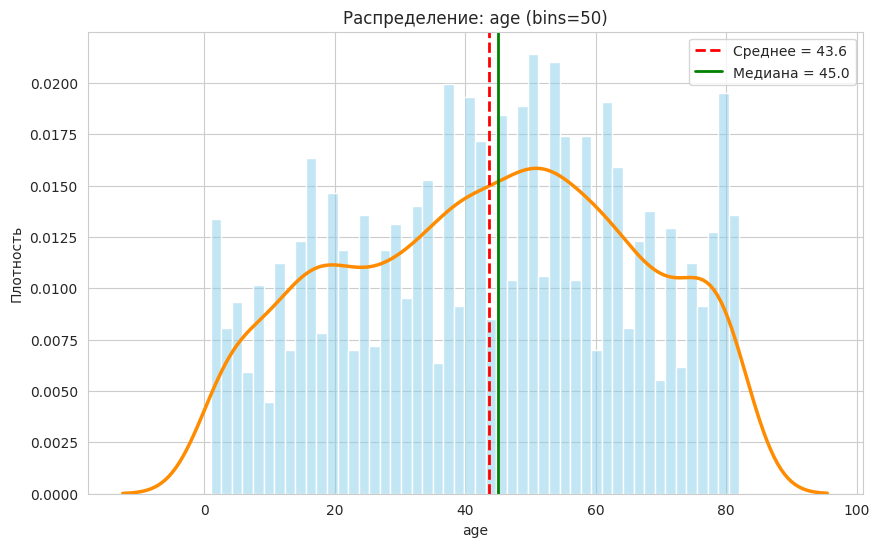

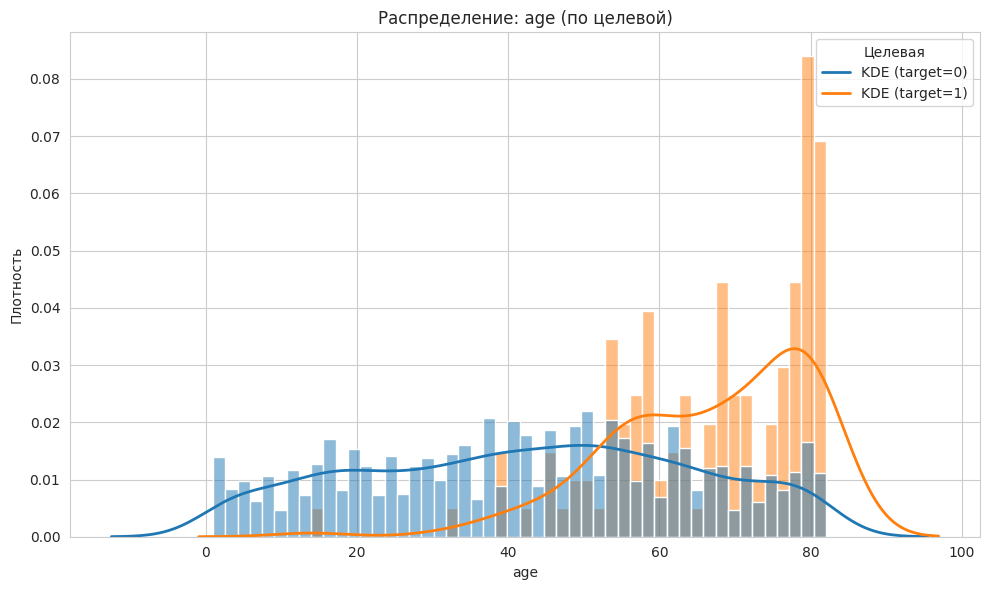

    ✓ age (с разделением по целевой + KDE)

🔍 ДИАГНОСТИКА для avg_glucose_level:
   Уникальные значения (первые 5): [ 80.4  115.47  58.42 110.38 105.05]
   Тип данных: float64

  📊 Обработка 2/3: avg_glucose_level
   Рисую гистограмму для avg_glucose_level, данные из X_train


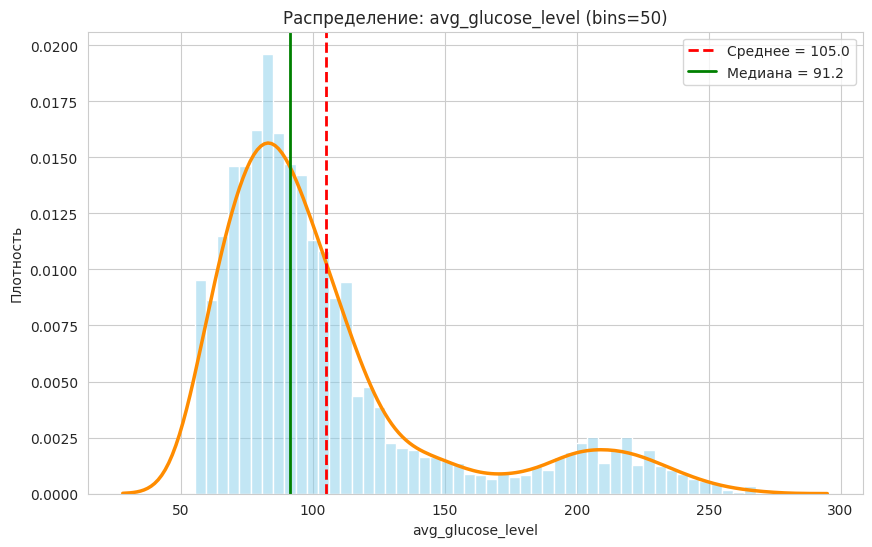

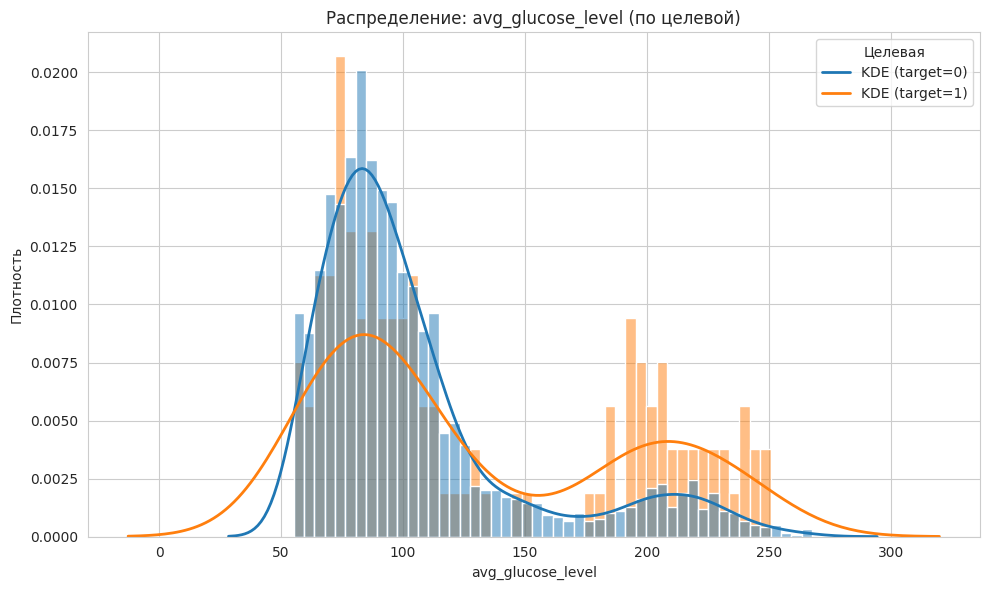

    ✓ avg_glucose_level (с разделением по целевой + KDE)

🔍 ДИАГНОСТИКА для bmi:
   Уникальные значения (первые 5): [57.5 22.6 24.7 26.3 20.4]
   Тип данных: float64

  📊 Обработка 3/3: bmi
   Рисую гистограмму для bmi, данные из X_train


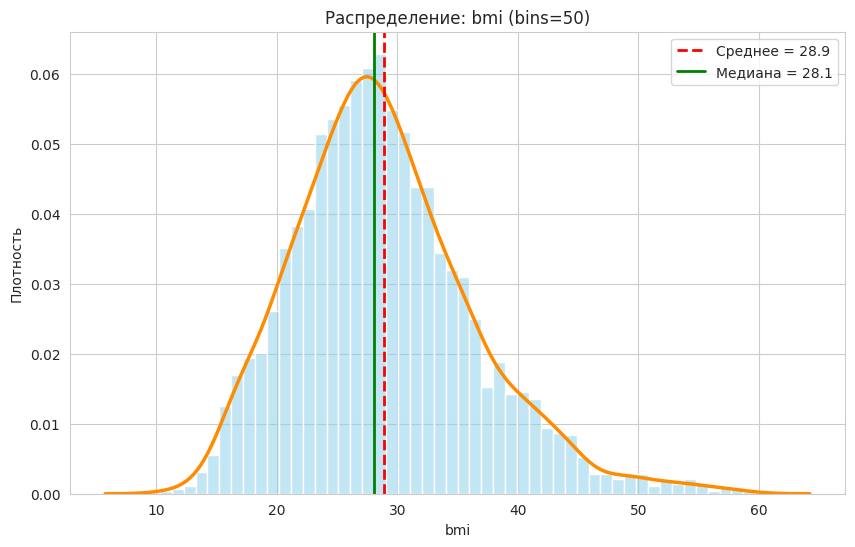

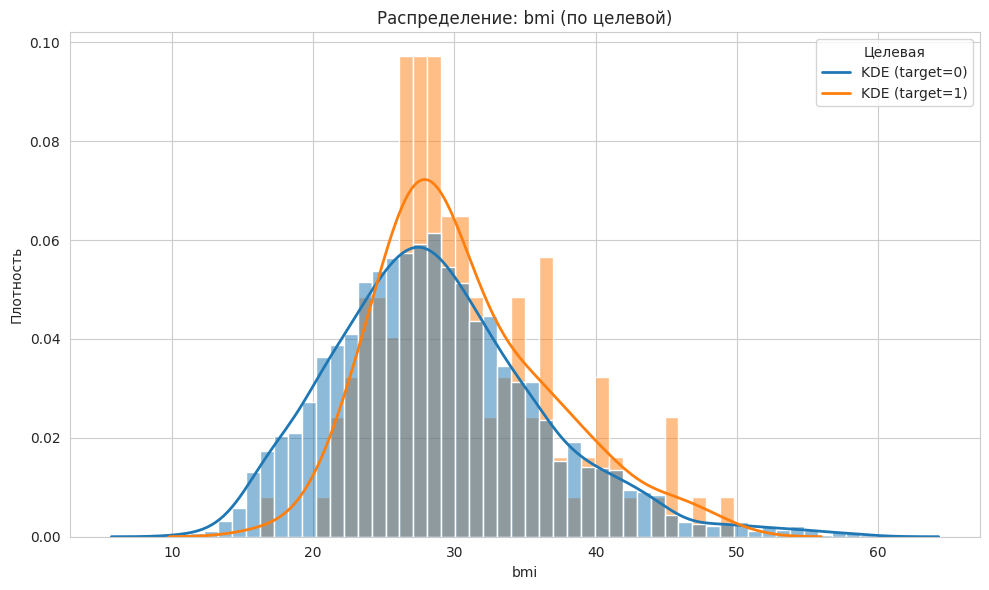

    ✓ bmi (с разделением по целевой + KDE)

✅ Все графики сохранены в: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots


In [13]:
# БЛОК 2.4. ВИЗУАЛИЗАЦИЯ ЧИСЛОВЫХ КОЛОНОК (только непрерывные)

print("\n" + "=" * 50)
print("2.4. ВИЗУАЛИЗАЦИЯ ЧИСЛОВЫХ КОЛОНОК (только непрерывные)")
print("=" * 50)

# BINS по формуле (рекомендация)
auto_bins = int(np.sqrt(len(X_train)))
print(f"\n📊 Рекомендация: для {len(X_train)} строк оптимально bins = {auto_bins}")
print(f"🔧 Используется: bins = {BINS}")

# Определяем числовые колонки (для независимости блока)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

# Определяем непрерывные колонки (исключаем бинарные)
continuous_cols = [col for col in numeric_cols if X_train[col].nunique() > 2]

print(f"\n📌 Непрерывные колонки для анализа: {continuous_cols}")

if len(continuous_cols) > 0:
    print(f"\n💾 Сохраняем графики в: {PLOTS_PATH}")

    for i, col in enumerate(continuous_cols):
        # Вычисляем среднее и медиану
        mean_val = X_train[col].mean()
        median_val = X_train[col].median()

        # Диагностика
        print(f"\n🔍 ДИАГНОСТИКА для {col}:")
        print(f"   Уникальные значения (первые 5): {X_train[col].unique()[:5]}")
        print(f"   Тип данных: {X_train[col].dtype}")

        print(f"\n  📊 Обработка {i+1}/{len(continuous_cols)}: {col}")

        # ========== ПРОСТАЯ ГИСТОГРАММА (без hue) ==========
        plt.figure(figsize=(10, 6))

        print(f"   Рисую гистограмму для {col}, данные из X_train")

        # Гистограмма в плотностях
        sns.histplot(X_train[col], bins=BINS, color='skyblue', alpha=0.5, stat='density')

        # KDE линия
        sns.kdeplot(X_train[col], color='darkorange', linewidth=2.5)

        # Вертикальные линии
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее = {mean_val:.1f}')
        plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Медиана = {median_val:.1f}')

        plt.title(f'Распределение: {col} (bins={BINS})')
        plt.xlabel(col)
        plt.ylabel('Плотность')
        plt.legend()
        plt.savefig(f'{PLOTS_PATH}/distribution_{col}.png', dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()

        # ========== ГРАФИК С РАЗДЕЛЕНИЕМ ПО ЦЕЛЕВОЙ (hue) ==========
        if HUE_BY_TARGET and task_type == 'classification':
            plt.figure(figsize=(10, 6))

            # Создаём временный DataFrame для hue
            plot_df = pd.DataFrame({col: X_train[col], 'target': y_train})

            # Гистограмма с разделением по целевой
            sns.histplot(data=plot_df, x=col, hue='target', bins=BINS,
                         alpha=0.5, stat='density', common_norm=False)

            # KDE для каждого класса
            for target_val in y_train.unique():
                sns.kdeplot(data=plot_df[plot_df['target'] == target_val], x=col,
                           linewidth=2, label=f'KDE (target={target_val})')

            plt.title(f'Распределение: {col} (по целевой)')
            plt.xlabel(col)
            plt.ylabel('Плотность')
            plt.legend(title='Целевая')
            plt.tight_layout()
            plt.savefig(f'{PLOTS_PATH}/distribution_{col}_by_target.png', dpi=150, bbox_inches='tight')
            plt.show()
            print(f"    ✓ {col} (с разделением по целевой + KDE)")

    print(f"\n✅ Все графики сохранены в: {PLOTS_PATH}")
else:
    print("⚠ Нет непрерывных колонок для визуализации")

# Viz label


2.5. ВИЗУАЛИЗАЦИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

📊 Распределение классов:
   0: 2786 (95.7%)
   1: 125 (4.3%)

⚠ ВНИМАНИЕ: ОБНАРУЖЕН СИЛЬНЫЙ ДИСБАЛАНС КЛАССОВ!
   Соотношение классов: 22.3:1
   Модель может игнорировать редкий класс (1)

💡 ЧТО ДЕЛАТЬ:
   1. В настройках (блок 1.3) добавьте:
      RF_CLASS_WEIGHT = 'balanced'
   2. При обучении других моделей используйте class_weight='balanced'
   3. Для метрик используйте ROC-AUC, F1-score (НЕ Accuracy)
   4. Рассмотрите SMOTE для увеличения редкого класса


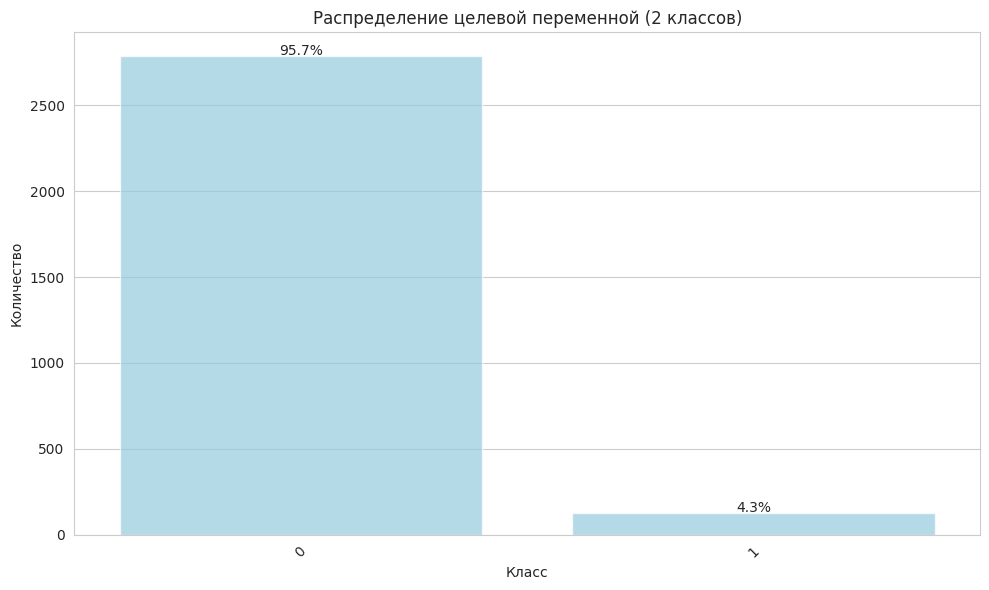


✅ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/target_distribution.png


In [14]:
# БЛОК 2.5. ВИЗУАЛИЗАЦИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

print("\n" + "=" * 50)
print("2.5. ВИЗУАЛИЗАЦИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("=" * 50)

# Создаём папку для графиков, если её нет
os.makedirs(PLOTS_PATH, exist_ok=True)

plt.figure(figsize=(10, 6))

if task_type == 'classification':
    # Для классификации столбчатая диаграмма
    class_counts = y_train.value_counts()

    sns.barplot(x=class_counts.index, y=class_counts.values,
                color='skyblue', alpha=0.7)
    plt.title(f'Распределение целевой переменной ({y_train.nunique()} классов)')
    plt.xlabel('Класс')
    plt.ylabel('Количество')
    plt.xticks(rotation=45)

    # Добавляем подписи с процентами
    for i, (cls, count) in enumerate(class_counts.items()):
        percentage = count / len(y_train) * 100
        plt.text(i, count + 5, f'{percentage:.1f}%', ha='center')

    print("\n📊 Распределение классов:")
    for cls, count in class_counts.items():
        print(f"   {cls}: {count} ({count/len(y_train)*100:.1f}%)")

    # ========== ПОДСКАЗКА ПРИ ДИСБАЛАНСЕ ==========
    min_class_pct = class_counts.min() / len(y_train) * 100
    if min_class_pct < 10:
        imbalance_ratio = class_counts.max() / class_counts.min()
        print(f"\n" + "=" * 50)
        print("⚠ ВНИМАНИЕ: ОБНАРУЖЕН СИЛЬНЫЙ ДИСБАЛАНС КЛАССОВ!")
        print("=" * 50)
        print(f"   Соотношение классов: {imbalance_ratio:.1f}:1")
        print(f"   Модель может игнорировать редкий класс ({class_counts.index[1]})")
        print(f"\n💡 ЧТО ДЕЛАТЬ:")
        print(f"   1. В настройках (блок 1.3) добавьте:")
        print(f"      RF_CLASS_WEIGHT = 'balanced'")
        print(f"   2. При обучении других моделей используйте class_weight='balanced'")
        print(f"   3. Для метрик используйте ROC-AUC, F1-score (НЕ Accuracy)")
        print(f"   4. Рассмотрите SMOTE для увеличения редкого класса")
        print("=" * 50)

else:
    # Для регрессии: гистограмма с KDE, средним и медианой
    mean_val = y_train.mean()
    median_val = y_train.median()

    print(f"\n📊 Статистика целевой переменной:")
    print(f"   Среднее: {mean_val:.2f}")
    print(f"   Медиана: {median_val:.2f}")
    print(f"   Мин: {y_train.min():.2f}")
    print(f"   Макс: {y_train.max():.2f}")
    print(f"   Станд. отклонение: {y_train.std():.2f}")

    # Гистограмма в плотностях (полупрозрачная)
    sns.histplot(y_train, bins=BINS, stat='density',
                 color='skyblue', alpha=0.5, label='Гистограмма')

    # KDE линия
    sns.kdeplot(y_train, color='darkorange', linewidth=2.5, label='KDE')

    # Вертикальные линии для среднего и медианы
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2,
                label=f'Среднее = {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2,
                label=f'Медиана = {median_val:.2f}')

    plt.title(f'Распределение целевой переменной (регрессия, bins={BINS})')
    plt.xlabel('Значение')
    plt.ylabel('Плотность')
    plt.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ График сохранён: {PLOTS_PATH}/target_distribution.png")


2.6. АНАЛИЗ БИНАРНЫХ ПРИЗНАКОВ

📊 Бинарные признаки: ['hypertension', 'heart_disease']

----------------------------------------
📌 hypertension
----------------------------------------

📊 Распределение:
   Нет (0): 2633 (90.5%)
   Есть (1): 278 (9.5%)

📊 Связь с целевой переменной:
   Нет (0): 3.5% целевой переменной
   Есть (1): 12.2% целевой переменной


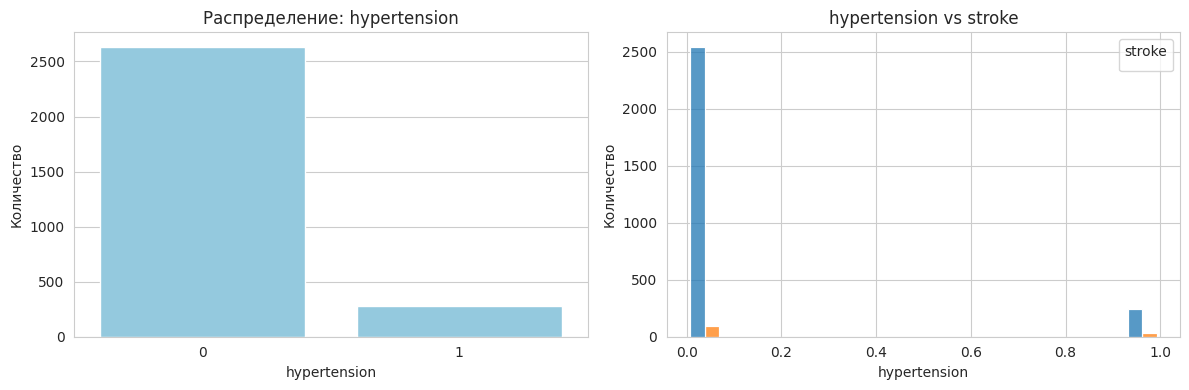


   ✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/binary_hypertension.png

----------------------------------------
📌 heart_disease
----------------------------------------

📊 Распределение:
   Нет (0): 2766 (95.0%)
   Есть (1): 145 (5.0%)

📊 Связь с целевой переменной:
   Нет (0): 3.7% целевой переменной
   Есть (1): 16.6% целевой переменной


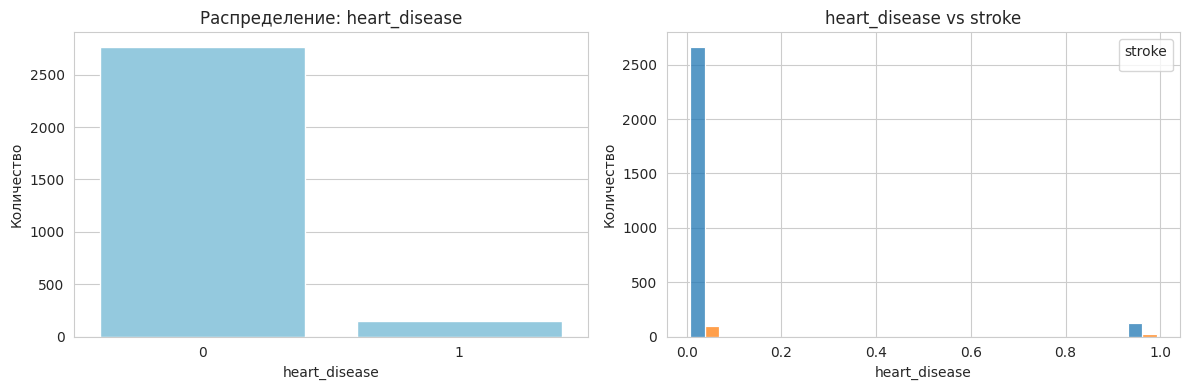


   ✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/binary_heart_disease.png

📊 СВОДНАЯ ТАБЛИЦА БИНАРНЫХ ПРИЗНАКОВ


,Признак,Доля 1 (%),stroke при 0 (%),stroke при 1 (%),Повышение риска
0,hypertension,9.5%,3.5%,12.2%,3.5x
1,heart_disease,5.0%,3.7%,16.6%,4.5x



✅ Анализ бинарных признаков завершён


In [15]:
# БЛОК 2.6. АНАЛИЗ БИНАРНЫХ ПРИЗНАКОВ
print("\n" + "=" * 50)
print("2.6. АНАЛИЗ БИНАРНЫХ ПРИЗНАКОВ")
print("=" * 50)

# Находим бинарные колонки (0/1)
binary_cols = [col for col in X_train.columns
               if X_train[col].dtype in ['int64', 'float64']
               and X_train[col].nunique() <= 2]

if len(binary_cols) > 0:
    print(f"\n📊 Бинарные признаки: {binary_cols}")

    for col in binary_cols:
        print(f"\n" + "-" * 40)
        print(f"📌 {col}")
        print("-" * 40)

        # 1. Распределение (сколько 0 и 1)
        print(f"\n📊 Распределение:")
        value_counts = X_train[col].value_counts()
        for val, cnt in value_counts.items():
            pct = cnt / len(X_train) * 100
            val_name = "Есть" if val == 1 else "Нет"
            print(f"   {val_name} ({val}): {cnt} ({pct:.1f}%)")

        # 2. Связь с целевой (проценты)
        cross_tab = pd.crosstab(X_train[col], y_train, normalize='index') * 100
        print(f"\n📊 Связь с целевой переменной:")
        for idx in cross_tab.index:
            val_name = "Есть" if idx == 1 else "Нет"
            target_pct = cross_tab.loc[idx, 1] if 1 in cross_tab.columns else 0
            print(f"   {val_name} ({idx}): {target_pct:.1f}% целевой переменной")

        # 3. Визуализация
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # График 1: распределение
        sns.countplot(x=X_train[col], ax=axes[0], color='skyblue')
        axes[0].set_title(f'Распределение: {col}')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Количество')

        # График 2: связь с целевой
        plot_df = pd.DataFrame({col: X_train[col], TARGET_COLUMN: y_train})
        sns.histplot(data=plot_df, x=col, hue=TARGET_COLUMN,
                    multiple='dodge', shrink=0.8, ax=axes[1])
        axes[1].set_title(f'{col} vs {TARGET_COLUMN}')
        axes[1].set_xlabel(col)
        axes[1].set_ylabel('Количество')
        axes[1].legend(title=TARGET_COLUMN)

        plt.tight_layout()
        plt.savefig(f'{PLOTS_PATH}/binary_{col}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n   ✓ График сохранён: {PLOTS_PATH}/binary_{col}.png")

    # Сводная таблица по всем бинарным
    print("\n" + "=" * 50)
    print("📊 СВОДНАЯ ТАБЛИЦА БИНАРНЫХ ПРИЗНАКОВ")
    print("=" * 50)

    summary_data = []
    for col in binary_cols:
        total_1 = X_train[col].sum()
        pct_1 = total_1 / len(X_train) * 100
        # Доля целевой при значении 1
        target_rate_1 = y_train[X_train[col] == 1].mean() * 100 if total_1 > 0 else 0
        # Доля целевой при значении 0
        target_rate_0 = y_train[X_train[col] == 0].mean() * 100

        summary_data.append({
            'Признак': col,
            'Доля 1 (%)': f'{pct_1:.1f}%',
            f'{TARGET_COLUMN} при 0 (%)': f'{target_rate_0:.1f}%',
            f'{TARGET_COLUMN} при 1 (%)': f'{target_rate_1:.1f}%',
            'Повышение риска': f'{target_rate_1 / target_rate_0:.1f}x' if target_rate_0 > 0 else '—'
        })

    summary_df = pd.DataFrame(summary_data)
    display(summary_df)

    print("\n✅ Анализ бинарных признаков завершён")
else:
    print("\n⚠ Бинарных признаков не обнаружено")

# БЛОК 3. Пустоты

In [16]:
# БЛОК 3.1. ПОИСК ВСЕХ ВИДОВ ПУСТОТ

print("\n" + "=" * 50)
print("3.1. ПОИСК ВСЕХ ВИДОВ ПУСТОТ")
print("=" * 50)

def find_all_empty(df, col):

    empty_mask = pd.Series(False, index=df.index)

    # 1. Стандартные NaN
    empty_mask = empty_mask | df[col].isna()

    # 2. Для строковых колонок ищем маркеры
    if df[col].dtype == 'object':
        # Приводим к строке и ищем маркеры
        col_str = df[col].astype(str).str.lower()
        for marker in EMPTY_MARKERS_STR:
            empty_mask = empty_mask | (col_str == marker.lower())

    # 3. Для числовых колонок ищем числовые маркеры
    if pd.api.types.is_numeric_dtype(df[col]):
        for marker in EMPTY_MARKERS_NUM:
            empty_mask = empty_mask | (df[col] == marker)

    return empty_mask

# Копируем X_train для анализа
X_train_analysis = X_train.copy()

# Создаём словарь для хранения информации о пустотах
empty_info = {}

print("\n🔍 Поиск пустот во всех колонках X_train:\n")

for col in X_train_analysis.columns:
    # Находим все виды пустот
    empty_mask = find_all_empty(X_train_analysis, col)
    empty_count = empty_mask.sum()

    if empty_count > 0:
        # Сохраняем информацию
        empty_info[col] = {
            'count': empty_count,
            'percent': (empty_count / len(X_train_analysis)) * 100,
            'mask': empty_mask
        }

        # Показываем найденные значения
        print(f"📌 {col}:")
        print(f"   Пропусков: {empty_count} ({empty_count/len(X_train_analysis)*100:.1f}%)")

        # Показываем примеры найденных пустот (первые 5)
        empty_values = X_train_analysis.loc[empty_mask, col].head(5).tolist()
        print(f"   Примеры: {empty_values}")
        print()

# Итоговая таблица
if empty_info:
    print("\n" + "-" * 50)
    print("📊 СВОДНАЯ ТАБЛИЦА ПУСТОТ:")
    print("-" * 50)

    summary_df = pd.DataFrame([
        {'Колонка': col, 'Пропусков': info['count'], 'Процент': info['percent']}
        for col, info in empty_info.items()
    ]).sort_values('Пропусков', ascending=False)

    display(summary_df)
else:
    print("\n✅ Пустот (включая скрытые) не обнаружено")

# Проверяем y_train
print("\n" + "-" * 50)
print("🎯 ПРОВЕРКА y_train:")
print("-" * 50)

y_empty_mask = find_all_empty(pd.DataFrame({'y': y_train}), 'y')
y_empty_count = y_empty_mask.sum()

if y_empty_count > 0:
    print(f"⚠ В y_train найдено {y_empty_count} пустот")
    print(f"   Примеры: {y_train[y_empty_mask].head(5).tolist()}")
else:
    print("✅ В y_train пустот не обнаружено")

# Рекомендации по обработке (только для признаков, не для целевой)
if len(empty_info) > 0:
    print("\n📋 РЕКОМЕНДАЦИИ ПО ОБРАБОТКЕ ПРОПУСКОВ В ПРИЗНАКАХ (X_train):")
    print("-" * 60)

    for col, info in empty_info.items():
        percent = info['percent']

        if percent > 60:
            print(f"  {col}: {percent:.1f}% → 🗑 УДАЛИТЬ колонку")
        elif percent > 20:
            print(f"  {col}: {percent:.1f}% → ⚠ СОЗДАТЬ ФЛАГ + заполнить")
        elif percent > 5:
            print(f"  {col}: {percent:.1f}% → 📝 ЗАПОЛНИТЬ (модой/медианой) или СОЗДАТЬ ФЛАГ")
        else:
            print(f"  {col}: {percent:.1f}% → ✅ ЗАПОЛНИТЬ (модой/медианой)")
else:
    print("\n✅ В признаках (X_train) пустот не обнаружено, обработка не требуется")


3.1. ПОИСК ВСЕХ ВИДОВ ПУСТОТ

🔍 Поиск пустот во всех колонках X_train:

📌 smoking_status:
   Пропусков: 832 (28.6%)
   Примеры: ['unknown', 'unknown', 'unknown', 'unknown', 'unknown']


--------------------------------------------------
📊 СВОДНАЯ ТАБЛИЦА ПУСТОТ:
--------------------------------------------------


,Колонка,Пропусков,Процент
0,smoking_status,832,28.581244



--------------------------------------------------
🎯 ПРОВЕРКА y_train:
--------------------------------------------------
✅ В y_train пустот не обнаружено

📋 РЕКОМЕНДАЦИИ ПО ОБРАБОТКЕ ПРОПУСКОВ В ПРИЗНАКАХ (X_train):
------------------------------------------------------------
  smoking_status: 28.6% → ⚠ СОЗДАТЬ ФЛАГ + заполнить


In [17]:
# БЛОК 3.2. СТРАТЕГИЯ ОБРАБОТКИ ПРОПУСКОВ

print("\n" + "=" * 50)
print("3.2. СТРАТЕГИЯ ОБРАБОТКИ ПРОПУСКОВ")
print("=" * 50)

if missing_strategy:
    print("\n📋 Выбранные стратегии:")
    for col, (strategy, param) in missing_strategy.items():
        if param:
            print(f"  {col}: {strategy} (параметр: {param})")
        else:
            print(f"  {col}: {strategy}")
else:
    print("\n⚠ Словарь missing_strategy пуст.")
    print("   Заполните его на основе анализа пустот (блок 3.1).")
    print("   Рекомендации по обработке приведены в блоке 3.1.")


3.2. СТРАТЕГИЯ ОБРАБОТКИ ПРОПУСКОВ

📋 Выбранные стратегии:
  smoking_status: constant (параметр: unknown)


In [18]:
# БЛОК 3.3. ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ ПРОПУСКОВ

# Применяем выбранные стратегии к X_train
# Создаём копию для очищенных данных

X_train_clean = X_train.copy()
flag_columns = []  # для хранения названий созданных флагов

print("\n" + "=" * 50)
print("3.3. ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ")
print("=" * 50)

if missing_strategy:
    for col, (strategy, param) in missing_strategy.items():
        if col not in X_train_clean.columns:
            print(f"⚠ Колонка '{col}' не найдена, пропускаем")
            continue

        print(f"\n📌 Обработка колонки: {col}")

        if strategy == 'drop_column':
            X_train_clean = X_train_clean.drop(columns=[col])
            print(f"   ✓ Колонка удалена")

        elif strategy == 'mode':
            mode_val = X_train_clean[col].mode()[0]
            X_train_clean[col] = X_train_clean[col].fillna(mode_val)
            print(f"   ✓ Заполнено модой: {mode_val}")

        elif strategy == 'median':
            median_val = X_train_clean[col].median()
            X_train_clean[col] = X_train_clean[col].fillna(median_val)
            print(f"   ✓ Заполнено медианой: {median_val:.2f}")

        elif strategy == 'mean':
            mean_val = X_train_clean[col].mean()
            X_train_clean[col] = X_train_clean[col].fillna(mean_val)
            print(f"   ✓ Заполнено средним: {mean_val:.2f}")

        elif strategy == 'constant':
            constant_val = param if param else 'unknown'
            X_train_clean[col] = X_train_clean[col].fillna(constant_val)
            print(f"   ✓ Заполнено константой: {constant_val}")

        elif strategy == 'flag':
            # Создаём флаг пропуска
            flag_col = f'{col}_missing_flag'
            X_train_clean[flag_col] = X_train_clean[col].isna().astype(int)
            flag_columns.append(flag_col)

            # Определяем значение для заполнения пропусков
            if param == 'mode':
                fill_val = X_train_clean[col].mode()[0]
            elif param == 'median':
                fill_val = X_train_clean[col].median()
            elif param == 'mean':
                fill_val = X_train_clean[col].mean()
            elif param == 'constant':
                # Для строковых колонок
                fill_val = 'unknown'
            elif isinstance(param, (int, float)):
                # Для числовых колонок
                fill_val = param
            else:
                # Значение по умолчанию, если param не распознан
                fill_val = 'unknown'

            X_train_clean[col] = X_train_clean[col].fillna(fill_val)
            print(f"   ✓ Создан флаг: {flag_col}")
            print(f"   ✓ Заполнено значением: {fill_val}")

        else:
            print(f"   ⚠ Неизвестная стратегия: {strategy}")

    print("\n" + "-" * 40)
    print(f"✅ Обработка пропусков завершена")
    if flag_columns:
        print(f"   Созданы флаги пропусков: {flag_columns}")
else:
    print("\n⚠ Словарь missing_strategy пуст, обработка пропусков не выполнена")


3.3. ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ

📌 Обработка колонки: smoking_status
   ✓ Заполнено константой: unknown

----------------------------------------
✅ Обработка пропусков завершена


In [19]:
# БЛОК 3.4. ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ

print("\n" + "=" * 50)
print("3.4. ПРОВЕРКА РЕЗУЛЬТАТА")
print("=" * 50)

# Проверяем, был ли выполнен блок 3.3
if 'X_train_clean' not in locals():
    print("\n⚠ X_train_clean не найден. Сначала выполните блок 3.3.")
else:
    remaining_missing = X_train_clean.isnull().sum().sum()

    if remaining_missing > 0:
        print(f"\n⚠ Внимание: осталось {remaining_missing} пропусков")
        print("   Колонки с пропусками:")
        missing_cols = X_train_clean.columns[X_train_clean.isnull().any()].tolist()
        for col in missing_cols:
            count = X_train_clean[col].isnull().sum()
            print(f"     {col}: {count} пропусков")
    else:
        print("\n✅ Пропусков не осталось. Данные очищены.")

    print(f"\n📊 Итоговая форма X_train_clean: {X_train_clean.shape}")


3.4. ПРОВЕРКА РЕЗУЛЬТАТА

✅ Пропусков не осталось. Данные очищены.

📊 Итоговая форма X_train_clean: (2911, 10)


In [20]:
# БЛОК 3.5. СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ

print("\n" + "=" * 50)
print("3.5. СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ")
print("=" * 50)

# Проверяем, существует ли X_train_clean
if 'X_train_clean' not in locals():
    print("\n⚠ X_train_clean не найден. Сначала выполните блоки 3.3 и 3.4.")
else:
    # Сохраняем в checkpoints
    cleaned_path = f'{CHECKPOINT_PATH}/03_missing_handled.csv'
    X_train_clean.to_csv(cleaned_path, index=False)
    print(f"✓ Сохранено: {cleaned_path}")

    # Обновляем X_train для следующих блоков
    X_train = X_train_clean.copy()
    print("✓ X_train обновлён для следующих блоков")


3.5. СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ
✓ Сохранено: /content/drive/MyDrive/ml_learning/datasets/stroke/checkpoints/03_missing_handled.csv
✓ X_train обновлён для следующих блоков


# БЛОК 4. Выбросы


4.1. ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ (BOXPLOT)

📊 Все числовые колонки: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
   Бинарные (исключены из boxplot): ['hypertension', 'heart_disease']
   Непрерывные (анализируем): ['age', 'avg_glucose_level', 'bmi']
  ✓ Сохранён boxplot для age
  ✓ Сохранён boxplot для avg_glucose_level
  ✓ Сохранён boxplot для bmi


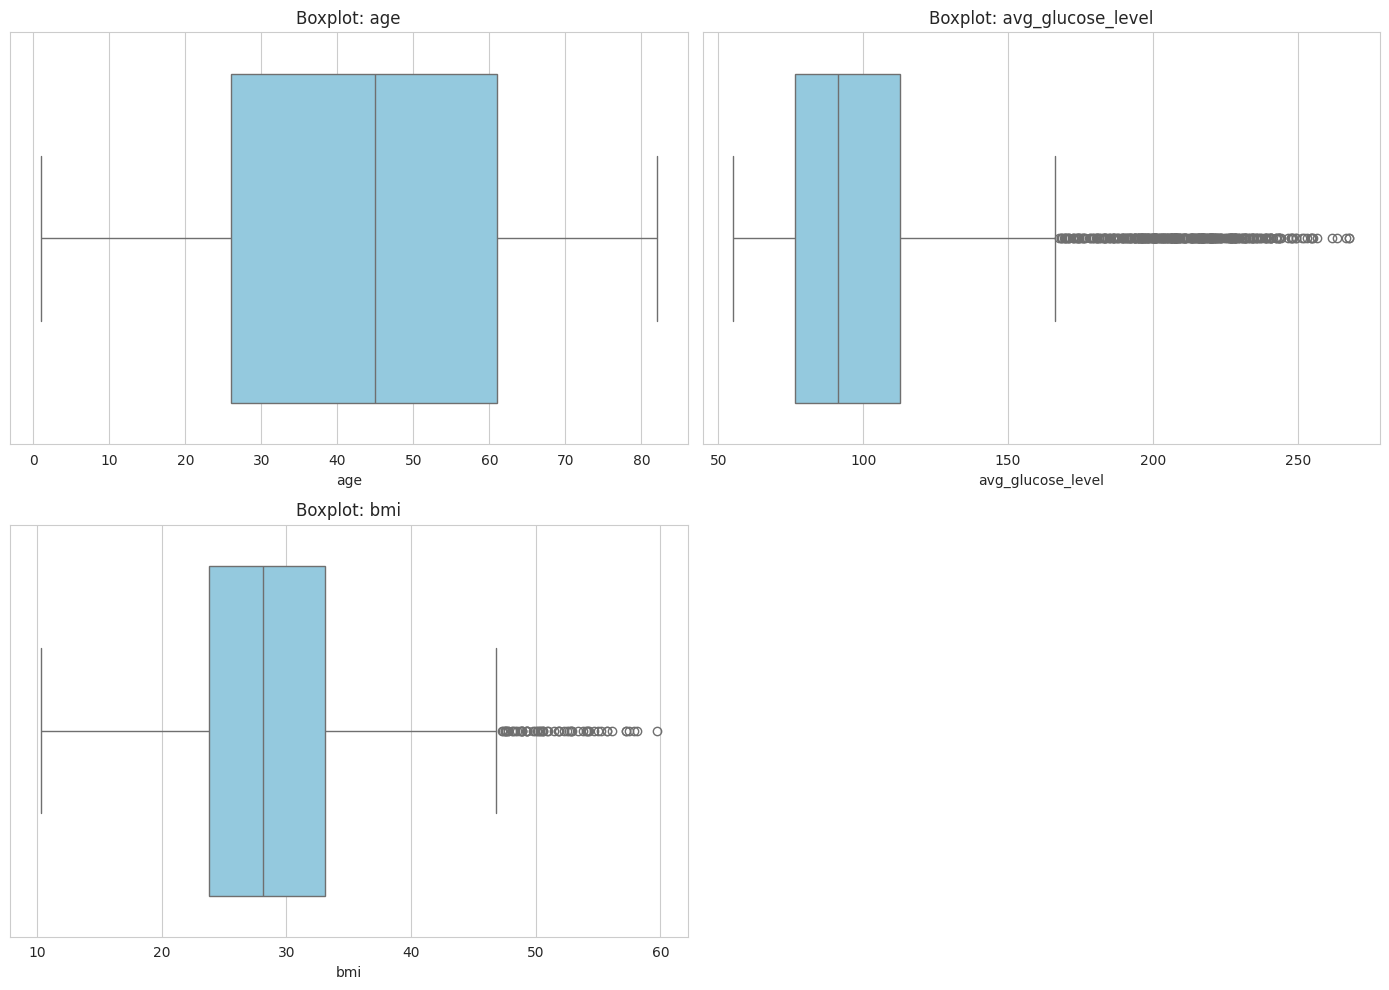


✅ Все boxplot сохранены в: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots


In [21]:
# БЛОК 4.1. ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ (BOXPLOT)

# boxplot для каждой числовой колонки (только для непрерывных)

print("\n" + "=" * 50)
print("4.1. ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ (BOXPLOT)")
print("=" * 50)

# Определяем числовые колонки (после обработки пропусков)
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Исключаем бинарные колонки
binary_cols = [col for col in numeric_cols if X_train[col].nunique() <= 2]
continuous_cols = [col for col in numeric_cols if X_train[col].nunique() > 2]

print(f"\n📊 Все числовые колонки: {list(numeric_cols)}")
print(f"   Бинарные (исключены из boxplot): {binary_cols}")
print(f"   Непрерывные (анализируем): {continuous_cols}")

if len(continuous_cols) > 0:
    # Создаём сетку графиков
    n_cols = len(continuous_cols)
    n_rows = (n_cols + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(continuous_cols):
        # Boxplot
        sns.boxplot(x=X_train[col], ax=axes[i], color='skyblue')
        axes[i].set_title(f'Boxplot: {col}')
        axes[i].set_xlabel(col)

        # Сохраняем отдельный график
        plt.figure(figsize=(10, 4))
        sns.boxplot(x=X_train[col], color='skyblue')
        plt.title(f'Boxplot: {col}')
        plt.xlabel(col)
        plt.savefig(f'{PLOTS_PATH}/boxplot_{col}.png', dpi=150, bbox_inches='tight')
        plt.close()
        print(f"  ✓ Сохранён boxplot для {col}")

    # Скрываем пустые подграфики
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{PLOTS_PATH}/all_boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n✅ Все boxplot сохранены в: {PLOTS_PATH}")
else:
    print("⚠ Нет непрерывных колонок для анализа выбросов")

In [22]:
# БЛОК 4.2. СТАТИСТИКА ВЫБРОСОВ ПО МЕТОДУ IQR

print("\n" + "=" * 50)
print("4.2. СТАТИСТИКА ВЫБРОСОВ (IQR)")
print("=" * 50)

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

if len(numeric_cols) > 0:
    outliers_info = []

    for col in numeric_cols:
        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_lower = X_train[X_train[col] < lower_bound][col]
        outliers_upper = X_train[X_train[col] > upper_bound][col]

        total_outliers = len(outliers_lower) + len(outliers_upper)
        outlier_percent = (total_outliers / len(X_train)) * 100

        outliers_info.append({
            'Колонка': col,
            'Q1': f'{Q1:.2f}',
            'Q3': f'{Q3:.2f}',
            'IQR': f'{IQR:.2f}',
            'Нижняя граница': f'{lower_bound:.2f}',
            'Верхняя граница': f'{upper_bound:.2f}',
            'Выбросов': total_outliers,
            'Процент': f'{outlier_percent:.1f}%'
        })

        print(f"\n📌 {col}:")
        print(f"   Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
        print(f"   Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"   Выбросов: {total_outliers} ({outlier_percent:.1f}%)")

        if total_outliers > 0:
            print(f"   Примеры низких выбросов: {outliers_lower.head(3).tolist()}")
            print(f"   Примеры высоких выбросов: {outliers_upper.head(3).tolist()}")

    # Сводная таблица
    print("\n" + "-" * 50)
    print("📊 СВОДНАЯ ТАБЛИЦА ВЫБРОСОВ:")
    print("-" * 50)
    outliers_df = pd.DataFrame(outliers_info)
    display(outliers_df)

else:
    print("⚠ Нет числовых колонок для анализа выбросов")


4.2. СТАТИСТИКА ВЫБРОСОВ (IQR)

📌 age:
   Q1 = 26.00, Q3 = 61.00, IQR = 35.00
   Границы: [-26.50, 113.50]
   Выбросов: 0 (0.0%)

📌 hypertension:
   Q1 = 0.00, Q3 = 0.00, IQR = 0.00
   Границы: [0.00, 0.00]
   Выбросов: 278 (9.5%)
   Примеры низких выбросов: []
   Примеры высоких выбросов: [1, 1, 1]

📌 heart_disease:
   Q1 = 0.00, Q3 = 0.00, IQR = 0.00
   Границы: [0.00, 0.00]
   Выбросов: 145 (5.0%)
   Примеры низких выбросов: []
   Примеры высоких выбросов: [1, 1, 1]

📌 avg_glucose_level:
   Q1 = 76.35, Q3 = 112.80, IQR = 36.45
   Границы: [21.67, 167.47]
   Выбросов: 347 (11.9%)
   Примеры низких выбросов: []
   Примеры высоких выбросов: [217.39, 213.22, 210.23]

📌 bmi:
   Q1 = 23.80, Q3 = 33.10, IQR = 9.30
   Границы: [9.85, 47.05]
   Выбросов: 60 (2.1%)
   Примеры низких выбросов: []
   Примеры высоких выбросов: [57.5, 50.6, 49.3]

--------------------------------------------------
📊 СВОДНАЯ ТАБЛИЦА ВЫБРОСОВ:
--------------------------------------------------


,Колонка,Q1,Q3,IQR,Нижняя граница,Верхняя граница,Выбросов,Процент
0,age,26.00,61.00,35.00,-26.50,113.50,0,0.0%
1,hypertension,0.00,0.00,0.00,0.00,0.00,278,9.5%
2,heart_disease,0.00,0.00,0.00,0.00,0.00,145,5.0%
3,avg_glucose_level,76.35,112.80,36.45,21.67,167.47,347,11.9%
4,bmi,23.80,33.10,9.30,9.85,47.05,60,2.1%


In [23]:
# БЛОК 4.3. СТРАТЕГИЯ ОБРАБОТКИ ВЫБРОСОВ

print("\n" + "=" * 50)
print("4.3. СТРАТЕГИЯ ОБРАБОТКИ ВЫБРОСОВ")
print("=" * 50)

if outliers_strategy:
    print("\n📋 Выбранные стратегии:")
    for col, (strategy, param) in outliers_strategy.items():
        if param:
            print(f"  {col}: {strategy} (параметр: {param})")
        else:
            print(f"  {col}: {strategy}")
else:
    print("\n⚠ Словарь outliers_strategy пуст.")
    print("   Заполните его на основе анализа выбросов.")
    print("\n💡 Рекомендации:")
    print("   - Если выбросов мало (<5%) → можно оставить (keep)")
    print("   - Если выбросы реальные данные → оставить (keep)")
    print("   - Если выбросы это ошибки → удалить (remove)")
    print("   - Если нужно уменьшить влияние → обрезать (cap) или логарифм (log)")


4.3. СТРАТЕГИЯ ОБРАБОТКИ ВЫБРОСОВ

📋 Выбранные стратегии:
  age: keep
  avg_glucose_level: keep
  bmi: keep


In [24]:
# БЛОК 4.4: ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ ВЫБРОСОВ

# Применяем выбранные стратегии к X_train
X_train_clean = X_train.copy()
outlier_flags = []  # для хранения названий созданных флагов
rows_to_remove = []  # для хранения индексов строк, которые нужно удалить

print("\n" + "=" * 50)
print("4.4. ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ")
print("=" * 50)

if outliers_strategy:
    for col, (strategy, param) in outliers_strategy.items():
        if col not in X_train_clean.columns:
            print(f"⚠ Колонка '{col}' не найдена, пропускаем")
            continue

        print(f"\n📌 Обработка колонки: {col}")

        # Вычисляем границы для IQR
        Q1 = X_train_clean[col].quantile(0.25)
        Q3 = X_train_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        if strategy == 'keep':
            print(f"   ✓ Оставлено без изменений")

        elif strategy == 'cap':
            # Обрезаем выбросы
            X_train_clean[col] = X_train_clean[col].clip(lower_bound, upper_bound)
            print(f"   ✓ Выбросы обрезаны по границам: [{lower_bound:.2f}, {upper_bound:.2f}]")

        elif strategy == 'remove':
            # Удаляем строки с выбросами
            outlier_mask = (X_train_clean[col] < lower_bound) | (X_train_clean[col] > upper_bound)
            outlier_indices = X_train_clean.index[outlier_mask].tolist()
            rows_to_remove.extend(outlier_indices)
            print(f"   ✓ Найдено {len(outlier_indices)} строк с выбросами (будут удалены позже)")

        elif strategy == 'log':
            # Логарифмическое преобразование (только для положительных значений)
            if (X_train_clean[col] <= 0).any():
                print(f"   ⚠ В колонке есть нулевые или отрицательные значения, логарифм невозможен")
                print(f"   → применяем log1p (log(x+1))")
                X_train_clean[col] = np.log1p(X_train_clean[col])
            else:
                X_train_clean[col] = np.log(X_train_clean[col])
            print(f"   ✓ Применено логарифмическое преобразование")

        elif strategy == 'flag':
            # Создаём флаг выброса
            flag_col = f'{col}_outlier_flag'
            outlier_mask = (X_train_clean[col] < lower_bound) | (X_train_clean[col] > upper_bound)
            X_train_clean[flag_col] = outlier_mask.astype(int)
            outlier_flags.append(flag_col)
            print(f"   ✓ Создан флаг выброса: {flag_col}")
            print(f"   ✓ Выбросов помечено: {outlier_mask.sum()}")

        else:
            print(f"   ⚠ Неизвестная стратегия: {strategy}")

    # Удаляем строки с выбросами (если выбрана стратегия remove)
    if rows_to_remove:
        rows_to_remove = list(set(rows_to_remove))  # убираем дубликаты
        X_train_clean = X_train_clean.drop(index=rows_to_remove)
        print(f"\n🗑 Удалено строк с выбросами: {len(rows_to_remove)}")
        print(f"   Новая форма X_train: {X_train_clean.shape}")

    print("\n" + "-" * 40)
    print(f"✅ Обработка выбросов завершена")
    if outlier_flags:
        print(f"   Созданы флаги выбросов: {outlier_flags}")
else:
    print("\n⚠ Словарь outliers_strategy пуст, обработка выбросов не выполнена")


4.4. ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ

📌 Обработка колонки: age
   ✓ Оставлено без изменений

📌 Обработка колонки: avg_glucose_level
   ✓ Оставлено без изменений

📌 Обработка колонки: bmi
   ✓ Оставлено без изменений

----------------------------------------
✅ Обработка выбросов завершена


In [25]:
# БЛОК 4.5. ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ

print("\n" + "=" * 50)
print("4.5. ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ")
print("=" * 50)

if outliers_strategy:
    # Проверяем, существует ли X_train_clean
    if 'X_train_clean' not in locals():
        print("\n⚠ X_train_clean не найден. Сначала выполните блок 4.4.")
    else:
        print("\n📊 Проверка границ для числовых колонок:")

        # Определяем числовые колонки независимо
        numeric_cols = X_train_clean.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

        # Определяем непрерывные колонки (исключаем бинарные)
        continuous_cols = [col for col in numeric_cols if X_train_clean[col].nunique() > 2]

        if len(continuous_cols) > 0:
            for col in continuous_cols:
                if col not in X_train_clean.columns:
                    continue

                Q1 = X_train_clean[col].quantile(0.25)
                Q3 = X_train_clean[col].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR

                outliers_lower = (X_train_clean[col] < lower_bound).sum()
                outliers_upper = (X_train_clean[col] > upper_bound).sum()

                if outliers_lower + outliers_upper > 0:
                    print(f"  ⚠ {col}: осталось {outliers_lower + outliers_upper} выбросов")
                else:
                    print(f"  ✅ {col}: выбросов не осталось")
        else:
            print("  ⚠ Нет непрерывных колонок для проверки")

        print(f"\n📊 Итоговая форма X_train_clean: {X_train_clean.shape}")
else:
    print("\n⚠ Обработка выбросов не выполнялась")


4.5. ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ

📊 Проверка границ для числовых колонок:
  ✅ age: выбросов не осталось
  ⚠ avg_glucose_level: осталось 347 выбросов
  ⚠ bmi: осталось 60 выбросов

📊 Итоговая форма X_train_clean: (2911, 10)


In [26]:
# БЛОК 4.6. СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ

print("\n" + "=" * 50)
print("4.6. СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ")
print("=" * 50)

# Проверяем, существует ли X_train_clean
if 'X_train_clean' not in locals():
    print("\n⚠ X_train_clean не найден. Сначала выполните блоки 4.4 и 4.5.")
else:
    # Сохраняем в checkpoints
    cleaned_path = f'{CHECKPOINT_PATH}/04_outliers_handled.csv'
    X_train_clean.to_csv(cleaned_path, index=False)
    print(f"✓ Сохранено: {cleaned_path}")

    # Обновляем X_train для следующих блоков
    X_train = X_train_clean.copy()
    print("✓ X_train обновлён для следующих блоков")


4.6. СОХРАНЕНИЕ ОЧИЩЕННЫХ ДАННЫХ
✓ Сохранено: /content/drive/MyDrive/ml_learning/datasets/stroke/checkpoints/04_outliers_handled.csv
✓ X_train обновлён для следующих блоков


# БЛОК 5. Feature Engineering

In [27]:
# БЛОК 5.1. СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ (FEATURE ENGINEERING)

print("\n" + "=" * 50)
print("5.1. СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ (FEATURE ENGINEERING)")
print("=" * 50)

# 1. Сердечно-сосудистый риск
X_train['cardio_risk'] = ((X_train['hypertension'] == 1) | (X_train['heart_disease'] == 1)).astype(int)
print("cardio_risk = (гипертония ИЛИ сердечные заболевания)")

# 2. Пожилые работающие
X_train['senior_work'] = (
    (X_train['age'] > 60) &
    (X_train['work_type'].isin(['self-employed', 'private', 'govt_job']))
).astype(int)

# 3. Семейное положение с учётом возраста (использует ever_married)
def get_marriage_risk(row):
    if row['age'] <= 60:
        return 'young'
    elif row['ever_married'] == 'yes':
        return 'senior_married'
    else:
        return 'senior_unmarried'

X_train['marriage_risk'] = X_train.apply(get_marriage_risk, axis=1)
print("   ✓ marriage_risk = young / senior_married / senior_unmarried")



5.1. СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ (FEATURE ENGINEERING)
cardio_risk = (гипертония ИЛИ сердечные заболевания)
   ✓ marriage_risk = young / senior_married / senior_unmarried


# Приложение. Анализ признаков

In [28]:
# Анализ ever_married
print("=== ever_married vs stroke ===")

# 1. Таблица с процентами
cross_tab = pd.crosstab(X_train['ever_married'], y_train, normalize='index') * 100
print("Распределение инсультов по marital status (%):")
print(cross_tab.round(1))

# 2. Повышение риска
risk_never = cross_tab.loc['No', 1] if 'No' in cross_tab.index else 0
risk_yes = cross_tab.loc['Yes', 1] if 'Yes' in cross_tab.index else 0
if risk_never > 0:
    print(f"\n→ Повышение риска для женатых: {risk_yes / risk_never:.1f}x")

# 3. Абсолютные числа
print("\nАбсолютные числа:")
print(pd.crosstab(X_train['ever_married'], y_train))

=== ever_married vs stroke ===
Распределение инсультов по marital status (%):
stroke           0    1
ever_married           
no            98.4  1.6
yes           94.3  5.7

Абсолютные числа:
stroke           0    1
ever_married           
no             977   16
yes           1809  109


In [29]:
# Стратификация по возрасту
print("\n=== С учётом возраста ===")
df_temp = X_train.copy()
df_temp['age_group'] = pd.cut(df_temp['age'], bins=[0, 40, 60, 100],
                               labels=['<40', '40-60', '60+'])

for group in ['<40', '40-60', '60+']:
    subset = df_temp[df_temp['age_group'] == group]
    if len(subset) > 0:
        cross = pd.crosstab(subset['ever_married'], y_train[subset.index], normalize='index') * 100
        print(f"\n{group}:")
        print(cross.round(1))


=== С учётом возраста ===

<40:
stroke           0    1
ever_married           
no            99.9  0.1
yes           99.0  1.0

40-60:
stroke           0    1
ever_married           
no            96.3  3.7
yes           95.9  4.1

60+:
stroke           0     1
ever_married            
no            78.9  21.1
yes           89.7  10.3


In [30]:
# Полный анализ: gender + ever_married + age_group + stroke

print("=" * 60)
print("АНАЛИЗ: ПОЛ × СЕМЕЙНОЕ ПОЛОЖЕНИЕ × ВОЗРАСТ")
print("=" * 60)

# Создаём возрастные группы
df_temp = X_train.copy()
df_temp['stroke'] = y_train
df_temp['age_group'] = pd.cut(df_temp['age'], bins=[0, 40, 60, 100],
                               labels=['<40', '40-60', '60+'])

# 1. Сводная таблица: пол × семейное положение
print("\n📊 1. ОБЩАЯ СТАТИСТИКА (пол × семейное положение)")
print("-" * 40)

cross_all = pd.crosstab([df_temp['gender'], df_temp['ever_married']],
                         df_temp['stroke'], normalize='index') * 100
print(cross_all.round(1))

# 2. Детальный анализ по возрастным группам
print("\n" + "=" * 60)
print("📊 2. ДЕТАЛЬНЫЙ АНАЛИЗ ПО ВОЗРАСТНЫМ ГРУППАМ")
print("=" * 60)

for age_group in ['<40', '40-60', '60+']:
    subset = df_temp[df_temp['age_group'] == age_group]
    if len(subset) > 0:
        print(f"\n{'='*40}")
        print(f"ВОЗРАСТ: {age_group} (n={len(subset)})")
        print('='*40)

        # Таблица: пол × семейное положение
        cross = pd.crosstab([subset['gender'], subset['ever_married']],
                            subset['stroke'], normalize='index') * 100
        print(cross.round(1))

        # Абсолютные числа
        print("\nАбсолютные числа:")
        abs_cross = pd.crosstab([subset['gender'], subset['ever_married']],
                                subset['stroke'])
        print(abs_cross)


АНАЛИЗ: ПОЛ × СЕМЕЙНОЕ ПОЛОЖЕНИЕ × ВОЗРАСТ

📊 1. ОБЩАЯ СТАТИСТИКА (пол × семейное положение)
----------------------------------------
stroke                  0    1
gender ever_married           
female no            98.1  1.9
       yes           94.5  5.5
male   no            98.8  1.2
       yes           94.0  6.0

📊 2. ДЕТАЛЬНЫЙ АНАЛИЗ ПО ВОЗРАСТНЫМ ГРУППАМ

ВОЗРАСТ: <40 (n=1273)
stroke                   0    1
gender ever_married            
female no             99.8  0.2
       yes            98.5  1.5
male   no            100.0  0.0
       yes           100.0  0.0

Абсолютные числа:
stroke                 0  1
gender ever_married        
female no            496  1
       yes           271  4
male   no            358  0
       yes           143  0

ВОЗРАСТ: 40-60 (n=884)
stroke                  0    1
gender ever_married           
female no            95.6  4.4
       yes           96.0  4.0
male   no            97.2  2.8
       yes           95.7  4.3

Абсолютные числа:
stro

ВОЗРАСТ И ИНСУЛЬТ: СРАВНЕНИЕ МУЖЧИН И ЖЕНЩИН

📊 Распределение инсультов по полу и возрасту (%):
----------------------------------------
stroke                0     1
gender age_group             
female <40         99.4   0.6
       40-49       98.6   1.4
       50-59       93.1   6.9
       60-69       92.8   7.2
       70+         85.3  14.7
male   <40        100.0   0.0
       40-49       98.1   1.9
       50-59       94.0   6.0
       60-69       91.6   8.4
       70+         86.4  13.6

📊 Абсолютные числа:
stroke              0   1
gender age_group         
female <40        767   5
       40-49      274   4
       50-59      229  17
       60-69      194  15
       70+        192  33
male   <40        501   0
       40-49      158   3
       50-59      187  12
       60-69      131  12
       70+        153  24


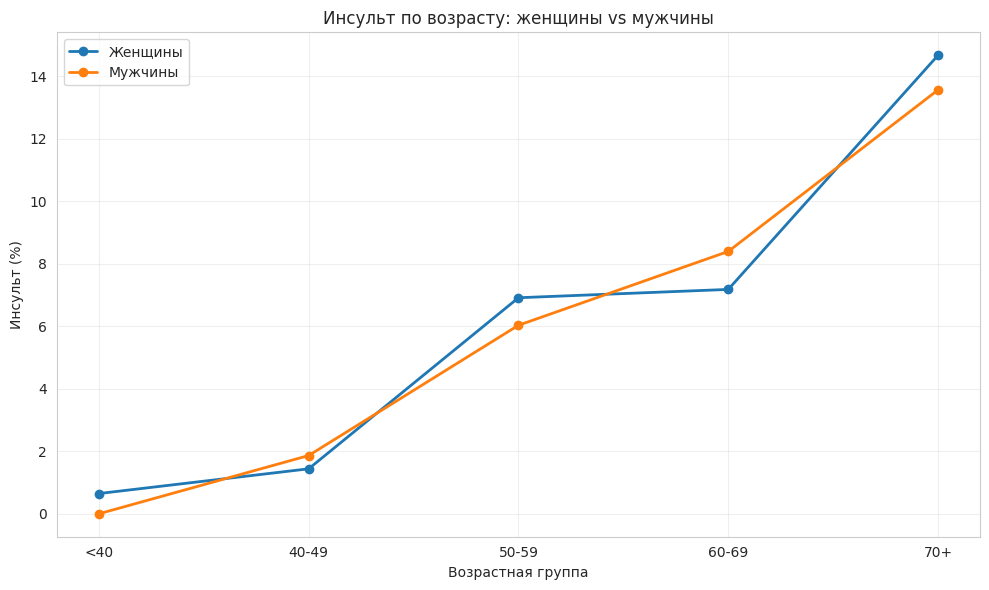


✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/stroke_by_age_gender.png

📝 КЛЮЧЕВЫЕ ВЫВОДЫ

🔹 <40:
   Женщины: 0.6% инсультов (n=772)
   Мужчины: 0.0% инсультов (n=501)

🔹 40-49:
   Женщины: 1.4% инсультов (n=278)
   Мужчины: 1.9% инсультов (n=161)

🔹 50-59:
   Женщины: 6.9% инсультов (n=246)
   Мужчины: 6.0% инсультов (n=199)

🔹 60-69:
   Женщины: 7.2% инсультов (n=209)
   Мужчины: 8.4% инсультов (n=143)

🔹 70+:
   Женщины: 14.7% инсультов (n=225)
   Мужчины: 13.6% инсультов (n=177)


In [31]:
# Анализ: возраст и инсульт в разрезе пола
print("=" * 60)
print("ВОЗРАСТ И ИНСУЛЬТ: СРАВНЕНИЕ МУЖЧИН И ЖЕНЩИН")
print("=" * 60)

# Создаём возрастные группы
df_temp = X_train.copy()
df_temp['stroke'] = y_train
df_temp['age_group'] = pd.cut(df_temp['age'], bins=[0, 40, 50, 60, 70, 100],
                               labels=['<40', '40-49', '50-59', '60-69', '70+'])

# Таблица: пол × возрастная группа × инсульт
print("\n📊 Распределение инсультов по полу и возрасту (%):")
print("-" * 40)

cross = pd.crosstab([df_temp['gender'], df_temp['age_group']],
                     df_temp['stroke'], normalize='index') * 100
print(cross.round(1))

# Абсолютные числа
print("\n📊 Абсолютные числа:")
abs_cross = pd.crosstab([df_temp['gender'], df_temp['age_group']],
                         df_temp['stroke'])
print(abs_cross)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))

# Подготовка данных для графика
plot_data = []
for gender in ['female', 'male']:
    for age_group in ['<40', '40-49', '50-59', '60-69', '70+']:
        subset = df_temp[(df_temp['gender'] == gender) & (df_temp['age_group'] == age_group)]
        if len(subset) > 0:
            stroke_rate = subset['stroke'].mean() * 100
            plot_data.append({
                'gender': 'Женщины' if gender == 'female' else 'Мужчины',
                'age_group': age_group,
                'stroke_rate': stroke_rate
            })

plot_df = pd.DataFrame(plot_data)

# Рисуем линии
for gender in ['Женщины', 'Мужчины']:
    data = plot_df[plot_df['gender'] == gender]
    ax.plot(data['age_group'], data['stroke_rate'], marker='o', linewidth=2, label=gender)

ax.set_xlabel('Возрастная группа')
ax.set_ylabel('Инсульт (%)')
ax.set_title('Инсульт по возрасту: женщины vs мужчины')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/stroke_by_age_gender.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ График сохранён: {PLOTS_PATH}/stroke_by_age_gender.png")

# Ключевые выводы
print("\n" + "=" * 60)
print("📝 КЛЮЧЕВЫЕ ВЫВОДЫ")
print("=" * 60)

for age_group in ['<40', '40-49', '50-59', '60-69', '70+']:
    female_subset = df_temp[(df_temp['gender'] == 'female') & (df_temp['age_group'] == age_group)]
    male_subset = df_temp[(df_temp['gender'] == 'male') & (df_temp['age_group'] == age_group)]

    female_rate = female_subset['stroke'].mean() * 100 if len(female_subset) > 0 else 0
    male_rate = male_subset['stroke'].mean() * 100 if len(male_subset) > 0 else 0

    print(f"\n🔹 {age_group}:")
    print(f"   Женщины: {female_rate:.1f}% инсультов (n={len(female_subset)})")
    print(f"   Мужчины: {male_rate:.1f}% инсультов (n={len(male_subset)})")

In [32]:
# Анализ ever_married
print("=== ever_married vs stroke ===")

# 1. Таблица с процентами
cross_tab = pd.crosstab(X_train['ever_married'], y_train, normalize='index') * 100
print("Распределение инсультов по marital status (%):")
print(cross_tab.round(1))

# 2. Повышение риска
risk_never = cross_tab.loc['No', 1] if 'No' in cross_tab.index else 0
risk_yes = cross_tab.loc['Yes', 1] if 'Yes' in cross_tab.index else 0
if risk_never > 0:
    print(f"\n→ Повышение риска для женатых: {risk_yes / risk_never:.1f}x")

# 3. Абсолютные числа
print("\nАбсолютные числа:")
print(pd.crosstab(X_train['ever_married'], y_train))

=== ever_married vs stroke ===
Распределение инсультов по marital status (%):
stroke           0    1
ever_married           
no            98.4  1.6
yes           94.3  5.7

Абсолютные числа:
stroke           0    1
ever_married           
no             977   16
yes           1809  109


In [33]:
# Стратификация по возрасту
print("\n=== С учётом возраста ===")
df_temp = X_train.copy()
df_temp['age_group'] = pd.cut(df_temp['age'], bins=[0, 40, 60, 100],
                               labels=['<40', '40-60', '60+'])

for group in ['<40', '40-60', '60+']:
    subset = df_temp[df_temp['age_group'] == group]
    if len(subset) > 0:
        cross = pd.crosstab(subset['ever_married'], y_train[subset.index], normalize='index') * 100
        print(f"\n{group}:")
        print(cross.round(1))


=== С учётом возраста ===

<40:
stroke           0    1
ever_married           
no            99.9  0.1
yes           99.0  1.0

40-60:
stroke           0    1
ever_married           
no            96.3  3.7
yes           95.9  4.1

60+:
stroke           0     1
ever_married            
no            78.9  21.1
yes           89.7  10.3


In [34]:
# Полный анализ: gender + ever_married + age_group + stroke

print("=" * 60)
print("АНАЛИЗ: ПОЛ × СЕМЕЙНОЕ ПОЛОЖЕНИЕ × ВОЗРАСТ")
print("=" * 60)

# Создаём возрастные группы
df_temp = X_train.copy()
df_temp['stroke'] = y_train
df_temp['age_group'] = pd.cut(df_temp['age'], bins=[0, 40, 60, 100],
                               labels=['<40', '40-60', '60+'])

# 1. Сводная таблица: пол × семейное положение
print("\n📊 1. ОБЩАЯ СТАТИСТИКА (пол × семейное положение)")
print("-" * 40)

cross_all = pd.crosstab([df_temp['gender'], df_temp['ever_married']],
                         df_temp['stroke'], normalize='index') * 100
print(cross_all.round(1))

# 2. Детальный анализ по возрастным группам
print("\n" + "=" * 60)
print("📊 2. ДЕТАЛЬНЫЙ АНАЛИЗ ПО ВОЗРАСТНЫМ ГРУППАМ")
print("=" * 60)

for age_group in ['<40', '40-60', '60+']:
    subset = df_temp[df_temp['age_group'] == age_group]
    if len(subset) > 0:
        print(f"\n{'='*40}")
        print(f"ВОЗРАСТ: {age_group} (n={len(subset)})")
        print('='*40)

        # Таблица: пол × семейное положение
        cross = pd.crosstab([subset['gender'], subset['ever_married']],
                            subset['stroke'], normalize='index') * 100
        print(cross.round(1))

        # Абсолютные числа
        print("\nАбсолютные числа:")
        abs_cross = pd.crosstab([subset['gender'], subset['ever_married']],
                                subset['stroke'])
        print(abs_cross)


АНАЛИЗ: ПОЛ × СЕМЕЙНОЕ ПОЛОЖЕНИЕ × ВОЗРАСТ

📊 1. ОБЩАЯ СТАТИСТИКА (пол × семейное положение)
----------------------------------------
stroke                  0    1
gender ever_married           
female no            98.1  1.9
       yes           94.5  5.5
male   no            98.8  1.2
       yes           94.0  6.0

📊 2. ДЕТАЛЬНЫЙ АНАЛИЗ ПО ВОЗРАСТНЫМ ГРУППАМ

ВОЗРАСТ: <40 (n=1273)
stroke                   0    1
gender ever_married            
female no             99.8  0.2
       yes            98.5  1.5
male   no            100.0  0.0
       yes           100.0  0.0

Абсолютные числа:
stroke                 0  1
gender ever_married        
female no            496  1
       yes           271  4
male   no            358  0
       yes           143  0

ВОЗРАСТ: 40-60 (n=884)
stroke                  0    1
gender ever_married           
female no            95.6  4.4
       yes           96.0  4.0
male   no            97.2  2.8
       yes           95.7  4.3

Абсолютные числа:
stro

ВОЗРАСТ И ИНСУЛЬТ: СРАВНЕНИЕ МУЖЧИН И ЖЕНЩИН

📊 Распределение инсультов по полу и возрасту (%):
----------------------------------------
stroke                0     1
gender age_group             
female <40         99.4   0.6
       40-49       98.6   1.4
       50-59       93.1   6.9
       60-69       92.8   7.2
       70+         85.3  14.7
male   <40        100.0   0.0
       40-49       98.1   1.9
       50-59       94.0   6.0
       60-69       91.6   8.4
       70+         86.4  13.6

📊 Абсолютные числа:
stroke              0   1
gender age_group         
female <40        767   5
       40-49      274   4
       50-59      229  17
       60-69      194  15
       70+        192  33
male   <40        501   0
       40-49      158   3
       50-59      187  12
       60-69      131  12
       70+        153  24


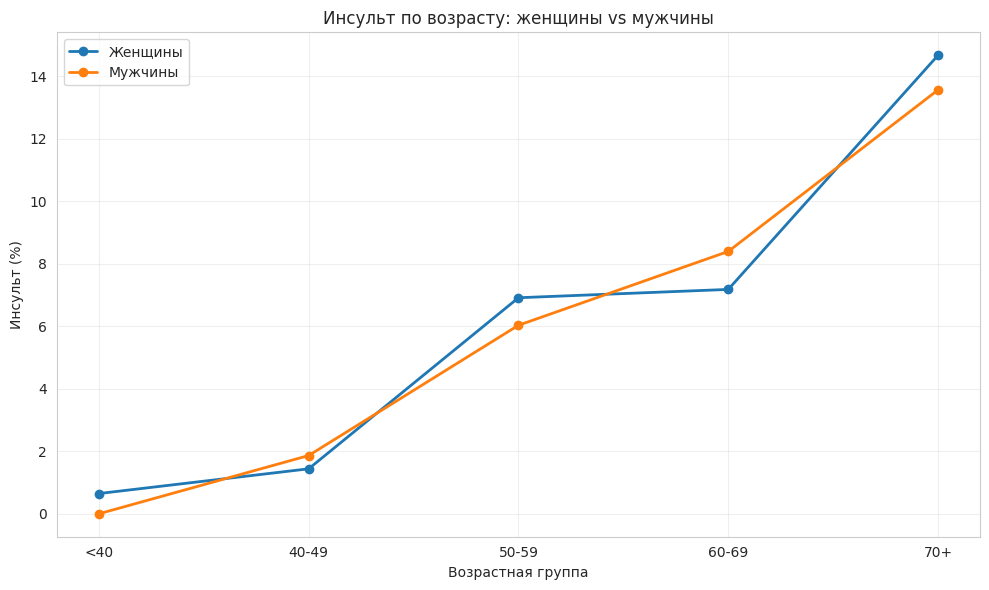


✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/stroke_by_age_gender.png

📝 КЛЮЧЕВЫЕ ВЫВОДЫ

🔹 <40:
   Женщины: 0.6% инсультов (n=772)
   Мужчины: 0.0% инсультов (n=501)

🔹 40-49:
   Женщины: 1.4% инсультов (n=278)
   Мужчины: 1.9% инсультов (n=161)

🔹 50-59:
   Женщины: 6.9% инсультов (n=246)
   Мужчины: 6.0% инсультов (n=199)

🔹 60-69:
   Женщины: 7.2% инсультов (n=209)
   Мужчины: 8.4% инсультов (n=143)

🔹 70+:
   Женщины: 14.7% инсультов (n=225)
   Мужчины: 13.6% инсультов (n=177)


In [35]:
# Анализ: возраст и инсульт в разрезе пола
print("=" * 60)
print("ВОЗРАСТ И ИНСУЛЬТ: СРАВНЕНИЕ МУЖЧИН И ЖЕНЩИН")
print("=" * 60)

# Создаём возрастные группы
df_temp = X_train.copy()
df_temp['stroke'] = y_train
df_temp['age_group'] = pd.cut(df_temp['age'], bins=[0, 40, 50, 60, 70, 100],
                               labels=['<40', '40-49', '50-59', '60-69', '70+'])

# Таблица: пол × возрастная группа × инсульт
print("\n📊 Распределение инсультов по полу и возрасту (%):")
print("-" * 40)

cross = pd.crosstab([df_temp['gender'], df_temp['age_group']],
                     df_temp['stroke'], normalize='index') * 100
print(cross.round(1))

# Абсолютные числа
print("\n📊 Абсолютные числа:")
abs_cross = pd.crosstab([df_temp['gender'], df_temp['age_group']],
                         df_temp['stroke'])
print(abs_cross)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))

# Подготовка данных для графика
plot_data = []
for gender in ['female', 'male']:
    for age_group in ['<40', '40-49', '50-59', '60-69', '70+']:
        subset = df_temp[(df_temp['gender'] == gender) & (df_temp['age_group'] == age_group)]
        if len(subset) > 0:
            stroke_rate = subset['stroke'].mean() * 100
            plot_data.append({
                'gender': 'Женщины' if gender == 'female' else 'Мужчины',
                'age_group': age_group,
                'stroke_rate': stroke_rate
            })

plot_df = pd.DataFrame(plot_data)

# Рисуем линии
for gender in ['Женщины', 'Мужчины']:
    data = plot_df[plot_df['gender'] == gender]
    ax.plot(data['age_group'], data['stroke_rate'], marker='o', linewidth=2, label=gender)

ax.set_xlabel('Возрастная группа')
ax.set_ylabel('Инсульт (%)')
ax.set_title('Инсульт по возрасту: женщины vs мужчины')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/stroke_by_age_gender.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ График сохранён: {PLOTS_PATH}/stroke_by_age_gender.png")

# Ключевые выводы
print("\n" + "=" * 60)
print("📝 КЛЮЧЕВЫЕ ВЫВОДЫ")
print("=" * 60)

for age_group in ['<40', '40-49', '50-59', '60-69', '70+']:
    female_subset = df_temp[(df_temp['gender'] == 'female') & (df_temp['age_group'] == age_group)]
    male_subset = df_temp[(df_temp['gender'] == 'male') & (df_temp['age_group'] == age_group)]

    female_rate = female_subset['stroke'].mean() * 100 if len(female_subset) > 0 else 0
    male_rate = male_subset['stroke'].mean() * 100 if len(male_subset) > 0 else 0

    print(f"\n🔹 {age_group}:")
    print(f"   Женщины: {female_rate:.1f}% инсультов (n={len(female_subset)})")
    print(f"   Мужчины: {male_rate:.1f}% инсультов (n={len(male_subset)})")

In [36]:
# ============================================
# ПРОВЕРКА ГИПОТЕЗЫ: МЕТАБОЛИЧЕСКИЙ СИНДРОМ
# (глюкоза > 126 И bmi > 30)
# ============================================

print("=" * 60)
print("АНАЛИЗ: ВЫСОКИЙ МЕТАБОЛИЧЕСКИЙ РИСК")
print("=" * 60)

# Создаём новый признак
X_train['high_risk_metabolic'] = ((X_train['avg_glucose_level'] > 126) & (X_train['bmi'] > 30)).astype(int)

print("\n📊 Распределение нового признака:")
print(X_train['high_risk_metabolic'].value_counts())
print(f"\n   Доля группы высокого риска: {X_train['high_risk_metabolic'].mean() * 100:.1f}%")

print("\n📊 Распределение инсультов по группам (%):")
print(pd.crosstab(X_train['high_risk_metabolic'], y_train, normalize='index') * 100)

# Повышение риска
risk_0 = (y_train[X_train['high_risk_metabolic'] == 0].mean() * 100) if len(y_train[X_train['high_risk_metabolic'] == 0]) > 0 else 0
risk_1 = (y_train[X_train['high_risk_metabolic'] == 1].mean() * 100) if len(y_train[X_train['high_risk_metabolic'] == 1]) > 0 else 0

print(f"\n📊 Повышение риска:")
print(f"   Низкий риск: {risk_0:.1f}% инсультов")
print(f"   Высокий риск: {risk_1:.1f}% инсультов")
if risk_0 > 0:
    print(f"   → Повышение риска в {risk_1 / risk_0:.1f}x")

# Корреляция с целевой
corr = X_train['high_risk_metabolic'].corr(y_train)
print(f"\n📊 Корреляция с целевой: {corr:.3f}")

# Сравнение с исходными признаками
print("\n📊 Сравнение корреляции с целевой:")
print(f"   avg_glucose_level: {X_train['avg_glucose_level'].corr(y_train):.3f}")
print(f"   bmi: {X_train['bmi'].corr(y_train):.3f}")
print(f"   high_risk_metabolic: {corr:.3f}")

АНАЛИЗ: ВЫСОКИЙ МЕТАБОЛИЧЕСКИЙ РИСК

📊 Распределение нового признака:
high_risk_metabolic
0    2628
1     283
Name: count, dtype: int64

   Доля группы высокого риска: 9.7%

📊 Распределение инсультов по группам (%):
stroke                       0         1
high_risk_metabolic                     
0                    96.270928  3.729072
1                    90.459364  9.540636

📊 Повышение риска:
   Низкий риск: 3.7% инсультов
   Высокий риск: 9.5% инсультов
   → Повышение риска в 2.6x

📊 Корреляция с целевой: 0.085

📊 Сравнение корреляции с целевой:
   avg_glucose_level: 0.112
   bmi: 0.051
   high_risk_metabolic: 0.085


In [37]:
# ============================================
# ПРОВЕРКА ГИПОТЕЗЫ: КАРДИО-РИСК
# (гипертония ИЛИ сердечные заболевания)
# ============================================

print("=" * 60)
print("АНАЛИЗ: КАРДИО-РИСК")
print("=" * 60)

# Создаём новый признак
X_train['cardio_risk'] = ((X_train['hypertension'] == 1) | (X_train['heart_disease'] == 1)).astype(int)

print("\n📊 Распределение нового признака:")
print(X_train['cardio_risk'].value_counts())
print(f"\n   Доля группы риска: {X_train['cardio_risk'].mean() * 100:.1f}%")

print("\n📊 Распределение инсультов по группам (%):")
print(pd.crosstab(X_train['cardio_risk'], y_train, normalize='index') * 100)

# Повышение риска
risk_0 = (y_train[X_train['cardio_risk'] == 0].mean() * 100)
risk_1 = (y_train[X_train['cardio_risk'] == 1].mean() * 100)

print(f"\n📊 Повышение риска:")
print(f"   Нет cardio_risk: {risk_0:.1f}% инсультов")
print(f"   Есть cardio_risk: {risk_1:.1f}% инсультов")
print(f"   → Повышение риска в {risk_1 / risk_0:.1f}x")

# Корреляция с целевой
corr = X_train['cardio_risk'].corr(y_train)
print(f"\n📊 Корреляция с целевой: {corr:.3f}")

# Сравнение с исходными признаками
print("\n📊 Сравнение корреляции с целевой:")
print(f"   hypertension: {X_train['hypertension'].corr(y_train):.3f}")
print(f"   heart_disease: {X_train['heart_disease'].corr(y_train):.3f}")
print(f"   cardio_risk: {corr:.3f}")

АНАЛИЗ: КАРДИО-РИСК

📊 Распределение нового признака:
cardio_risk
0    2526
1     385
Name: count, dtype: int64

   Доля группы риска: 13.2%

📊 Распределение инсультов по группам (%):
stroke               0          1
cardio_risk                      
0            97.030879   2.969121
1            87.012987  12.987013

📊 Повышение риска:
   Нет cardio_risk: 3.0% инсультов
   Есть cardio_risk: 13.0% инсультов
   → Повышение риска в 4.4x

📊 Корреляция с целевой: 0.167

📊 Сравнение корреляции с целевой:
   hypertension: 0.127
   heart_disease: 0.138
   cardio_risk: 0.167


In [38]:
# ============================================
# ПРОВЕРКА: СТАТУС КУРЕНИЯ
# ============================================

print("=" * 60)
print("АНАЛИЗ: СТАТУС КУРЕНИЯ")
print("=" * 60)

print("\n📊 Распределение инсультов по категориям (%):")
print(pd.crosstab(X_train['smoking_status'], y_train, normalize='index') * 100)

# Абсолютные числа
print("\n📊 Абсолютные числа:")
print(pd.crosstab(X_train['smoking_status'], y_train))

# Корреляция (закодируем label)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
smoking_encoded = le.fit_transform(X_train['smoking_status'])
corr = pd.Series(smoking_encoded).corr(y_train)
print(f"\n📊 Корреляция с целевой (Label Encoding): {corr:.3f}")

# Проверка, можно ли объединить unknown с never smoked
unknown_vs_never = pd.crosstab(X_train['smoking_status'], y_train, normalize='index') * 100
if 'unknown' in unknown_vs_never.index and 'never smoked' in unknown_vs_never.index:
    unknown_stroke = unknown_vs_never.loc['unknown', 1] if 1 in unknown_vs_never.columns else 0
    never_stroke = unknown_vs_never.loc['never smoked', 1] if 1 in unknown_vs_never.columns else 0

    print(f"\n📊 Сравнение 'unknown' и 'never smoked':")
    print(f"   unknown: {unknown_stroke:.1f}% инсультов")
    print(f"   never smoked: {never_stroke:.1f}% инсультов")

    if abs(unknown_stroke - never_stroke) < 2:
        print("   → Группы близки по риску. Можно объединить.")
    else:
        print("   → Группы различаются. Оставляем как есть.")

АНАЛИЗ: СТАТУС КУРЕНИЯ

📊 Распределение инсультов по категориям (%):
stroke                   0         1
smoking_status                      
formerly_smoked  94.059406  5.940594
never_smoked     95.258999  4.741001
smokes           95.172414  4.827586
unknown          97.596154  2.403846

📊 Абсолютные числа:
stroke              0   1
smoking_status           
formerly_smoked   475  30
never_smoked     1085  54
smokes            414  21
unknown           812  20

📊 Корреляция с целевой (Label Encoding): -0.059


In [39]:
# ============================================
# ПРОВЕРКА: ТИП РАБОТЫ (work_type)
# ============================================

print("=" * 60)
print("АНАЛИЗ: ТИП РАБОТЫ")
print("=" * 60)

print("\n📊 Распределение инсультов по категориям (%):")
print(pd.crosstab(X_train['work_type'], y_train, normalize='index') * 100)

print("\n📊 Абсолютные числа:")
print(pd.crosstab(X_train['work_type'], y_train))

# Корреляция (закодируем label)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
work_encoded = le.fit_transform(X_train['work_type'])
corr = pd.Series(work_encoded).corr(y_train)
print(f"\n📊 Корреляция с целевой (Label Encoding): {corr:.3f}")

АНАЛИЗ: ТИП РАБОТЫ

📊 Распределение инсультов по категориям (%):
stroke                  0         1
work_type                          
children        99.718310  0.281690
govt_job        96.078431  3.921569
never_worked   100.000000  0.000000
private         95.372596  4.627404
self-employed   93.446089  6.553911

📊 Абсолютные числа:
stroke            0   1
work_type              
children        354   1
govt_job        392  16
never_worked     11   0
private        1587  77
self-employed   442  31

📊 Корреляция с целевой (Label Encoding): 0.077


In [40]:
# ============================================
# ПРОВЕРКА: ТИП ПРОЖИВАНИЯ (residence_type)
# ============================================

print("=" * 60)
print("АНАЛИЗ: ТИП ПРОЖИВАНИЯ")
print("=" * 60)

print("\n📊 Распределение инсультов по категориям (%):")
print(pd.crosstab(X_train['residence_type'], y_train, normalize='index') * 100)

print("\n📊 Абсолютные числа:")
print(pd.crosstab(X_train['residence_type'], y_train))

# Корреляция
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
residence_encoded = le.fit_transform(X_train['residence_type'])
corr = pd.Series(residence_encoded).corr(y_train)
print(f"\n📊 Корреляция с целевой: {corr:.3f}")

АНАЛИЗ: ТИП ПРОЖИВАНИЯ

📊 Распределение инсультов по категориям (%):
stroke                  0         1
residence_type                     
rural           95.847751  4.152249
urban           95.566166  4.433834

📊 Абсолютные числа:
stroke             0   1
residence_type          
rural           1385  60
urban           1401  65

📊 Корреляция с целевой: 0.007


АНАЛИЗ: ТИП РАБОТЫ В РАЗРЕЗЕ ПОЛА

ПОЛ: MALE (n=1181)

📊 Инсульт по типу работы (%):
stroke             0    1
work_type                
children       100.0  0.0
govt_job        96.2  3.8
never_worked   100.0  0.0
private         94.9  5.1
self-employed   93.6  6.4

📊 Абсолютные числа:
stroke           0   1
work_type             
children       179   0
govt_job       154   6
never_worked     5   0
private        632  34
self-employed  160  11

📊 Доля self-employed: 14.5%

ПОЛ: FEMALE (n=1730)

📊 Инсульт по типу работы (%):
stroke             0    1
work_type                
children        99.4  0.6
govt_job        96.0  4.0
never_worked   100.0  0.0
private         95.7  4.3
self-employed   93.4  6.6

📊 Абсолютные числа:
stroke           0   1
work_type             
children       175   1
govt_job       238  10
never_worked     6   0
private        955  43
self-employed  282  20

📊 Доля self-employed: 17.5%

📊 ВИЗУАЛИЗАЦИЯ: риск инсульта по типу работы и полу


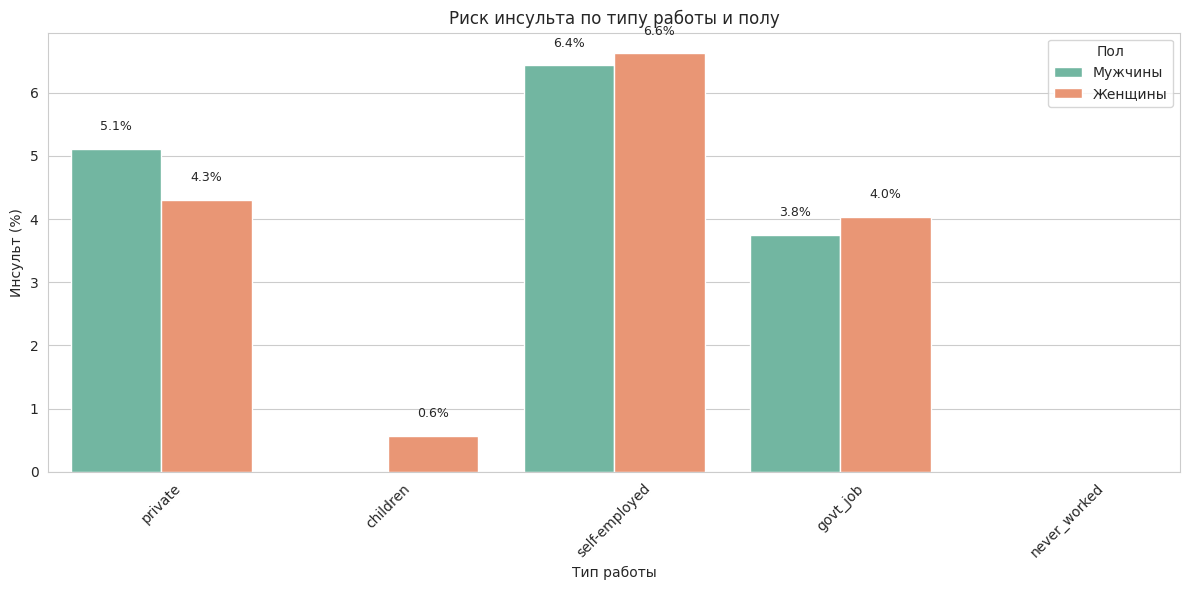


✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/work_type_by_gender.png


In [41]:
# ============================================
# ПРОВЕРКА: ТИП РАБОТЫ × ПОЛ
# ============================================

print("=" * 60)
print("АНАЛИЗ: ТИП РАБОТЫ В РАЗРЕЗЕ ПОЛА")
print("=" * 60)

# Создаём копию с целевой
df_temp = X_train.copy()
df_temp['stroke'] = y_train

# Анализ по полу
for gender in ['male', 'female']:
    subset = df_temp[df_temp['gender'] == gender]
    if len(subset) > 0:
        print(f"\n{'='*40}")
        print(f"ПОЛ: {gender.upper()} (n={len(subset)})")
        print('='*40)

        # Таблица: тип работы × инсульт (%)
        cross = pd.crosstab(subset['work_type'], subset['stroke'], normalize='index') * 100
        print("\n📊 Инсульт по типу работы (%):")
        print(cross.round(1))

        # Абсолютные числа
        print("\n📊 Абсолютные числа:")
        abs_cross = pd.crosstab(subset['work_type'], subset['stroke'])
        print(abs_cross)

        # Доля self-employed среди мужчин и женщин
        self_employed_pct = (subset['work_type'] == 'self-employed').mean() * 100
        print(f"\n📊 Доля self-employed: {self_employed_pct:.1f}%")

# Визуализация
print("\n" + "=" * 60)
print("📊 ВИЗУАЛИЗАЦИЯ: риск инсульта по типу работы и полу")
print("=" * 60)

# Подготовка данных для графика
plot_data = []
for gender in ['male', 'female']:
    for work_type in X_train['work_type'].unique():
        subset = df_temp[(df_temp['gender'] == gender) & (df_temp['work_type'] == work_type)]
        if len(subset) > 0:
            stroke_rate = subset['stroke'].mean() * 100
            plot_data.append({
                'gender': 'Мужчины' if gender == 'male' else 'Женщины',
                'work_type': work_type,
                'stroke_rate': stroke_rate,
                'n': len(subset)
            })

plot_df = pd.DataFrame(plot_data)

# Группированный барплот
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='work_type', y='stroke_rate', hue='gender', palette='Set2')
plt.title('Риск инсульта по типу работы и полу')
plt.xlabel('Тип работы')
plt.ylabel('Инсульт (%)')
plt.legend(title='Пол')
plt.xticks(rotation=45)

# Добавляем значения на столбцы
for i, bar in enumerate(plt.gca().patches):
    height = bar.get_height()
    if height > 0:
        plt.gca().text(bar.get_x() + bar.get_width()/2., height + 0.3,
                       f'{height:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/work_type_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ График сохранён: {PLOTS_PATH}/work_type_by_gender.png")

In [42]:
# ============================================
# ПРОВЕРКА: РАСШИРЕНИЕ senior_stress
# ============================================

print("=" * 60)
print("ПРОВЕРКА: SENIOR_STRESS С РАЗНЫМИ ТИПАМИ РАБОТ")
print("=" * 60)

# Вариант 1: только self-employed + private (текущий)
X_train['senior_stress_1'] = (
    (X_train['age'] > 60) &
    (X_train['work_type'].isin(['self-employed', 'private']))
).astype(int)

# Вариант 2: + govt_job
X_train['senior_stress_2'] = (
    (X_train['age'] > 60) &
    (X_train['work_type'].isin(['self-employed', 'private', 'govt_job']))
).astype(int)

# Вариант 3: все работающие (исключая children и never_worked)
X_train['senior_stress_3'] = (
    (X_train['age'] > 60) &
    (X_train['work_type'].isin(['self-employed', 'private', 'govt_job']))
).astype(int)  # по сути то же, что вариант 2

print("\n📊 Вариант 1 (self-employed + private):")
print(pd.crosstab(X_train['senior_stress_1'], y_train, normalize='index') * 100)
print(f"Корреляция: {X_train['senior_stress_1'].corr(y_train):.3f}")
print(f"Доля группы: {X_train['senior_stress_1'].mean() * 100:.1f}%")

print("\n📊 Вариант 2 (+ govt_job):")
print(pd.crosstab(X_train['senior_stress_2'], y_train, normalize='index') * 100)
print(f"Корреляция: {X_train['senior_stress_2'].corr(y_train):.3f}")
print(f"Доля группы: {X_train['senior_stress_2'].mean() * 100:.1f}%")

# Сравнение
print("\n" + "=" * 60)
print("📊 СРАВНЕНИЕ:")
print("=" * 60)
print(f"   Вариант 1 (self-employed + private): корреляция = {X_train['senior_stress_1'].corr(y_train):.3f}")
print(f"   Вариант 2 (+ govt_job): корреляция = {X_train['senior_stress_2'].corr(y_train):.3f}")

ПРОВЕРКА: SENIOR_STRESS С РАЗНЫМИ ТИПАМИ РАБОТ

📊 Вариант 1 (self-employed + private):
stroke                   0          1
senior_stress_1                      
0                97.708242   2.291758
1                88.629283  11.370717
Корреляция: 0.186
Доля группы: 22.1%

📊 Вариант 2 (+ govt_job):
stroke                   0          1
senior_stress_2                      
0                98.099212   1.900788
1                88.859416  11.140584
Корреляция: 0.200
Доля группы: 25.9%

📊 СРАВНЕНИЕ:
   Вариант 1 (self-employed + private): корреляция = 0.186
   Вариант 2 (+ govt_job): корреляция = 0.200


АНАЛИЗ: СТАТУС КУРЕНИЯ ПО ВОЗРАСТНЫМ ГРУППАМ

ВОЗРАСТ: <40 (n=1273)
stroke               0    1
smoking_status             
formerly_smoked  100.0  0.0
never_smoked      99.8  0.2
smokes            98.2  1.8
unknown           99.8  0.2

Абсолютные числа:
stroke             0  1
smoking_status         
formerly_smoked  108  0
never_smoked     458  1
smokes           166  3
unknown          536  1

ВОЗРАСТ: 40-49 (n=439)
stroke               0    1
smoking_status             
formerly_smoked   97.4  2.6
never_smoked      98.0  2.0
smokes           100.0  0.0
unknown           98.8  1.2

Абсолютные числа:
stroke             0  1
smoking_status         
formerly_smoked   75  2
never_smoked     193  4
smokes            85  0
unknown           79  1

ВОЗРАСТ: 50-59 (n=445)
stroke              0    1
smoking_status            
formerly_smoked  92.2  7.8
never_smoked     95.6  4.4
smokes           90.6  9.4
unknown          93.4  6.6

Абсолютные числа:
stroke             0  1
smoking_status   

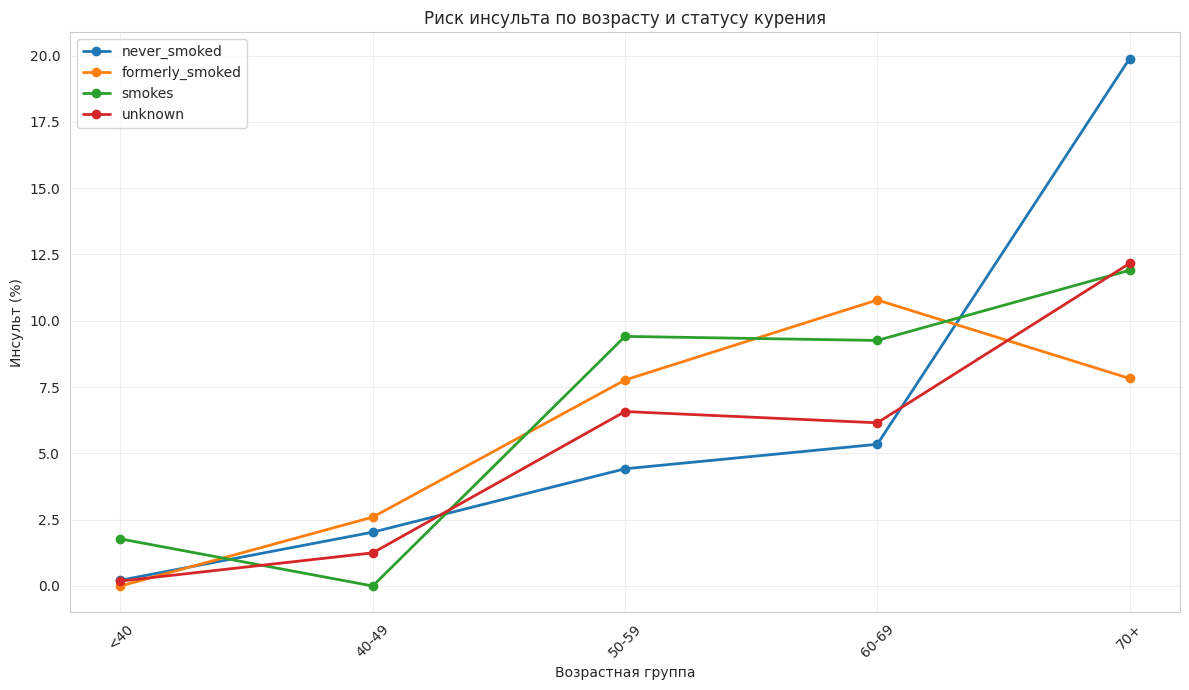


✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/smoking_by_age.png

📝 КЛЮЧЕВЫЕ ВЫВОДЫ

🔹 <40:
   never_smoked: 0.2% (n=459)
   formerly_smoked: 0.0% (n=108)
   smokes: 1.8% (n=169)
   unknown: 0.2% (n=537)

🔹 40-49:
   never_smoked: 2.0% (n=197)
   formerly_smoked: 2.6% (n=77)
   smokes: 0.0% (n=85)
   unknown: 1.2% (n=80)

🔹 50-59:
   never_smoked: 4.4% (n=181)
   formerly_smoked: 7.8% (n=103)
   smokes: 9.4% (n=85)
   unknown: 6.6% (n=76)

🔹 60-69:
   never_smoked: 5.3% (n=131)
   formerly_smoked: 10.8% (n=102)
   smokes: 9.3% (n=54)
   unknown: 6.2% (n=65)

🔹 70+:
   never_smoked: 19.9% (n=171)
   formerly_smoked: 7.8% (n=115)
   smokes: 11.9% (n=42)
   unknown: 12.2% (n=74)


In [43]:
# ============================================
# ПРОВЕРКА: КУРЕНИЕ × ВОЗРАСТНЫЕ ГРУППЫ
# ============================================

print("=" * 60)
print("АНАЛИЗ: СТАТУС КУРЕНИЯ ПО ВОЗРАСТНЫМ ГРУППАМ")
print("=" * 60)

# Создаём возрастные группы
df_temp = X_train.copy()
df_temp['stroke'] = y_train
df_temp['age_group'] = pd.cut(df_temp['age'], bins=[0, 40, 50, 60, 70, 100],
                               labels=['<40', '40-49', '50-59', '60-69', '70+'])

# Анализ по возрастным группам
for age_group in ['<40', '40-49', '50-59', '60-69', '70+']:
    subset = df_temp[df_temp['age_group'] == age_group]
    if len(subset) > 0:
        print(f"\n{'='*40}")
        print(f"ВОЗРАСТ: {age_group} (n={len(subset)})")
        print('='*40)

        # Таблица: статус курения × инсульт
        cross = pd.crosstab(subset['smoking_status'], subset['stroke'], normalize='index') * 100
        print(cross.round(1))

        # Абсолютные числа
        print("\nАбсолютные числа:")
        abs_cross = pd.crosstab(subset['smoking_status'], subset['stroke'])
        print(abs_cross)

# Визуализация
print("\n" + "=" * 60)
print("📊 ВИЗУАЛИЗАЦИЯ: риск инсульта по возрасту и статусу курения")
print("=" * 60)

# Подготовка данных для графика
plot_data = []
for age_group in ['<40', '40-49', '50-59', '60-69', '70+']:
    subset = df_temp[df_temp['age_group'] == age_group]
    for smoking in ['never_smoked', 'formerly_smoked', 'smokes', 'unknown']:
        subsubset = subset[subset['smoking_status'] == smoking]
        if len(subsubset) > 0:
            stroke_rate = subsubset['stroke'].mean() * 100
            plot_data.append({
                'age_group': age_group,
                'smoking_status': smoking,
                'stroke_rate': stroke_rate,
                'n': len(subsubset)
            })

plot_df = pd.DataFrame(plot_data)

# Рисуем линии для каждого статуса курения
plt.figure(figsize=(12, 7))
for smoking in ['never_smoked', 'formerly_smoked', 'smokes', 'unknown']:
    data = plot_df[plot_df['smoking_status'] == smoking]
    if len(data) > 0:
        plt.plot(data['age_group'], data['stroke_rate'], marker='o', linewidth=2, label=smoking)

plt.xlabel('Возрастная группа')
plt.ylabel('Инсульт (%)')
plt.title('Риск инсульта по возрасту и статусу курения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/smoking_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ График сохранён: {PLOTS_PATH}/smoking_by_age.png")

# Выводы
print("\n" + "=" * 60)
print("📝 КЛЮЧЕВЫЕ ВЫВОДЫ")
print("=" * 60)

for age_group in ['<40', '40-49', '50-59', '60-69', '70+']:
    subset = df_temp[df_temp['age_group'] == age_group]
    if len(subset) > 0:
        print(f"\n🔹 {age_group}:")
        for smoking in ['never_smoked', 'formerly_smoked', 'smokes', 'unknown']:
            subsubset = subset[subset['smoking_status'] == smoking]
            if len(subsubset) > 0:
                stroke_pct = subsubset['stroke'].mean() * 100
                n = len(subsubset)
                print(f"   {smoking}: {stroke_pct:.1f}% (n={n})")

In [44]:
# Бинарный признак: работа в частном секторе или своё дело
X_train['is_high_risk_work'] = X_train['work_type'].isin(['self-employed', 'private']).astype(int)

print("\n📊 Распределение нового признака is_high_risk_work:")
print(X_train['is_high_risk_work'].value_counts())
print(f"\n   Доля группы риска: {X_train['is_high_risk_work'].mean() * 100:.1f}%")

print("\n📊 Распределение инсультов по группам (%):")
print(pd.crosstab(X_train['is_high_risk_work'], y_train, normalize='index') * 100)

# Корреляция
corr = X_train['is_high_risk_work'].corr(y_train)
print(f"\n📊 Корреляция с целевой: {corr:.3f}")


📊 Распределение нового признака is_high_risk_work:
is_high_risk_work
1    2137
0     774
Name: count, dtype: int64

   Доля группы риска: 73.4%

📊 Распределение инсультов по группам (%):
stroke                     0         1
is_high_risk_work                     
0                  97.803618  2.196382
1                  94.946186  5.053814

📊 Корреляция с целевой: 0.062


In [45]:
# ============================================
# ПРОВЕРКА: КОМБИНАЦИИ work_type С ДРУГИМИ ПРИЗНАКАМИ
# ============================================

print("=" * 60)
print("АНАЛИЗ КОМБИНАЦИЙ work_type")
print("=" * 60)

# 1. Стресс + кардио
X_train['stress_cardio'] = (
    (X_train['work_type'].isin(['self-employed', 'private'])) &
    (X_train['cardio_risk'] == 1)
).astype(int)

print("\n📊 stress_cardio:")
print(pd.crosstab(X_train['stress_cardio'], y_train, normalize='index') * 100)
print(f"Корреляция: {X_train['stress_cardio'].corr(y_train):.3f}")

# 2. Стресс + пожилой возраст
X_train['senior_stress'] = (
    (X_train['age'] > 60) &
    (X_train['work_type'].isin(['self-employed', 'private']))
).astype(int)

print("\n📊 senior_stress:")
print(pd.crosstab(X_train['senior_stress'], y_train, normalize='index') * 100)
print(f"Корреляция: {X_train['senior_stress'].corr(y_train):.3f}")

# 3. Нет поддержки + стресс
X_train['no_support_stress'] = (
    (X_train['marriage_risk'] == 'senior_unmarried') &
    (X_train['work_type'].isin(['self-employed', 'private']))
).astype(int)

print("\n📊 no_support_stress:")
print(pd.crosstab(X_train['no_support_stress'], y_train, normalize='index') * 100)
print(f"Корреляция: {X_train['no_support_stress'].corr(y_train):.3f}")

# 4. Сравнение с исходным work_type (one-hot)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
work_encoded = le.fit_transform(X_train['work_type'])
print(f"\n📊 Оригинальный work_type (Label Encoding): {pd.Series(work_encoded).corr(y_train):.3f}")


АНАЛИЗ КОМБИНАЦИЙ work_type

📊 stress_cardio:
stroke                 0          1
stress_cardio                      
0              96.866538   3.133462
1              86.503067  13.496933
Корреляция: 0.161

📊 senior_stress:
stroke                 0          1
senior_stress                      
0              97.708242   2.291758
1              88.629283  11.370717
Корреляция: 0.186

📊 no_support_stress:
stroke                     0          1
no_support_stress                      
0                  95.983234   4.016766
1                  79.166667  20.833333
Корреляция: 0.106

📊 Оригинальный work_type (Label Encoding): 0.077


# Удаление признаков после создания

In [46]:
# 5.2. УДАЛЕНИЕ ПРИЗНАКОВ ПОСЛЕ СОЗДАНИЯ

if 'X_train' not in locals():
    print("\n⚠ X_train не найден. Сначала выполните блок 5.1.")
else:
    if columns_to_drop_fe:
        existing_cols = [col for col in columns_to_drop_fe if col in X_train.columns]
        if existing_cols:
            X_train = X_train.drop(columns=existing_cols)
            print(f"\n🗑 Удалены признаки: {existing_cols}")
        else:
            print("\n⚠ Указанные признаки для удаления не найдены")

    print("\n" + "-" * 40)
    print(f"📊 Новая форма X_train: {X_train.shape[0]} строк × {X_train.shape[1]} колонок")

    # Сохраняем checkpoint
    feature_eng_path = f'{CHECKPOINT_PATH}/05_feature_engineering.csv'
    X_train.to_csv(feature_eng_path, index=False)
    print(f"\n✓ Промежуточное сохранение: {feature_eng_path}")


🗑 Удалены признаки: ['ever_married', 'hypertension', 'heart_disease', 'work_type', 'gender', 'residence_type', 'smoking_status', 'senior_stress', 'is_high_risk_work', 'high_risk_metabolic', 'senior_stress_1', 'senior_stress_2', 'senior_stress_3', 'stress_cardio', 'no_support_stress']

----------------------------------------
📊 Новая форма X_train: 2911 строк × 6 колонок

✓ Промежуточное сохранение: /content/drive/MyDrive/ml_learning/datasets/stroke/checkpoints/05_feature_engineering.csv


In [47]:
# БЛОК 5.3. СВОДНЫЙ АНАЛИЗ НОВЫХ ПРИЗНАКОВ

print("\n" + "=" * 60)
print("5.3. СВОДНЫЙ АНАЛИЗ НОВЫХ ПРИЗНАКОВ")  # ← ИСПРАВЛЕНО (было 5.2)
print("=" * 60)

# Используем список из настроек
new_features = NEW_FEATURES_LIST

print("\n📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА НОВЫХ ПРИЗНАКОВ")
print("-" * 60)

# Собираем данные в таблицу
comparison_data = []

for col in new_features:
    if col not in X_train.columns:
        continue

    # Тип признака
    if X_train[col].dtype in ['int64', 'float64']:
        col_type = 'Числовой'
        unique_count = X_train[col].nunique()
        # Для бинарных показываем долю 1
        if unique_count <= 2:
            risk_pct = X_train[col].mean() * 100
            stats = f"доля 1: {risk_pct:.1f}%"
        else:
            stats = f"диапазон: {X_train[col].min():.2f}–{X_train[col].max():.2f}"
    else:
        col_type = 'Категориальный'
        unique_count = X_train[col].nunique()
        stats = f"категорий: {unique_count}"

    # Корреляция с целевой
    if X_train[col].dtype in ['int64', 'float64']:
        corr = X_train[col].corr(y_train)
    else:
        # Для категориальных считаем через LabelEncoder временно
        le = LabelEncoder()  # импорт уже есть в 1.1
        encoded = le.fit_transform(X_train[col])
        corr = pd.Series(encoded).corr(y_train)

    comparison_data.append({
        'Признак': col,
        'Тип': col_type,
        'Уникальных': unique_count,
        'Статистика': stats,
        f'Корреляция с {TARGET_COLUMN}': f"{corr:.3f}"  # ← ИСПРАВЛЕНО
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

print("\n" + "=" * 60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ПО КАЖДОМУ ПРИЗНАКУ")
print("=" * 60)

for col in new_features:
    if col not in X_train.columns:
        continue

    print(f"\n{'='*40}")
    print(f"📌 {col}")
    print('='*40)

    if X_train[col].dtype in ['int64', 'float64']:
        # Числовой признак
        print(f"   Тип: числовой")
        print(f"   Уникальных значений: {X_train[col].nunique()}")
        print(f"   Среднее: {X_train[col].mean():.3f}")
        print(f"   Медиана: {X_train[col].median():.3f}")

        # Связь с целевой
        if X_train[col].nunique() <= 2:
            # Бинарный
            print(f"\n   📊 Связь с целевой переменной:")  # ← ИСПРАВЛЕНО
            cross = pd.crosstab(X_train[col], y_train, normalize='index') * 100
            for idx in cross.index:
                val_name = "Есть" if idx == 1 else "Нет"
                target_pct = cross.loc[idx, 1] if 1 in cross.columns else 0
                print(f"      {val_name} ({idx}): {target_pct:.1f}% целевой переменной")  # ← ИСПРАВЛЕНО
        else:
            # Непрерывный
            corr = X_train[col].corr(y_train)
            print(f"\n   Корреляция с {TARGET_COLUMN}: {corr:.3f}")  # ← ИСПРАВЛЕНО

    else:
        # Категориальный признак
        print(f"   Тип: категориальный")
        print(f"   Уникальных значений: {X_train[col].nunique()}")
        print(f"\n   📊 Связь с целевой переменной (%):")  # ← ИСПРАВЛЕНО

        # Таблица с целевой
        cross = pd.crosstab(X_train[col], y_train, normalize='index') * 100
        print(cross.round(1))

        # Абсолютные числа
        print(f"\n   Абсолютные числа:")
        cross_abs = pd.crosstab(X_train[col], y_train)
        print(cross_abs)


5.3. СВОДНЫЙ АНАЛИЗ НОВЫХ ПРИЗНАКОВ

📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА НОВЫХ ПРИЗНАКОВ
------------------------------------------------------------


,Признак,Тип,Уникальных,Статистика,Корреляция с stroke
0,cardio_risk,Числовой,2,доля 1: 13.2%,0.167
1,senior_work,Числовой,2,доля 1: 25.9%,0.200
2,marriage_risk,Категориальный,3,категорий: 3,-0.186



ДЕТАЛЬНЫЙ АНАЛИЗ ПО КАЖДОМУ ПРИЗНАКУ

📌 cardio_risk
   Тип: числовой
   Уникальных значений: 2
   Среднее: 0.132
   Медиана: 0.000

   📊 Связь с целевой переменной:
      Нет (0): 3.0% целевой переменной
      Есть (1): 13.0% целевой переменной

📌 senior_work
   Тип: числовой
   Уникальных значений: 2
   Среднее: 0.259
   Медиана: 0.000

   📊 Связь с целевой переменной:
      Нет (0): 1.9% целевой переменной
      Есть (1): 11.1% целевой переменной

📌 marriage_risk
   Тип: категориальный
   Уникальных значений: 3

   📊 Связь с целевой переменной (%):
stroke               0     1
marriage_risk               
senior_married    89.7  10.3
senior_unmarried  78.9  21.1
young             98.1   1.9

   Абсолютные числа:
stroke               0   1
marriage_risk             
senior_married     625  72
senior_unmarried    45  12
young             2116  41


# БЛОК 6. category info

In [48]:
# БЛОК 6.1. ОБЩАЯ ИНФОРМАЦИЯ О КАТЕГОРИАЛЬНЫХ КОЛОНКАХ

print("\n" + "=" * 50)
print("6.1. АНАЛИЗ КАТЕГОРИАЛЬНЫХ КОЛОНОК")
print("=" * 50)

# Определяем категориальные колонки
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    print(f"\n📋 Категориальные колонки: {list(categorical_cols)}")

    categorical_info = []

    for col in categorical_cols:
        unique_count = X_train[col].nunique()
        top_values = X_train[col].value_counts().head(5)
        top_percent = (top_values / len(X_train) * 100).round(1)

        # Проверяем редкие категории (менее 1% данных)
        value_counts = X_train[col].value_counts()
        rare_threshold = len(X_train) * 0.01
        rare_categories = value_counts[value_counts < rare_threshold]

        categorical_info.append({
            'Колонка': col,
            'Уникальных': unique_count,
            'Топ-1': f"{top_values.index[0]} ({top_values.iloc[0]})" if len(top_values) > 0 else '-',
            'Топ-1 %': f"{top_percent.iloc[0]:.1f}%" if len(top_percent) > 0 else '-',
            'Топ-2': f"{top_values.index[1]} ({top_values.iloc[1]})" if len(top_values) > 1 else '-',
            'Редких категорий': len(rare_categories)
        })

        print(f"\n📌 {col}:")
        print(f"   Уникальных значений: {unique_count}")
        print(f"   Топ-5 значений:")
        for val, cnt in top_values.items():
            pct = cnt / len(X_train) * 100
            print(f"     {val}: {cnt} ({pct:.1f}%)")

        if len(rare_categories) > 0:
            print(f"   ⚠ Редких категорий (<1%): {len(rare_categories)}")
            print(f"     Примеры: {list(rare_categories.head(3).index)}")

    # Сводная таблица
    print("\n" + "-" * 50)
    print("📊 СВОДНАЯ ТАБЛИЦА КАТЕГОРИАЛЬНЫХ КОЛОНОК:")
    print("-" * 50)
    categorical_df = pd.DataFrame(categorical_info)
    display(categorical_df)

else:
    print("⚠ Нет категориальных колонок для анализа")


6.1. АНАЛИЗ КАТЕГОРИАЛЬНЫХ КОЛОНОК

📋 Категориальные колонки: ['marriage_risk']

📌 marriage_risk:
   Уникальных значений: 3
   Топ-5 значений:
     young: 2157 (74.1%)
     senior_married: 697 (23.9%)
     senior_unmarried: 57 (2.0%)

--------------------------------------------------
📊 СВОДНАЯ ТАБЛИЦА КАТЕГОРИАЛЬНЫХ КОЛОНОК:
--------------------------------------------------


,Колонка,Уникальных,Топ-1,Топ-1 %,Топ-2,Редких категорий
0,marriage_risk,3,young (2157),74.1%,senior_married (697),0


# Viz categorical_cols


6.2. ВИЗУАЛИЗАЦИЯ КАТЕГОРИАЛЬНЫХ КОЛОНОК


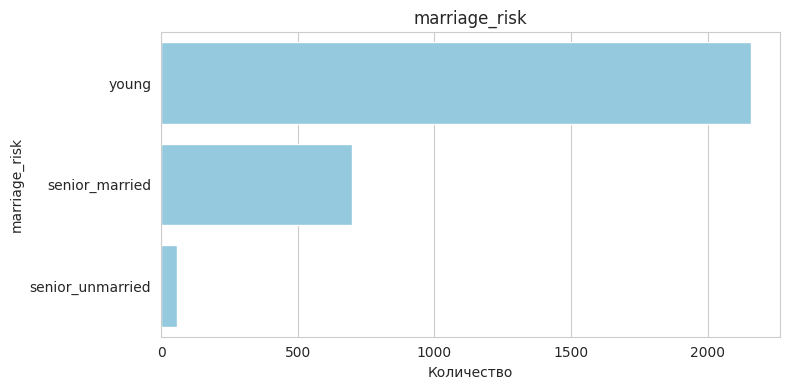

  ✓ marriage_risk

✅ Графики сохранены в: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots


In [49]:
# БЛОК 6.2. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ КАТЕГОРИЙ

print("\n" + "=" * 50)
print("6.2. ВИЗУАЛИЗАЦИЯ КАТЕГОРИАЛЬНЫХ КОЛОНОК")
print("=" * 50)

# Определяем категориальные колонки независимо
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    for col in categorical_cols:
        try:
            # Размер графика (увеличен для лучшей читаемости)
            plt.figure(figsize=(8, 4))  # было (6, 3) — мелко

            value_counts = X_train[col].value_counts()

            # Если категорий слишком много, показываем топ
            if len(value_counts) > 20:
                plot_data = value_counts.head(15)
                title = f'{col} (топ-15 из {len(value_counts)})'
            else:
                plot_data = value_counts
                title = col

            if len(plot_data) > 0:
                sns.barplot(x=plot_data.values, y=plot_data.index, color='skyblue')
                plt.title(title)
                plt.xlabel('Количество')
                plt.tight_layout()
                plt.savefig(f'{PLOTS_PATH}/categorical_{col}.png', dpi=150, bbox_inches='tight')
                plt.show()
                print(f"  ✓ {col}")

            plt.close()

        except Exception as e:
            print(f"  ⚠ Ошибка для {col}: {e}")

    print(f"\n✅ Графики сохранены в: {PLOTS_PATH}")
else:
    print("⚠ Нет категориальных колонок для визуализации")

# БЛОК 7. Корреляция

In [50]:
# БЛОК 7.1. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

print("\n" + "=" * 50)
print("7.1. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("=" * 50)

# Приводим Int64 к int64 (для совместимости с one-hot и RF)
for col in X_train.select_dtypes(include=['Int64']).columns:
    X_train[col] = X_train[col].astype('int64')
    print(f"   ✓ {col}: Int64 → int64")

# Создаём копию исходных данных
X_train_encoded = X_train.copy()
encoders = {}

if encoding_config:
    print("\n📊 Применяем кодирование:")
    for col, (method, params) in encoding_config.items():
        if col not in X_train.columns:
            print(f"   ⚠ {col} не найдена, пропускаем")
            continue

        if method == 'one_hot':
            # One-Hot Encoding
            dummies = pd.get_dummies(X_train[col], prefix=col, drop_first=False)
            X_train_encoded = pd.concat([X_train_encoded, dummies], axis=1)
            X_train_encoded = X_train_encoded.drop(columns=[col])
            encoders[col] = {'method': 'one_hot', 'columns': list(dummies.columns)}
            print(f"   ✓ {col}: ONE_HOT → создано {len(dummies.columns)} колонок")

        elif method == 'label':
            le = LabelEncoder()
            X_train_encoded[col] = le.fit_transform(X_train[col].astype(str))
            encoders[col] = {'method': 'label', 'encoder': le}
            print(f"   ✓ {col}: LABEL")

        else:
            print(f"   ⚠ {col}: неизвестный метод '{method}'")
else:
    print("\n⚠ encoding_config пуст, кодирование не применяется")

print(f"\n✅ Кодирование завершено")
print(f"   Форма X_train_encoded: {X_train_encoded.shape}")

print("=== ПОСЛЕ КОДИРОВАНИЯ ===")
print("   Новые колонки (one-hot):", [c for c in X_train_encoded.columns if c not in X_train.columns])


7.1. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
   ✓ cardio_risk: Int64 → int64
   ✓ senior_work: Int64 → int64

📊 Применяем кодирование:
   ✓ marriage_risk: ONE_HOT → создано 3 колонок

✅ Кодирование завершено
   Форма X_train_encoded: (2911, 8)
=== ПОСЛЕ КОДИРОВАНИЯ ===
   Новые колонки (one-hot): ['marriage_risk_senior_married', 'marriage_risk_senior_unmarried', 'marriage_risk_young']



7.2. КОРРЕЛЯЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ

📊 Матрица корреляции:


,age,avg_glucose_level,bmi,cardio_risk,senior_work
age,1.00,0.22,0.32,0.36,0.74
avg_glucose_level,0.22,1.00,0.19,0.24,0.19
bmi,0.32,0.19,1.00,0.15,0.07
cardio_risk,0.36,0.24,0.15,1.00,0.34
senior_work,0.74,0.19,0.07,0.34,1.00


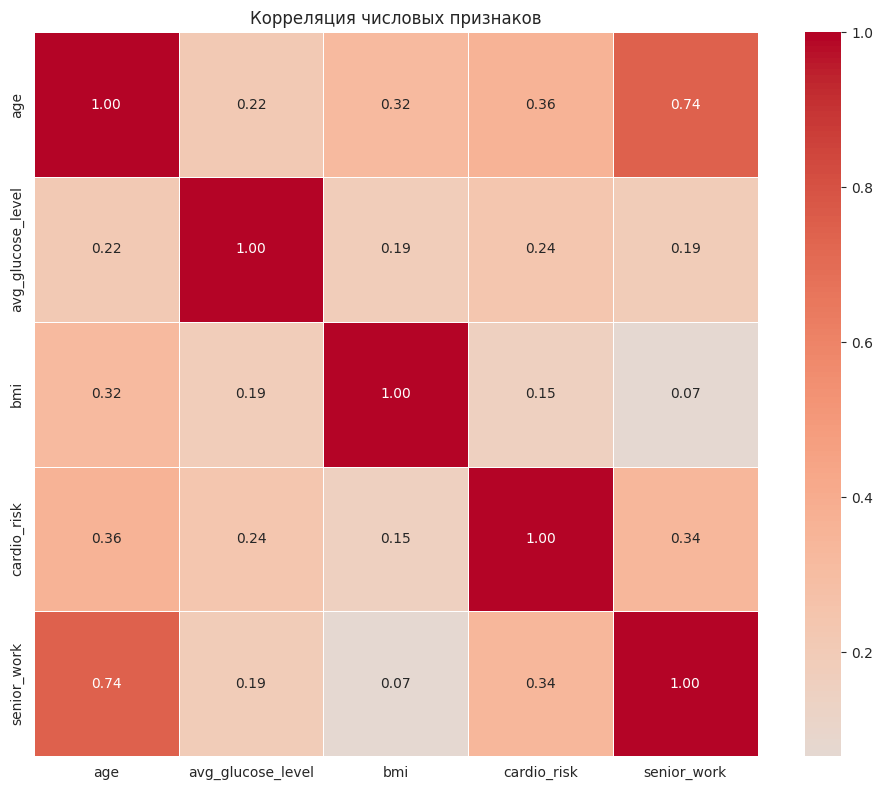


✓ Тепловая карта сохранена: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/correlation_heatmap.png

📌 Сильно коррелирующие пары (|r| > 0.7):


,Признак 1,Признак 2,Корреляция
0,age,senior_work,0.741252



💡 Если два признака сильно коррелируют (>0.7), можно удалить один


In [51]:
# БЛОК 7.2. КОРРЕЛЯЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ

print("\n" + "=" * 50)
print("7.2. КОРРЕЛЯЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("=" * 50)

# Определяем числовые колонки
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

if len(numeric_cols) > 1:
    # Вычисляем корреляцию
    corr_matrix = X_train[numeric_cols].corr()

    print("\n📊 Матрица корреляции:")
    display(corr_matrix.round(2))

    # Визуализация тепловой карты
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', square=True, linewidths=0.5)
    plt.title('Корреляция числовых признаков')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_PATH}/correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Тепловая карта сохранена: {PLOTS_PATH}/correlation_heatmap.png")

    # Находим сильно коррелирующие пары
    print("\n📌 Сильно коррелирующие пары (|r| > 0.7):")
    strong_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:
                strong_corr.append({
                    'Признак 1': corr_matrix.columns[i],
                    'Признак 2': corr_matrix.columns[j],
                    'Корреляция': corr_val
                })

    if strong_corr:
        strong_df = pd.DataFrame(strong_corr).sort_values('Корреляция', ascending=False)
        display(strong_df)
        print("\n💡 Если два признака сильно коррелируют (>0.7), можно удалить один")
    else:
        print("   Нет пар с корреляцией >0.7")

else:
    print("⚠ Недостаточно числовых колонок для корреляционного анализа")


7.3. КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

 Анализ связи признаков с целевой переменной (классификация)
   Для категориальной цели используем ANOVA F-value

ANOVA анализ для числовых признаков:


,Признак,F-value,p-value
0,age,151.8147,0.0000
4,senior_work,120.8006,0.0000
3,cardio_risk,83.8773,0.0000
1,avg_glucose_level,36.8222,0.0000
2,bmi,7.4739,0.0063


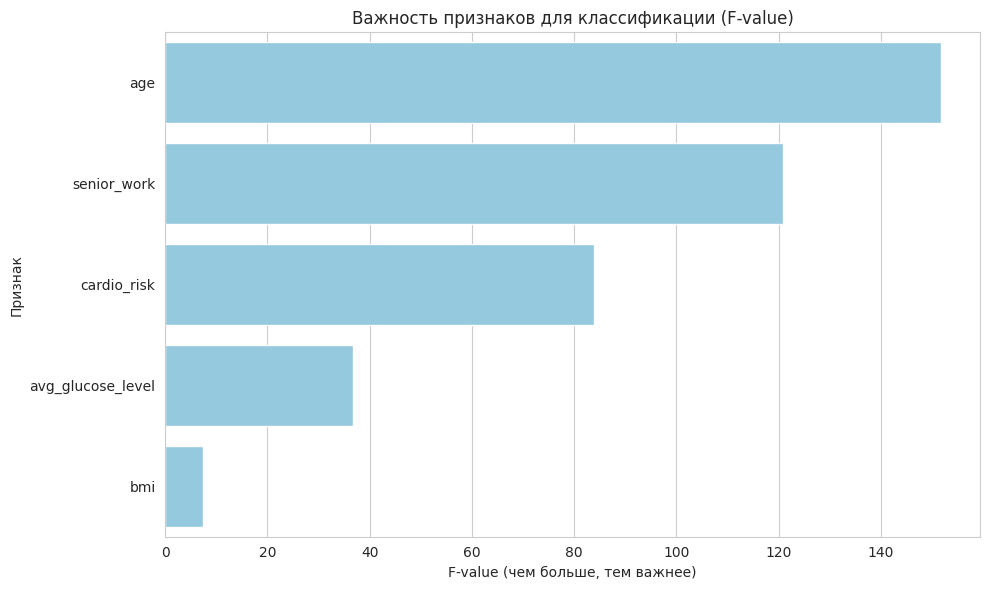


💡 Интерпретация:
   - Большой F-value → признак сильно связан с целевой
   - p-value < 0.05 → связь статистически значима


In [52]:
# БЛОК 7.3. КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

print("\n" + "=" * 50)
print("7.3. КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("=" * 50)

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Проверяем тип задачи
if task_type == 'regression':
    # Для регрессии используем корреляцию Пирсона
    if len(numeric_cols) > 0:
        # Вычисляем корреляцию с целевой
        target_corr = {}
        for col in numeric_cols:
            corr_val = X_train[col].corr(y_train)
            target_corr[col] = corr_val

        # Сортируем по абсолютной корреляции
        target_corr_df = pd.DataFrame({
            'Признак': list(target_corr.keys()),
            'Корреляция': list(target_corr.values())
        }).sort_values('Корреляция', ascending=False)

        print("\n📊 Корреляция признаков с целевой переменной:")
        display(target_corr_df)

        # Визуализация
        plt.figure(figsize=(10, 6))
        colors = ['red' if x < 0 else 'green' for x in target_corr_df['Корреляция']]
        sns.barplot(x='Корреляция', y='Признак', data=target_corr_df, palette=colors)
        plt.title('Корреляция признаков с целевой переменной')
        plt.xlabel('Коэффициент корреляции')
        plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        plt.tight_layout()
        plt.savefig(f'{PLOTS_PATH}/target_correlation.png', dpi=150, bbox_inches='tight')
        plt.show()

        print("\n💡 Интерпретация:")
        print("   - Положительная корреляция → рост признака ведёт к росту целевой")
        print("   - Отрицательная корреляция → рост признака ведёт к снижению целевой")
        print("   - |r| < 0.1 → слабая связь, можно рассмотреть удаление")

        # Находим слабые признаки
        weak_features = target_corr_df[abs(target_corr_df['Корреляция']) < 0.1]
        if len(weak_features) > 0:
            print(f"\n⚠ Слабые признаки (|r| < 0.1):")
            for _, row in weak_features.iterrows():
                print(f"   - {row['Признак']}: {row['Корреляция']:.3f}")

    else:
        print("⚠ Нет числовых колонок для корреляционного анализа")

elif task_type == 'classification':
    # Для классификации используем ANOVA или корреляцию с закодированной целью
    print("\n Анализ связи признаков с целевой переменной (классификация)")
    print("   Для категориальной цели используем ANOVA F-value")

    if len(numeric_cols) > 0:
        # Вычисляем F-value для числовых признаков
        f_values, p_values = f_classif(X_train[numeric_cols], y_train)

        f_corr_df = pd.DataFrame({
            'Признак': numeric_cols,
            'F-value': f_values,
            'p-value': p_values
        }).sort_values('F-value', ascending=False)

        print("\nANOVA анализ для числовых признаков:")
        display(f_corr_df.round(4))

        # Визуализация
        plt.figure(figsize=(10, 6))
        sns.barplot(x='F-value', y='Признак', data=f_corr_df, color='skyblue')
        plt.title('Важность признаков для классификации (F-value)')
        plt.xlabel('F-value (чем больше, тем важнее)')
        plt.tight_layout()
        plt.savefig(f'{PLOTS_PATH}/target_fvalue.png', dpi=150, bbox_inches='tight')
        plt.show()

        print("\n💡 Интерпретация:")
        print("   - Большой F-value → признак сильно связан с целевой")
        print("   - p-value < 0.05 → связь статистически значима")

        # Находим незначимые признаки
        insignificant = f_corr_df[f_corr_df['p-value'] >= 0.05]
        if len(insignificant) > 0:
            print(f"\n⚠ Незначимые признаки (p-value >= 0.05):")
            for _, row in insignificant.iterrows():
                print(f"   - {row['Признак']}: p-value = {row['p-value']:.4f}")

    else:
        print("⚠ Нет числовых колонок для анализа")

In [53]:
# БЛОК 7.4. УДАЛЕНИЕ ПРИЗНАКОВ ПОСЛЕ КОРРЕЛЯЦИОННОГО АНАЛИЗА

print("\n" + "=" * 50)
print("7.4. УДАЛЕНИЕ ПРИЗНАКОВ (корреляционный отбор)")
print("=" * 50)

if features_to_drop:
    print(f"\n📋 Признаки для удаления: {features_to_drop}")

    # Удаляем из X_train
    if 'X_train' in locals():
        existing_cols = [col for col in features_to_drop if col in X_train.columns]
        if existing_cols:
            X_train = X_train.drop(columns=existing_cols)
            print(f"   ✓ X_train: удалены {existing_cols}")

    # Удаляем из X_train_encoded (если существует)
    if 'X_train_encoded' in locals():
        existing_cols = [col for col in features_to_drop if col in X_train_encoded.columns]
        if existing_cols:
            X_train_encoded = X_train_encoded.drop(columns=existing_cols)
            print(f"   ✓ X_train_encoded: удалены {existing_cols}")

    # Удаляем из X_val, X_test (если загружены)
    for var_name in ['X_val', 'X_test']:
        if var_name in locals():
            df = locals()[var_name]
            existing_cols = [col for col in features_to_drop if col in df.columns]
            if existing_cols:
                df = df.drop(columns=existing_cols)
                # Обновляем переменную
                if var_name == 'X_val':
                    X_val = df
                elif var_name == 'X_test':
                    X_test = df
                print(f"   ✓ {var_name}: удалены {existing_cols}")

    if not any([col in X_train.columns for col in features_to_drop]):
        print("   ✅ Все указанные признаки удалены")
    else:
        remaining = [col for col in features_to_drop if col in X_train.columns]
        print(f"   ⚠ Внимание: некоторые признаки не найдены: {remaining}")

else:
    print("✅ Нет признаков для удаления (features_to_drop пуст)")

# Сохраняем checkpoint
if 'X_train' in locals():
    cleaned_path = f'{CHECKPOINT_PATH}/06_features_selected.csv'
    X_train.to_csv(cleaned_path, index=False)
    print(f"\n✓ Сохранено: {cleaned_path}")


7.4. УДАЛЕНИЕ ПРИЗНАКОВ (корреляционный отбор)

📋 Признаки для удаления: ['senior_work']
   ✓ X_train: удалены ['senior_work']
   ✓ X_train_encoded: удалены ['senior_work']
   ✅ Все указанные признаки удалены

✓ Сохранено: /content/drive/MyDrive/ml_learning/datasets/stroke/checkpoints/06_features_selected.csv


# БЛОК 8. Random Forest

In [54]:
# БЛОК 8.1. ПОДГОТОВКА ДАННЫХ ДЛЯ RANDOM FOREST

print("\n" + "=" * 50)
print("8.1. ПОДГОТОВКА ДАННЫХ ДЛЯ RANDOM FOREST")
print("=" * 50)

# Проверяем, существует ли X_train_encoded
if 'X_train_encoded' not in locals():
    print("\n⚠ X_train_encoded не найден. Сначала выполните блок 7.1.")
else:
    # Все возможные числовые типы (включая nullable)
    numeric_types = ['int16', 'int32', 'int64', 'Int64',       # целые
                     'float16', 'float32', 'float64',          # дробные
                     'uint8', 'uint16', 'uint32', 'uint64',    # беззнаковые
                     'bool']                                   # логические

    numeric_cols_for_rf = X_train_encoded.select_dtypes(include=numeric_types).columns
    X_rf = X_train_encoded[numeric_cols_for_rf]

    print(f"\n✓ Подготовлено {X_rf.shape[1]} признаков для RF")
    print(f"   Колонки: {list(X_rf.columns)}")


8.1. ПОДГОТОВКА ДАННЫХ ДЛЯ RANDOM FOREST

✓ Подготовлено 7 признаков для RF
   Колонки: ['age', 'avg_glucose_level', 'bmi', 'cardio_risk', 'marriage_risk_senior_married', 'marriage_risk_senior_unmarried', 'marriage_risk_young']



8.2. ОЦЕНКА ВАЖНОСТИ ПРИЗНАКОВ (RANDOM FOREST)

📊 Используем RandomForestClassifier (классификация)
   ✓ class_weight='balanced' (учёт дисбаланса классов)
   Обучаем модель...
   ✓ Модель обучена

📊 Важность признаков (топ-10):


,Признак,Важность
0,age,0.3540
1,avg_glucose_level,0.2662
2,bmi,0.2440
6,marriage_risk_young,0.0601
4,marriage_risk_senior_married,0.0351
3,cardio_risk,0.0323
5,marriage_risk_senior_unmarried,0.0084


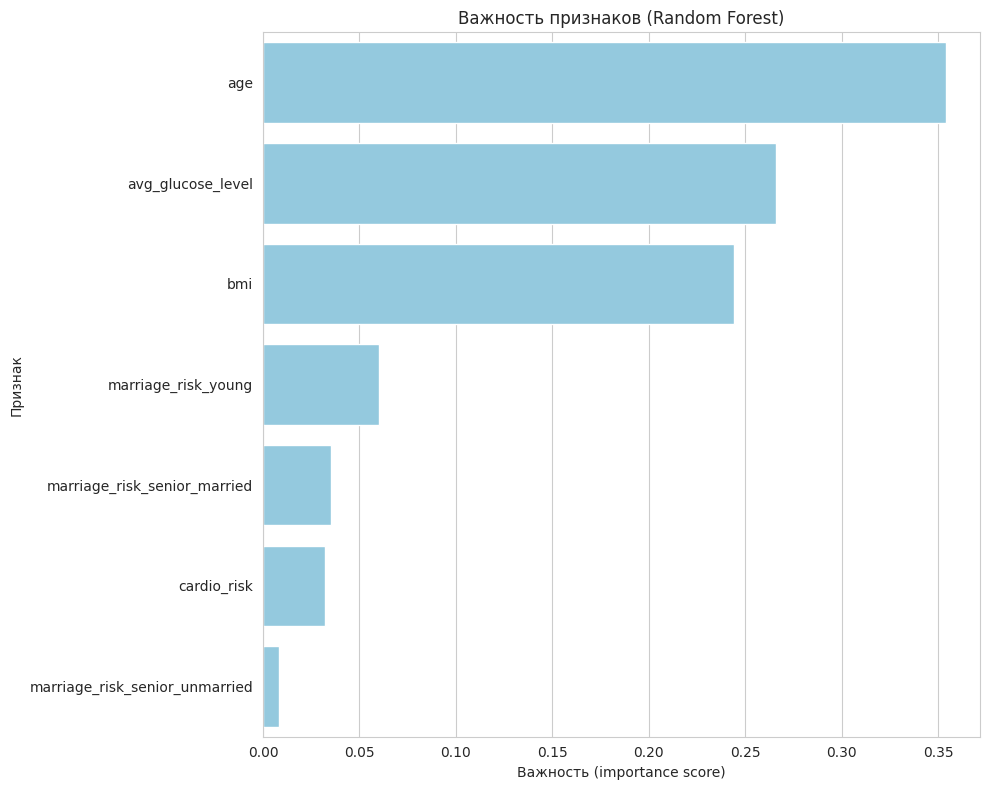


✓ График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/reports/plots/feature_importance_rf.png

⚠ Признаки с низкой важностью (< 0.01): ['marriage_risk_senior_unmarried']
   Рекомендуется рассмотреть их удаление в features_to_drop_rf (блок 1.3)


In [55]:
# БЛОК 8.2. ОБУЧЕНИЕ RANDOM FOREST ДЛЯ ОЦЕНКИ ВАЖНОСТИ ПРИЗНАКОВ
# Обучаем Random Forest на тренировочных данных

print("\n" + "=" * 50)
print("8.2. ОЦЕНКА ВАЖНОСТИ ПРИЗНАКОВ (RANDOM FOREST)")
print("=" * 50)

# Проверяем, существует ли X_rf
if 'X_rf' not in locals():
    print("\n⚠ X_rf не найден. Сначала выполните блок 8.1.")
else:
    # Выбираем модель в зависимости от типа задачи
    if task_type == 'classification':
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                     class_weight=RF_CLASS_WEIGHT)
        print("\n📊 Используем RandomForestClassifier (классификация)")

        if RF_CLASS_WEIGHT == 'balanced':
            print("   ✓ class_weight='balanced' (учёт дисбаланса классов)")
        elif RF_CLASS_WEIGHT is None:
            print("   ⚠ class_weight=None (дисбаланс НЕ учитывается)")
        elif RF_CLASS_WEIGHT == 'balanced_subsample':
            print("   ✓ class_weight='balanced_subsample' (учёт дисбаланса в бутстрэпе)")
        else:
            print(f"   ✓ class_weight={RF_CLASS_WEIGHT}")
    else:
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        print("\n📊 Используем RandomForestRegressor (регрессия)")
        print("   (class_weight не применяется для регрессии)")

    # Обучаем модель
    print("   Обучаем модель...")
    rf.fit(X_rf, y_train)
    print("   ✓ Модель обучена")

    # Получаем важность признаков
    feature_importance = pd.DataFrame({
        'Признак': X_rf.columns,
        'Важность': rf.feature_importances_
    }).sort_values('Важность', ascending=False)

    print("\n📊 Важность признаков (топ-10):")
    display(feature_importance.head(10).round(4))

    # Визуализация
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Важность', y='Признак', data=feature_importance.head(15), color='skyblue')
    plt.title('Важность признаков (Random Forest)')
    plt.xlabel('Важность (importance score)')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_PATH}/feature_importance_rf.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ График сохранён: {PLOTS_PATH}/feature_importance_rf.png")

    # Рекомендации по удалению признаков с низкой важностью
    threshold = 0.01
    low_importance = feature_importance[feature_importance['Важность'] < threshold]['Признак'].tolist()
    if low_importance:
        print(f"\n⚠ Признаки с низкой важностью (< {threshold}): {low_importance}")
        print("   Рекомендуется рассмотреть их удаление в features_to_drop_rf (блок 1.3)")
    else:
        print(f"\n✅ Все признаки имеют важность >= {threshold}, удаление не требуется.")

In [56]:
# БЛОК 8.3. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

print("\n" + "=" * 50)
print("8.3. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("=" * 50)

# Проверяем, существует ли feature_importance
if 'feature_importance' not in locals():
    print("\n⚠ feature_importance не найден. Сначала выполните блок 8.2.")
else:
    # Статистика важности
    total_importance = feature_importance['Важность'].sum()
    print(f"\n📊 Суммарная важность всех признаков: {total_importance:.4f} (должно быть 1.0)")

    # Признаки с нулевой важностью
    zero_importance = feature_importance[feature_importance['Важность'] == 0]
    if len(zero_importance) > 0:
        print(f"\n⚠ Признаки с нулевой важностью (можно удалить):")
        for _, row in zero_importance.iterrows():
            print(f"   - {row['Признак']}")
    else:
        print("\n✅ Нет признаков с нулевой важностью")

    # Признаки с низкой важностью (< 0.01)
    low_importance = feature_importance[feature_importance['Важность'] < 0.01]
    if len(low_importance) > 0:
        print(f"\n⚠ Признаки с низкой важностью (< 0.01):")
        for _, row in low_importance.iterrows():
            print(f"   - {row['Признак']}: {row['Важность']:.4f}")
    else:
        print("\n✅ Нет признаков с очень низкой важностью")

    # Накопленная важность
    feature_importance['Накопленная'] = feature_importance['Важность'].cumsum()
    print(f"\n📊 Накопленная важность:")
    print(f"   Топ-3 признака: {feature_importance.head(3)['Накопленная'].iloc[-1]:.1%}")
    print(f"   Топ-5 признаков: {feature_importance.head(5)['Накопленная'].iloc[-1]:.1%}")
    print(f"   Топ-10 признаков: {feature_importance.head(10)['Накопленная'].iloc[-1]:.1%}")


8.3. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

📊 Суммарная важность всех признаков: 1.0000 (должно быть 1.0)

✅ Нет признаков с нулевой важностью

⚠ Признаки с низкой важностью (< 0.01):
   - marriage_risk_senior_unmarried: 0.0084

📊 Накопленная важность:
   Топ-3 признака: 86.4%
   Топ-5 признаков: 95.9%
   Топ-10 признаков: 100.0%


In [57]:
# БЛОК 8.4. РЕКОМЕНДАЦИИ ПО ОТБОРУ ПРИЗНАКОВ

# На основе Random Forest и корреляционного анализа

print("\n" + "=" * 50)
print("8.4. РЕКОМЕНДАЦИИ ПО ОТБОРУ ПРИЗНАКОВ")
print("=" * 50)

# Формируем рекомендации
recommendations = []

# Признаки с нулевой важностью
zero_features = feature_importance[feature_importance['Важность'] == 0]['Признак'].tolist()
for feat in zero_features:
    recommendations.append(f"🗑 УДАЛИТЬ: {feat} (важность = 0)")

# Признаки с очень низкой важностью
low_features = feature_importance[feature_importance['Важность'] < 0.005]['Признак'].tolist()
for feat in low_features:
    if feat not in zero_features:
        recommendations.append(f"⚠ РАССМОТРЕТЬ УДАЛЕНИЕ: {feat} (важность = {feature_importance[feature_importance['Признак']==feat]['Важность'].values[0]:.4f})")

# Топ-важные признаки
top_features = feature_importance.head(5)['Признак'].tolist()
print(f"\n✅ КЛЮЧЕВЫЕ ПРИЗНАКИ (топ-5):")
for feat in top_features:
    imp = feature_importance[feature_importance['Признак']==feat]['Важность'].values[0]
    print(f"   - {feat}: {imp:.4f} ({imp*100:.1f}%)")

# Выводим рекомендации
if recommendations:
    print(f"\n📋 РЕКОМЕНДАЦИИ ПО УДАЛЕНИЮ ПРИЗНАКОВ:")
    for rec in recommendations:
        print(f"   {rec}")
else:
    print("\n✅ Все признаки имеют ненулевую важность")

print("\n💡 Важно:")
print("   - Random Forest показывает важность признаков для текущей модели")
print("   - Признаки с важностью 0 можно безопасно удалить")


8.4. РЕКОМЕНДАЦИИ ПО ОТБОРУ ПРИЗНАКОВ

✅ КЛЮЧЕВЫЕ ПРИЗНАКИ (топ-5):
   - age: 0.3540 (35.4%)
   - avg_glucose_level: 0.2662 (26.6%)
   - bmi: 0.2440 (24.4%)
   - marriage_risk_young: 0.0601 (6.0%)
   - marriage_risk_senior_married: 0.0351 (3.5%)

✅ Все признаки имеют ненулевую важность

💡 Важно:
   - Random Forest показывает важность признаков для текущей модели
   - Признаки с важностью 0 можно безопасно удалить


In [58]:
# БЛОК 8.5. ОТБОР ПРИЗНАКОВ НА ОСНОВЕ RANDOM FOREST

print("\n" + "=" * 50)
print("8.5. ОТБОР ПРИЗНАКОВ (RF)")
print("=" * 50)

# Проверяем, существует ли X_train
if 'X_train' not in locals():
    print("\n⚠ X_train не найден. Сначала выполните предыдущие блоки.")
else:
    if features_to_drop_rf:
        existing_features = [f for f in features_to_drop_rf if f in X_train.columns]

        if existing_features:
            # 1. Удаляем из X_train
            X_train = X_train.drop(columns=existing_features)
            print(f"\n✓ X_train: удалены {existing_features}")
            print(f"   Новая форма X_train: {X_train.shape}")

            # 2. Удаляем из X_train_encoded (если существует)
            if 'X_train_encoded' in locals():
                existing_encoded = [f for f in features_to_drop_rf if f in X_train_encoded.columns]
                if existing_encoded:
                    X_train_encoded = X_train_encoded.drop(columns=existing_encoded)
                    print(f"✓ X_train_encoded: удалены {existing_encoded}")

            # 3. Удаляем из X_val, X_test (если загружены)
            for var_name in ['X_val', 'X_test']:
                if var_name in locals():
                    df = locals()[var_name]
                    existing = [f for f in features_to_drop_rf if f in df.columns]
                    if existing:
                        df = df.drop(columns=existing)
                        if var_name == 'X_val':
                            X_val = df
                        elif var_name == 'X_test':
                            X_test = df
                        print(f"✓ {var_name}: удалены {existing}")
        else:
            print("\n⚠ Указанные признаки не найдены в X_train")
    else:
        print("\n✅ Нет признаков для удаления (features_to_drop_rf пуст)")

# Сохраняем checkpoint
if 'X_train' in locals():
    cleaned_path = f'{CHECKPOINT_PATH}/07_rf_selected.csv'
    X_train.to_csv(cleaned_path, index=False)
    print(f"\n✓ Сохранено: {cleaned_path}")


8.5. ОТБОР ПРИЗНАКОВ (RF)

✅ Нет признаков для удаления (features_to_drop_rf пуст)

✓ Сохранено: /content/drive/MyDrive/ml_learning/datasets/stroke/checkpoints/07_rf_selected.csv


# БЛОК 9. Обучение трансформеров

In [59]:
# БЛОК 9.1. ОПРЕДЕЛЕНИЕ ТИПОВ КОЛОНОК

# Определяем, какие колонки нужно масштабировать, какие кодировать

print("\n" + "=" * 50)
print("9.1. ОПРЕДЕЛЕНИЕ ТИПОВ КОЛОНОК ДЛЯ ТРАНСФОРМАЦИИ")
print("=" * 50)

# Выбираем правильный DataFrame для анализа
if 'X_train_encoded' in locals():
    df_for_analysis = X_train_encoded
    print("📌 Анализируем X_train_encoded (после кодирования)")
elif 'X_train_scaled' in locals():
    df_for_analysis = X_train_scaled
    print("📌 Анализируем X_train_scaled (после масштабирования)")
else:
    df_for_analysis = X_train
    print("📌 Анализируем X_train (исходные данные)")

# Определяем колонки по типам
numeric_cols_final = df_for_analysis.select_dtypes(
    include=['int16', 'int32', 'int64', 'Int64',
             'float16', 'float32', 'float64',
             'uint8', 'uint16', 'uint32', 'uint64',
             'bool']
).columns.tolist()
categorical_cols_final = df_for_analysis.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print(f"\n📊 Числовые колонки ({len(numeric_cols_final)}):")
for col in numeric_cols_final:
    print(f"   - {col}")

print(f"\n📋 Категориальные колонки ({len(categorical_cols_final)}):")
for col in categorical_cols_final:
    print(f"   - {col}")

if len(categorical_cols_final) > 0:
    print("\n⚠ Внимание: остались категориальные колонки")
    print("   Для Random Forest можно оставить, для линейных моделей нужно кодировать")
else:
    print("\n✅ Все колонки числовые. Данные готовы для модели.")


9.1. ОПРЕДЕЛЕНИЕ ТИПОВ КОЛОНОК ДЛЯ ТРАНСФОРМАЦИИ
📌 Анализируем X_train_encoded (после кодирования)

📊 Числовые колонки (7):
   - age
   - avg_glucose_level
   - bmi
   - cardio_risk
   - marriage_risk_senior_married
   - marriage_risk_senior_unmarried
   - marriage_risk_young

📋 Категориальные колонки (0):

✅ Все колонки числовые. Данные готовы для модели.


In [60]:
# БЛОК 9.2. МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ

print("\n" + "=" * 50)
print("9.2. МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("=" * 50)

# Проверяем, существует ли X_train_encoded
if 'X_train_encoded' not in locals():
    print("\n⚠ X_train_encoded не найден. Сначала выполните блок 7.1.")
else:
    # Создаём копию для масштабированных данных
    X_train_scaled = X_train_encoded.copy()
    scalers = {}

    if scaling_config:
        print("\n📊 Применяем масштабирование согласно настройкам:")
        for col, (method, params) in scaling_config.items():
            if col not in X_train_scaled.columns:
                print(f"   ⚠ {col} не найдена, пропускаем")
                continue

            if method == 'none':
                print(f"   • {col}: без масштабирования")
                continue

            # Выбираем scaler
            if method == 'standard':
                scaler = StandardScaler()
            elif method == 'robust':
                scaler = RobustScaler()
            elif method == 'minmax':
                scaler = MinMaxScaler()
            else:
                print(f"   ⚠ {col}: неизвестный метод '{method}', пропускаем")
                continue

            # Обучаем и применяем
            scaler.fit(X_train_scaled[[col]])
            X_train_scaled[col] = scaler.transform(X_train_scaled[[col]])
            scalers[col] = scaler
            print(f"   ✓ {col}: {method.upper()} (среднее={X_train_scaled[col].mean():.3f}, "
                  f"std={X_train_scaled[col].std():.3f})")

        # Сохраняем scaler'ы
        if scalers:
            joblib.dump(scalers, f'{TRANSFORMERS_PATH}/scalers.pkl')
            print(f"\n✅ Scaler'ы сохранены: {TRANSFORMERS_PATH}/scalers.pkl")
    else:
        print("\n⚠ scaling_config пуст, масштабирование не применяется")

    print(f"\n📊 Форма X_train_scaled: {X_train_scaled.shape}")

    # Сохраняем масштабированные данные
    X_train_scaled.to_csv(f'{SPLITS_PATH}/X_train_scaled.csv', index=False)
    print(f"✓ Масштабированные данные сохранены: {SPLITS_PATH}/X_train_scaled.csv")


9.2. МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ

📊 Применяем масштабирование согласно настройкам:
   ✓ age: STANDARD (среднее=0.000, std=1.000)
   ✓ avg_glucose_level: ROBUST (среднее=0.378, std=1.227)
   ✓ bmi: ROBUST (среднее=0.084, std=0.800)

✅ Scaler'ы сохранены: /content/drive/MyDrive/ml_learning/datasets/stroke/transformers/scalers.pkl

📊 Форма X_train_scaled: (2911, 7)
✓ Масштабированные данные сохранены: /content/drive/MyDrive/ml_learning/datasets/stroke/splits/X_train_scaled.csv


In [61]:
# БЛОК 9.3. УДАЛЕНИЕ НЕНУЖНЫХ ПРИЗНАКОВ

print("\n" + "=" * 50)
print("9.3. УДАЛЕНИЕ ПРИЗНАКОВ")
print("=" * 50)

# Проверяем, существует ли X_train_encoded
if 'X_train_encoded' not in locals():
    print("\n⚠ X_train_encoded не найден. Сначала выполните блок 7.1.")
else:
    if columns_to_drop_final:
        existing_cols = [col for col in columns_to_drop_final if col in X_train_encoded.columns]

        if existing_cols:
            # 1. Удаляем из X_train_encoded
            X_train_encoded = X_train_encoded.drop(columns=existing_cols)
            print(f"\n✓ X_train_encoded: удалены {existing_cols}")

            # 2. Удаляем из X_train_scaled (если существует)
            if 'X_train_scaled' in locals():
                existing_scaled = [col for col in columns_to_drop_final if col in X_train_scaled.columns]
                if existing_scaled:
                    X_train_scaled = X_train_scaled.drop(columns=existing_scaled)
                    print(f"✓ X_train_scaled: удалены {existing_scaled}")
        else:
            print("\n⚠ Указанные колонки не найдены в X_train_encoded")
    else:
        print("\n✅ Нет колонок для удаления (columns_to_drop_final пуст)")

    print(f"\n📊 Финальная форма X_train_encoded: {X_train_encoded.shape}")
    if 'X_train_scaled' in locals():
        print(f"📊 Финальная форма X_train_scaled: {X_train_scaled.shape}")


9.3. УДАЛЕНИЕ ПРИЗНАКОВ

✅ Нет колонок для удаления (columns_to_drop_final пуст)

📊 Финальная форма X_train_encoded: (2911, 7)
📊 Финальная форма X_train_scaled: (2911, 7)


In [62]:
# БЛОК 9.4. СОХРАНЕНИЕ ПОДГОТОВЛЕННЫХ ДАННЫХ И МЕТАДАННЫХ

print("\n" + "=" * 50)
print("9.4. СОХРАНЕНИЕ ПОДГОТОВЛЕННЫХ ДАННЫХ И МЕТАДАННЫХ")
print("=" * 50)

# ========== 1. СОХРАНЯЕМ ОБЕ ВЕРСИИ ДАННЫХ ==========
# Для деревьев (без масштабирования)
if 'X_train_encoded' in locals():
    X_train_encoded.to_csv(f'{SPLITS_PATH}/X_train_encoded.csv', index=False)
    print(f"✓ X_train_encoded (для деревьев): {SPLITS_PATH}/X_train_encoded.csv")

# Для линейных моделей (с масштабированием)
if 'X_train_scaled' in locals():
    X_train_scaled.to_csv(f'{SPLITS_PATH}/X_train_scaled.csv', index=False)
    print(f"✓ X_train_scaled (для линейных моделей): {SPLITS_PATH}/X_train_scaled.csv")

    # Для обратной совместимости
    X_train_scaled.to_csv(f'{SPLITS_PATH}/X_train_final.csv', index=False)
    print(f"✓ X_train_final (алиас): {SPLITS_PATH}/X_train_final.csv")

    # Для checkpoint
    X_train_scaled.to_csv(f'{CHECKPOINT_PATH}/09_final_processed.csv', index=False)
    print(f"✓ Checkpoint: {CHECKPOINT_PATH}/09_final_processed.csv")

# ========== 2. СОХРАНЯЕМ МЕТАДАННЫЕ ТРАНСФОРМАЦИЙ ==========
# Определяем, какая версия данных используется для метаданных
data_for_meta = X_train_scaled if 'X_train_scaled' in locals() else X_train_encoded if 'X_train_encoded' in locals() else X_train

transformations_meta = {
    "scaling_config": scaling_config if 'scaling_config' in locals() else {},
    "encoding_config": encoding_config if 'encoding_config' in locals() else {},
    "columns_to_drop_final": columns_to_drop_final if 'columns_to_drop_final' in locals() else [],
    "final_shape": list(data_for_meta.shape),
    "final_columns": list(data_for_meta.columns),
}

# Добавляем информацию о scalers/encoders, если они существуют
if 'scalers' in locals() and scalers:
    transformations_meta["scalers"] = {col: type(scaler).__name__ for col, scaler in scalers.items()}
if 'encoders' in locals() and encoders:
    transformations_meta["encoders"] = {col: info['method'] for col, info in encoders.items()}

meta_path = f'{PROJECT_PATH}/transformations_metadata.json'
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(transformations_meta, f, indent=2, ensure_ascii=False)
print(f"✓ Метаданные трансформаций: {meta_path}")

# ========== 3. СОХРАНЯЕМ PRODUCTION МЕТАДАННЫЕ ==========
production_metadata = {
    "project_name": PROJECT_NAME,
    "target_column": metadata.get('target_column', 'target') if 'metadata' in locals() else 'target',  # ← ИСПРАВЛЕНО
    "task_type": task_type if 'task_type' in locals() else 'classification',
    "features": {
        "all_features": data_for_meta.columns.tolist(),
        "original_features_count": original_shape[1] if 'original_shape' in locals() else data_for_meta.shape[1],
        "final_features_count": data_for_meta.shape[1]
    },
    "transformers": {
        "scaler": list(scalers.keys()) if 'scalers' in locals() and scalers else None,
        "encoder": list(encoders.keys()) if 'encoders' in locals() and encoders else None,
    },
    "shapes": {
        "n_samples": len(data_for_meta),
        "n_features": data_for_meta.shape[1]
    },
    "date_processed": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "random_state": 42
}

prod_meta_path = f'{PROJECT_PATH}/production_metadata.json'
with open(prod_meta_path, 'w', encoding='utf-8') as f:
    json.dump(production_metadata, f, ensure_ascii=False, indent=2)
print(f"✓ Production метаданные: {prod_meta_path}")

# ========== 4. ИТОГОВАЯ ИНФОРМАЦИЯ ==========
print("\n" + "=" * 50)
print("📊 ИТОГОВАЯ СВОДКА")
print("=" * 50)
print(f"   Финальных признаков: {data_for_meta.shape[1]}")
print(f"   Сэмплов в train: {data_for_meta.shape[0]}")
print(f"   Применено масштабирование: {'да' if 'scalers' in locals() and scalers else 'нет'}")
print(f"   Применено кодирование: {'да' if 'encoders' in locals() and encoders else 'нет'}")

print("\n✅ Данные полностью готовы для обучения модели!")


9.4. СОХРАНЕНИЕ ПОДГОТОВЛЕННЫХ ДАННЫХ И МЕТАДАННЫХ
✓ X_train_encoded (для деревьев): /content/drive/MyDrive/ml_learning/datasets/stroke/splits/X_train_encoded.csv
✓ X_train_scaled (для линейных моделей): /content/drive/MyDrive/ml_learning/datasets/stroke/splits/X_train_scaled.csv
✓ X_train_final (алиас): /content/drive/MyDrive/ml_learning/datasets/stroke/splits/X_train_final.csv
✓ Checkpoint: /content/drive/MyDrive/ml_learning/datasets/stroke/checkpoints/09_final_processed.csv
✓ Метаданные трансформаций: /content/drive/MyDrive/ml_learning/datasets/stroke/transformations_metadata.json
✓ Production метаданные: /content/drive/MyDrive/ml_learning/datasets/stroke/production_metadata.json

📊 ИТОГОВАЯ СВОДКА
   Финальных признаков: 7
   Сэмплов в train: 2911
   Применено масштабирование: да
   Применено кодирование: да

✅ Данные полностью готовы для обучения модели!


In [63]:
# БЛОК 9.5. ПРИМЕНЕНИЕ ТРАНСФОРМАЦИЙ К VAL/TEST

print("\n" + "=" * 50)
print("9.5. ПРИМЕНЕНИЕ ТРАНСФОРМАЦИЙ К VAL/TEST")
print("=" * 50)

# Проверяем, существуют ли файлы val/test
val_path = f'{SPLITS_PATH}/X_val.csv'
test_path = f'{SPLITS_PATH}/X_test.csv'

if not os.path.exists(val_path) or not os.path.exists(test_path):
    print("\n⚠ Файлы X_val.csv или X_test.csv не найдены.")
    print("   Пропускаем блок 9.5. Запустите preprocessing для создания val/test.")
else:
    # Загружаем val/test
    X_val = pd.read_csv(val_path)
    X_test = pd.read_csv(test_path)
    print(f"\n✓ Загружены: X_val ({X_val.shape}), X_test ({X_test.shape})")

    # Определяем эталон
    if 'X_train_scaled' in locals():
        train_processed = X_train_scaled
        print("📌 Эталон: X_train_scaled")
    elif 'X_train_encoded' in locals():
        train_processed = X_train_encoded
        print("📌 Эталон: X_train_encoded")
    else:
        train_processed = X_train
        print("📌 Эталон: X_train")

    X_val_processed = X_val.copy()
    X_test_processed = X_test.copy()

    # ========== 1. МАСШТАБИРОВАНИЕ ==========
    if 'scalers' in locals() and scalers:
        print("\n📊 Масштабирование:")
        for col, scaler in scalers.items():
            if col in X_val_processed.columns:
                X_val_processed[col] = scaler.transform(X_val_processed[[col]])
                X_test_processed[col] = scaler.transform(X_test_processed[[col]])
                print(f"   ✓ {col}")

    # ========== 2. КОДИРОВАНИЕ (по encoders) ==========
    if 'encoders' in locals() and encoders:
        print("\n📊 Кодирование:")
        for col, info in encoders.items():
            method = info['method']

            if col not in X_val_processed.columns:
                print(f"   ⚠ {col}: не найдена в val/test, пропускаем")
                continue

            if method == 'one_hot':
                # Используем сохранённые колонки из encoders
                dummy_cols = info.get('columns', [])
                for dummy_col in dummy_cols:
                    # Извлекаем категорию из имени колонки (например, 'marriage_risk_young' → 'young')
                    category = dummy_col.replace(f"{col}_", "")
                    X_val_processed[dummy_col] = (X_val_processed[col] == category).astype(int)
                    X_test_processed[dummy_col] = (X_test_processed[col] == category).astype(int)
                X_val_processed = X_val_processed.drop(columns=[col])
                X_test_processed = X_test_processed.drop(columns=[col])
                print(f"   ✓ {col}: ONE_HOT → {len(dummy_cols)} колонок")

            elif method == 'label':
                X_val_processed[col] = info['encoder'].transform(X_val_processed[col].astype(str))
                X_test_processed[col] = info['encoder'].transform(X_test_processed[col].astype(str))
                print(f"   ✓ {col}: LABEL")

    # ========== 3. ПРИВОДИМ К СТРУКТУРЕ ЭТАЛОНА ==========
    expected_cols = train_processed.columns.tolist()

    # Добавляем недостающие колонки
    missing_in_val = [col for col in expected_cols if col not in X_val_processed.columns]
    for col in missing_in_val:
        X_val_processed[col] = 0
        X_test_processed[col] = 0
    if missing_in_val:
        print(f"\n   ➕ Добавлено недостающих колонок: {len(missing_in_val)}")

    # Удаляем лишние колонки
    extra_in_val = [col for col in X_val_processed.columns if col not in expected_cols]
    if extra_in_val:
        X_val_processed = X_val_processed.drop(columns=extra_in_val)
        X_test_processed = X_test_processed.drop(columns=extra_in_val)
        print(f"   🗑 Удалено лишних колонок: {len(extra_in_val)}")

    # Приводим порядок колонок
    X_val_processed = X_val_processed[expected_cols]
    X_test_processed = X_test_processed[expected_cols]

    # ========== 4. СОХРАНЯЕМ ==========
    X_val_processed.to_csv(f'{SPLITS_PATH}/X_val_final.csv', index=False)
    X_test_processed.to_csv(f'{SPLITS_PATH}/X_test_final.csv', index=False)

    print("\n" + "=" * 50)
    print("✅ Трансформации применены")
    print("=" * 50)
    print(f"   X_val_final: {X_val_processed.shape}")
    print(f"   X_test_final: {X_test_processed.shape}")


9.5. ПРИМЕНЕНИЕ ТРАНСФОРМАЦИЙ К VAL/TEST

✓ Загружены: X_val ((971, 10)), X_test ((971, 10))
📌 Эталон: X_train_scaled

📊 Масштабирование:
   ✓ age
   ✓ avg_glucose_level
   ✓ bmi

📊 Кодирование:
   ⚠ marriage_risk: не найдена в val/test, пропускаем

   ➕ Добавлено недостающих колонок: 4
   🗑 Удалено лишних колонок: 7

✅ Трансформации применены
   X_val_final: (971, 7)
   X_test_final: (971, 7)


In [64]:
# БЛОК 9.6. ИТОГОВЫЙ ОТЧЁТ EDA

print("\n" + "=" * 50)
print("9.6. ИТОГОВЫЙ ОТЧЁТ EDA")
print("=" * 50)

print("\n📊 ИТОГИ ОБРАБОТКИ:")
print("-" * 40)

# Исходная форма (сохраняем из блока 1.5)
if 'original_shape' in locals():
    print(f"   Исходный X_train: {original_shape[0]} × {original_shape[1]}")
else:
    print(f"   Исходный X_train: форма не сохранена")

# Финальная форма (после всех трансформаций)
if 'X_train_encoded' in locals():
    final_df = X_train_encoded
    final_name = "X_train_encoded"
elif 'X_train_scaled' in locals():
    final_df = X_train_scaled
    final_name = "X_train_scaled"
else:
    final_df = X_train
    final_name = "X_train"

print(f"   Финальный {final_name}: {final_df.shape[0]} × {final_df.shape[1]}")
print(f"   Тип задачи: {task_type.upper()}")

print("\n🔧 ПРИМЕНЁННЫЕ ТРАНСФОРМАЦИИ:")
print("-" * 40)

# Масштабирование
if 'scalers' in locals() and scalers:
    print(f"   ✅ Масштабирование ({len(scalers)} колонок):")
    for col, scaler in scalers.items():
        print(f"      - {col}: {type(scaler).__name__}")
elif 'scaling_config' in locals() and scaling_config:
    print(f"   ✅ Масштабирование (настроено):")
    for col, (method, _) in scaling_config.items():
        if method != 'none':
            print(f"      - {col}: {method.upper()}")
else:
    print("   ⚠ Масштабирование не применялось")

# Кодирование
if 'encoders' in locals() and encoders:
    print(f"   ✅ Кодирование ({len(encoders)} колонок):")
    for col, info in encoders.items():
        print(f"      - {col}: {info['method'].upper()}")
elif 'encoding_config' in locals() and encoding_config:
    print(f"   ✅ Кодирование (настроено):")
    for col, (method, _) in encoding_config.items():
        if method != 'none':
            print(f"      - {col}: {method.upper()}")
else:
    print("   ⚠ Кодирование не применялось")

# Удаление колонок
if 'columns_to_drop_final' in locals() and columns_to_drop_final:
    print(f"   🗑 Удалено колонок: {len(columns_to_drop_final)}")

print("\n📁 СОХРАНЁННЫЕ ФАЙЛЫ:")
print("-" * 40)

print(f"   - Для деревьев (RF, XGBoost): {SPLITS_PATH}/X_train_encoded.csv")
print(f"   - Для линейных моделей (LR, SVM): {SPLITS_PATH}/X_train_scaled.csv")
print(f"   - Val/Test данные: {SPLITS_PATH}/X_val_final.csv, {SPLITS_PATH}/X_test_final.csv")

# Метаданные
print(f"   - Метаданные трансформаций: {PROJECT_PATH}/transformations_metadata.json")
print(f"   - Production метаданные: {PROJECT_PATH}/production_metadata.json")

# Контрольные точки и графики
print(f"   - Контрольные точки: {CHECKPOINT_PATH}/")
print(f"   - Графики: {PLOTS_PATH}/")
print(f"   - Лог запуска: {REPORTS_PATH}/eda_run_log_*.txt")

print("\n📊 СТАТИСТИКА ФИНАЛЬНЫХ ДАННЫХ:")
print("-" * 40)
print(f"   Числовых колонок: {final_df.select_dtypes(include=['int64', 'float64', 'uint8', 'bool']).shape[1]}")
print(f"   Категориальных колонок: {final_df.select_dtypes(include=['object', 'category']).shape[1]}")
print(f"   Пропуски: {final_df.isnull().sum().sum()}")

print("\n" + "=" * 50)
print("✅ EDA ЗАВЕРШЁН!")
print("=" * 50)

print("\n🎯 СЛЕДУЮЩИЕ ШАГИ (ОБУЧЕНИЕ МОДЕЛИ):")
print("-" * 40)
print("   1. Для Random Forest / XGBoost (деревья):")
print("      → Загрузите X_train_encoded.csv и y_train.csv")
print("   2. Для логистической регрессии / SVM / нейросетей:")
print("      → Загрузите X_train_scaled.csv и y_train.csv")
print("   3. Для валидации и теста:")
print("      → Используйте X_val_final.csv и X_test_final.csv")

print("\n💡 РЕКОМЕНДАЦИИ:")
print("-" * 40)
if task_type == 'classification':
    print("   - Для дисбаланса классов используйте class_weight='balanced' или SMOTE")
    print("   - Для метрик используйте ROC-AUC, F1-score (НЕ Accuracy)")
else:
    print("   - Для регрессии проверьте метрики (MAE, RMSE, R2)")
print("   - Сравните качество деревьев и линейных моделей на валидации")


9.6. ИТОГОВЫЙ ОТЧЁТ EDA

📊 ИТОГИ ОБРАБОТКИ:
----------------------------------------
   Исходный X_train: 2911 × 10
   Финальный X_train_encoded: 2911 × 7
   Тип задачи: CLASSIFICATION

🔧 ПРИМЕНЁННЫЕ ТРАНСФОРМАЦИИ:
----------------------------------------
   ✅ Масштабирование (3 колонок):
      - age: StandardScaler
      - avg_glucose_level: RobustScaler
      - bmi: RobustScaler
   ✅ Кодирование (1 колонок):
      - marriage_risk: ONE_HOT

📁 СОХРАНЁННЫЕ ФАЙЛЫ:
----------------------------------------
   - Для деревьев (RF, XGBoost): /content/drive/MyDrive/ml_learning/datasets/stroke/splits/X_train_encoded.csv
   - Для линейных моделей (LR, SVM): /content/drive/MyDrive/ml_learning/datasets/stroke/splits/X_train_scaled.csv
   - Val/Test данные: /content/drive/MyDrive/ml_learning/datasets/stroke/splits/X_val_final.csv, /content/drive/MyDrive/ml_learning/datasets/stroke/splits/X_test_final.csv
   - Метаданные трансформаций: /content/drive/MyDrive/ml_learning/datasets/stroke/transformati